#**Thème : Prédiction du Trafic Urbain à Minneapolis-Saint Paul**

**Introduction**

*Contexte*

 Les embouteillages coûtent du temps, de l'argent et nuisent à l'environnement. Une prédiction fiable permet d'optimiser les déplacements, la gestion des feux et la planification urbaine.

*Objectif*

Construire et comparer plusieurs modèles de machine learning pour prédire le volume de trafic horaire sur l'Interstate 94 (Minneapolis-Saint Paul) à partir de variables temporelles et météorologiques.


lien utiles:


1.   https://github.com/lprtk/forecast-hourly-traffic-volume/blob/main/forecast_hourly_traffic_volume.ipynb
2.   



## Chargement des packages

In [2]:
#from ucimlrepo import fetch_ucirepo #pour le dfset
import pandas as pd # pour le traitement
import numpy as np # pour les opérations mathématiques
import matplotlib.pyplot as plt # pour la viz
import seaborn as sns # pour la viz
import time, json,joblib

from lightgbm import LGBMRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.validation import check_is_fitted

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.inspection import PartialDependenceDisplay
import shap

c:\Users\USER\OneDrive\Bureau\AfricaTechUp\projet\mlenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#1. Importation et exploration des données

##1.1. Chargement du dataset depuis l'UCI Repository

Le jeu de données utilisé répertorie le volume horaire de trafic sur l'Interstate 94 en direction ouest, pour la station ATR 301 du Département des Transports du Minnesota (Mn DoT), située à mi-chemin entre Minneapolis et Saint Paul. En plus des données de trafic urbain fournies par le Département des Transports de l'État du Minnesota, nous disposons de données contextuelles et météorologiques collectées et rapportées par l'entreprise OpenWeatherMap.

Initialement, le jeu de données contient 48 204 observations, allant du 2 octobre 2012 à 9h00 au 30 septembre 2018 à 23h00, et comporte 9 caractéristiques. Vous trouverez ci-dessous une description de ces différents attributs :

- **"holiday"** : est une variable alphanumérique (objet) listant les jours fériés nationaux aux États-Unis, mais aussi les jours fériés régionaux dans l'État du Minnesota ;
- **"temp"** : est une variable numérique indiquant la température moyenne en kelvin ;
- **"rain_1h"** : est une variable numérique indiquant la quantité de pluie, mesurée en millimètres (mm), enregistrée durant l'heure ;
- **"snow_1h"** : est une variable numérique indiquant la quantité de neige, mesurée en millimètres (mm), enregistrée durant l'heure ;
- **"clouds_all"** : est une variable numérique, exprimée en pourcentage, indiquant la couverture nuageuse observée dans le ciel ;
- **"weather_main"** : est une variable alphanumérique qui contient une brève description textuelle du temps actuel ;
- **"weather_description"** : est une variable alphanumérique qui contient une description textuelle plus détaillée du temps actuel ;
- **"date_time"** : est une variable temporelle listant la date et l'heure des données collectées, en heure locale CST ;
- **"traffic_volume"** : est une variable numérique mesurant le volume horaire de trafic de véhicules en direction ouest, rapporté par la station ATR 301 sur l'Interstate 94 (notre variable d'intérêt).

In [2]:
#metro = fetch_ucirepo(id=492)
#df = pd.concat([metro.data.features, metro.data.targets], axis=1)
df = pd.read_csv("data/data_raw.csv")
df_original = df.copy()


##1.2. Aperçu des données : types, valeurs manquantes, statistiques descriptives

In [4]:
print(f"La base a {df.shape[0]} lignes et {df.shape[1]} colonnes")

La base a 48204 lignes et 9 colonnes


In [5]:
# Aperçu
df.sample(10)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
1437,NaN,266.01,0.00,0.0,75,Snow,heavy snow,2012-11-24 08:00:00,1878
30373,NaN,274.71,0.00,0.0,90,Fog,fog,2017-01-22 03:00:00,388
5319,NaN,272.70,0.00,0.0,90,Snow,snow,2013-04-19 23:00:00,2043
24899,NaN,301.38,0.00,0.0,1,Clear,sky is clear,2016-07-12 18:00:00,4051
26769,NaN,291.22,0.00,0.0,48,Rain,light rain,2016-09-21 01:00:00,311
22722,NaN,284.58,1.60,0.0,90,Thunderstorm,proximity thunderstorm,2016-04-24 08:00:00,2620
32235,NaN,274.36,0.00,0.0,1,Clear,sky is clear,2017-03-31 04:00:00,840
43468,NaN,275.79,0.00,0.0,1,Clear,sky is clear,2018-04-21 00:00:00,1291
8283,NaN,295.95,0.00,0.0,0,Clear,Sky is Clear,2013-08-08 19:00:00,3677
48054,NaN,286.65,0.25,0.0,90,Mist,mist,2018-09-25 02:00:00,234


In [ ]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [6]:
#types
typ = df.dtypes
for i in range(len(typ)):
  print(f"{typ.index[i]} est de type {typ.iloc[i]}")



holiday est de type str
temp est de type float64
rain_1h est de type float64
snow_1h est de type float64
clouds_all est de type int64
weather_main est de type str
weather_description est de type str
date_time est de type str
traffic_volume est de type int64


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB


---

## Commentaires sur la structure du DataFrame

---
#### **Colonne 0 : `holiday`**
- **Type** : `object` (chaîne de caractères)
- **Valeurs non-nulles** : 61 seulement sur 48 204

Cette colonne a très peu de valeurs non-nulles, ce qui est normal car elle ne contient des informations que lorsqu'un jour férié est répertorié. Les `48 143 valeurs manquantes (soit environ 99,87 % des données)` indiquent les jours sans jour férié. Pour la modélisation, nous transformerons cette variable en indicateur `binaire (1 si jour férié, 0 sinon)`.

#### **Colonne 1 `temp`**
- **Type** : `float64` (nombre décimal)
- **Valeurs non-nulles** : `48 204 (100 %)`

 La température est renseignée pour toutes les observations, ce qui est excellent. Elle est exprimée en kelvin, une unité qui pourra être convertie en degrés Celsius pour faciliter l'interprétation. L'absence de valeurs manquantes simplifie le prétraitement.

#### **Colonne 2 : `rain_1h`**
- **Type** : `float64`
- **Valeurs non-nulles** : 48 204 (100 %)

 Toutes les observations disposent d'une valeur de pluie, même lorsqu'il ne pleut pas (valeur probablement 0). Cette complétude est appréciable. Nous devrons vérifier la présence éventuelle d'aberrants (comme des valeurs extrêmement élevées signalées dans la documentation).

#### **Colonne 3 : `snow_1h`**
- **Type** : `float64`
- **Valeurs non-nulles** : 48 204 (100 %)

 Comme pour la pluie, les données de neige sont complètes. C'est une variable importante pour un État comme le Minnesota où les chutes de neige peuvent significativement affecter le trafic.

#### **Colonne 4 : `clouds_all`**
- **Type** : `int64` (nombre entier)
- **Valeurs non-nulles** : 48 204 (100 %)

 La couverture nuageuse, exprimée en pourcentage, est disponible pour toutes les lignes. C'est une variable continue discrétisée (entière) qui pourra être utilisée telle quelle ou éventuellement catégorisée.

#### **Colonne 5 : `weather_main`**
- **Type** : `object`
- **Valeurs non-nulles** : 48 204 (100 %)

La description principale du temps est complète. Cette variable catégorielle devra être encodée (one-hot encoding ou label encoding) pour être utilisée dans les modèles. Il faudra examiner le nombre de catégories distinctes.

#### **Colonne 6 : `weather_description`**
- **Type** : `object`
- **Valeurs non-nulles** : 48 204 (100 %)

La description détaillée est également complète. Cette variable est plus fine que `weather_main` et pourrait contenir plus de catégories. Nous devrons décider si nous l'utilisons en complément ou si nous nous contentons de `weather_main` pour éviter une trop grande dimensionnalité.

#### **Colonne 7 : `date_time`**
- **Type** : `object` (actuellement)
- **Valeurs non-nulles** : 48 204 (100 %)

La variable temporelle est complète mais stockée comme chaîne de caractères. Une étape cruciale sera de la convertir en format datetime pour pouvoir extraire toutes les informations temporelles (heure, jour, mois, année, jour de la semaine, etc.). C'est une variable clé pour notre analyse.

#### **Colonne 8 : `traffic_volume`**
- **Type** : `int64`
- **Valeurs non-nulles** : 48 204 (100 %)

Notre variable cible est complète et de type entier, ce qui est logique puisqu'il s'agit d'un volume de véhicules. L'absence de valeurs manquantes est une excellente nouvelle pour la modélisation. Nous examinerons sa distribution pour détecter d'éventuelles asymétries dans la suite.

---


In [7]:
df.describe().round(2)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.00,48204.00,48204.00,48204.00,48204.00
mean,281.21,0.33,0.00,49.36,3259.82
std,13.34,44.79,0.01,39.02,1986.86
min,0.00,0.00,0.00,0.00,0.00
25%,272.16,0.00,0.00,1.00,1193.00
50%,282.45,0.00,0.00,64.00,3380.00
75%,291.81,0.00,0.00,90.00,4933.00
max,310.07,9831.30,0.51,100.00,7280.00


 Le jeu de données se distingue par **une excellente complétude** : les cinq variables numériques sont renseignées pour l'intégralité des 48 204 observations.

### Plausibilité des distributions

Dans l'ensemble, les statistiques sont cohérentes avec le contexte géographique et climatique du Minnesota :

- Les **températures** (moyenne de 281.21k) reflètent un climat tempéré froid, avec une amplitude saisonnière normale (écart-type de 13 K) et un maximum estival réaliste (310.07k).
- La **couverture nuageuse** présente une distribution étalée sur toute la plage [0%, 100%], avec une médiane à 64% indiquant une tendance aux ciels plutôt couverts, ce qui correspond au climat de la région des Grands Lacs.
- Le **volume de trafic**, notre variable cible, affiche une distribution symétrique (moyenne de 3260 véhicules/heure, médiane de 3380) avec une variance importante (écart-type de 1987). Cette variabilité est favorable à la modélisation prédictive, car elle suggère un fort potentiel d'explication par les variables disponibles.
- Les **précipitations neigeuses** présentent des statistiques cohérentes avec des événements relativement rares à l'échelle horaire, bien que le maximum observé (0,51 mm) paraisse faible pour un État réputé pour ses hivers neigeux, ce qui invite à vérifier l'unité de mesure (probablement en équivalent eau).

### Anomalies identifiées

Deux anomalies majeures suspecte :

1. **Température minimale aberrante** : La valeur minimale de 0 K (-273°C) pour la variable `temp` est physiquement impossible. Cette observation (ou ces observations) résulte très probablement d'une erreur de saisie ou d'une valeur par défaut attribuée à des données manquantes. Ces enregistrements doivent être identifiés et corrigés (suppression ou imputation).

2. **Précipitation maximale aberrante** : La valeur maximale de 9831 mm pour `rain_1h` est tout aussi impossible, représentant l'équivalent de près de 10 mètres de pluie en une heure. La pluviométrie intense la plus extrême enregistrée au monde en 60 minutes est d'environ 300 mm. Il s'agit manifestement d'une erreur de donnée.

In [ ]:
df.describe(include='object')

,holiday,weather,weather_description,date
count,53,40564,40564,40564
unique,11,11,35,1860
top,Columbus Day,Clouds,sky is clear,2012-10-04
freq,5,15123,11632,24


In [8]:

# Afficher du nombre de valeur dupliquée
doublons = df[df.duplicated(subset='date_time', keep="first")]
doublons.shape

(7629, 9)

---

## Suppression des doublons temporels

L'analyse exploratoire révèle que la colonne `date_time`  indique la présence de 7 629 doublons. Plusieurs lignes partagent donc la même date et la même heure, ce qui est impossible dans la réalité physique du trafic routier où une seule mesure de volume horaire existe par station à un instant donné.

La conservation de ces doublons poserait plusieurs problèmes méthodologiques graves : elle introduirait un biais dans les statistiques descriptives, rendrait impossible le calcul correct de variables de délai (lags) et de moyennes mobiles lors du feature engineering, et surtout créerait un risque de fuite de données lors de la validation croisée temporelle. En effet, si deux lignes identiques temporellement se retrouvent séparées entre l'ensemble d'entraînement et l'ensemble de test, le modèle évaluerait sa performance sur des données qu'il a déjà partiellement apprises, conduisant à une estimation trop optimiste et non généralisable.

Pour ces raisons, nous procédons à la suppression des doublons en ne conservant que la première occurrence de chaque `date_time`.

---

In [9]:
# Suppression des doublons
df.drop_duplicates(subset='date_time', keep='first', inplace=True)

## Renommage des colonnes

In [10]:
df.rename(
    columns={
        "rain_1h": "rain",
        "snow_1h": "snow",
        "clouds_all": "cloud",
        "weather_main": "weather",
        "traffic_volume": "traffic",
        "date_time": "datetime"
    },
    inplace=True
)

##1.3. Analyse exploratoire (EDA)

Distribution de la variable cible `traffic`

<Axes: >

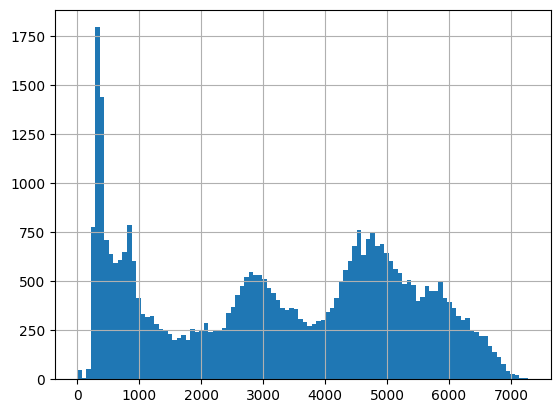

In [11]:
df['traffic'].hist(bins=100)

La distribution montre des observations s'étend de 0 véhicule à plus de 7 000 véhicules et que ces observtions ne suivent pas une distribution normale mais présente essentiellement trois pics : autour 0-1000 ( le pic le plus important mais moins étalé ); autour de 3000 et autour de 5000. On note par ailleurs une forte concentration en 4000 et 7000. Cette distribution ne révèle pas des observations aberrantes.

Évolution temporelle (plot de la série complète)

<Axes: xlabel='datetime'>

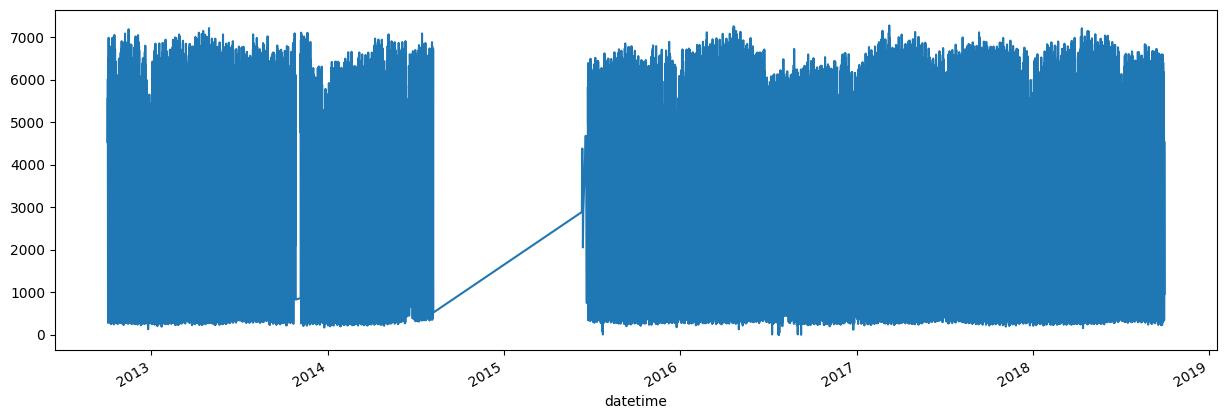

In [12]:
df1 = df.copy()
df1['datetime'] = pd.to_datetime(df1['datetime'])
df1.set_index('datetime', inplace=True)
df1['traffic'].plot(figsize=(15, 5))


---

La visualisation de la série temporelle du volume de trafic sur l'ensemble de la période (octobre 2012 à septembre 2018) révèle plusieurs caractéristiques structurelles essentielles à la compréhension des dynamiques de circulation sur *l'Interstate 94*.

**Cyclicité annuelle** : On observe une variation saisonnière marquée, avec des volumes de trafic généralement plus élevés pendant les mois d'été et plus faibles pendant l'hiver.

**Stabilité interannuelle** : D'une année sur l'autre, la configuration générale reste stable, avec des pics récurrents aux mêmes périodes. Cette stabilité suggère que les comportements de mobilité sont fortement structurés par des facteurs calendaires (saisons, jours fériés) plutôt que par des tendances structurelles de long terme.

**Absence de tendance monotone** : Contrairement à ce que l'on pourrait attendre dans un contexte de croissance urbaine, on n'observe pas de tendance haussière ou baissière marquée sur les six années couvertes par le jeu de données. Le volume de trafic oscille autour d'un niveau moyen stable, ce qui simplifie la modélisation en réduisant le besoin de dériver ou de décomposer la série pour éliminer une tendance non stationnaire.

## Problème potentiel : le saut d'enregistrement en 2015.

Nous allons donc filtrer et travailler avec les données de la partie droite

---

In [13]:
# Vérification de la complétude des dates
def verification_completude_date(df,datetime):
    print("=== Analyse de la complétude temporelle ===\n")
    df[datetime] = pd.to_datetime(df[datetime])

    # Création de l'index temporel complet
    date_min = df[datetime].min()
    date_max = df[datetime].max()
    date_range = pd.date_range(start=date_min, end=date_max, freq='h')

    # Identification des dates manquantes
    dates_presentes = set(df[datetime])
    dates_manquantes = [d for d in date_range if d not in dates_presentes]

    print(f"Période : {date_min} → {date_max}")
    print(f"Nombre total d'heures possibles : {len(date_range)}")
    print(f"Nombre d'heures présentes : {len(df)}")
    print(f"Nombre d'heures manquantes : {len(dates_manquantes)}")
    print(f"Taux de complétude : {(len(df)/len(date_range)*100):.1f}%")

    # Analyse des trous
    if dates_manquantes:
        # Regrouper les trous consécutifs
        gaps = []
        current_gap = []
        for i, date in enumerate(dates_manquantes):
            if i == 0 or (date - dates_manquantes[i-1]).total_seconds() == 3600:
                current_gap.append(date)
            else:
                if current_gap:
                    gaps.append(current_gap)
                current_gap = [date]
        if current_gap:
            gaps.append(current_gap)

        print(f"\nNombre de trous : {len(gaps)}")
        print("10 plus longs trous :")
        for gap in sorted(gaps, key=len, reverse=True)[:10]:
            print(f"  {len(gap)} heures : {gap[0]} → {gap[-1]}")

        # Vérifier si les trous sont aléatoires
        # Compter les trous par heure, jour, mois
        missing_hours = [d.hour for d in dates_manquantes]
        missing_days = [d.dayofweek for d in dates_manquantes]
        missing_months = [d.month for d in dates_manquantes]

verification_completude_date(df,'datetime')

#filtre
df= df[df['datetime']>='2015-06-19 17:00:00'].copy()
df= df[df['temp']>0].copy()

=== Analyse de la complétude temporelle ===

Période : 2012-10-02 09:00:00 → 2018-09-30 23:00:00
Nombre total d'heures possibles : 52551
Nombre d'heures présentes : 40575
Nombre d'heures manquantes : 11976
Taux de complétude : 77.2%

Nombre de trous : 2588
10 plus longs trous :
  7386 heures : 2014-08-08 02:00:00 → 2015-06-11 19:00:00
  242 heures : 2013-10-27 02:00:00 → 2013-11-06 03:00:00
  117 heures : 2015-06-14 21:00:00 → 2015-06-19 17:00:00
  116 heures : 2014-04-29 09:00:00 → 2014-05-04 04:00:00
  92 heures : 2015-10-23 12:00:00 → 2015-10-27 07:00:00
  64 heures : 2014-07-27 17:00:00 → 2014-07-30 08:00:00
  46 heures : 2013-08-31 01:00:00 → 2013-09-01 22:00:00
  33 heures : 2015-06-22 19:00:00 → 2015-06-24 03:00:00
  32 heures : 2014-08-02 03:00:00 → 2014-08-03 10:00:00
  29 heures : 2013-09-03 03:00:00 → 2013-09-04 07:00:00


<Axes: xlabel='datetime'>

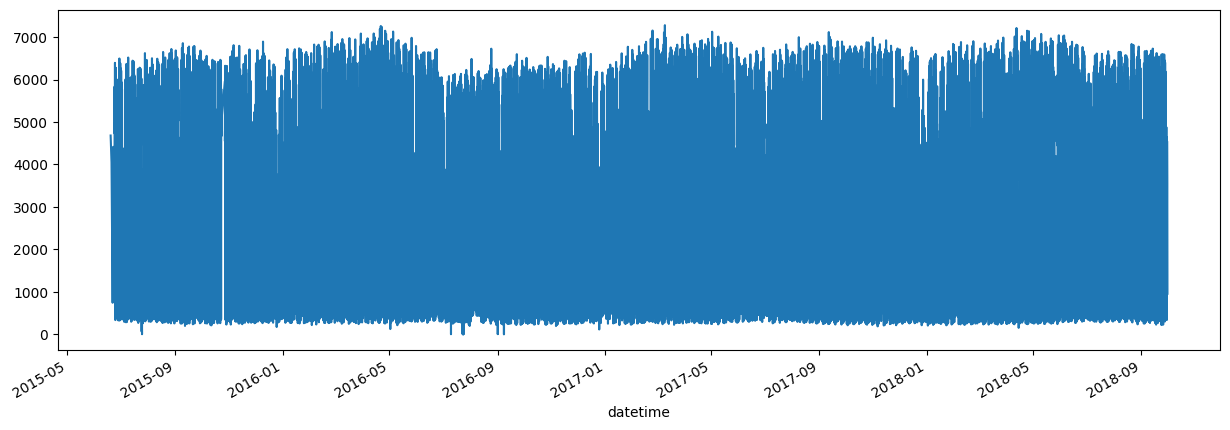

In [14]:
df1 = df.copy()
df1['datetime'] = pd.to_datetime(df1['datetime'])
df1.set_index('datetime', inplace=True)
df1['traffic'].plot(figsize=(15, 5))

L'analyse de la complétude temporelle initiale a révélé un trou majeur de 10 mois entre août 2014 et juin 2015, rendant impossible l'utilisation fiable de lags et de moyennes mobiles sur l'ensemble de la période. Pour cette raison, nous avons restreint notre analyse à la période allant d'octobre 2015 à septembre 2018, qui présente un taux de complétude de 93,4% avec des trous maximum de 9 heures.

Dans ces conditions, les lags et moyennes mobiles deviennent exploitables. Nous procédons à une interpolation linéaire locale pour combler les petits trous (≤ 9 heures), une approche acceptable car les fenêtres de temps concernées sont courtes et ne risquent pas d'introduire de biais significatif. Les observations situées dans des trous plus longs sont supprimées.

Cette stratégie nous permet de bénéficier de l'apport significatif des features temporelles dérivées (lags et moyennes mobiles) tout en préservant l'intégrité des données. Les performances obtenues sur cette période serviront de référence pour la suite du projet

In [15]:
# visualisation
df1 = df.copy()

df1["datetime"] = pd.to_datetime(df1["datetime"])
df1["date"] = df1["datetime"].dt.date
df1["hour"] = df1["datetime"].dt.hour
df1["day"] = df1["datetime"].dt.day
df1["weekday"] = df1["datetime"].dt.weekday
df1["month"] = df1["datetime"].dt.month
df1["year"] = df1["datetime"].dt.year

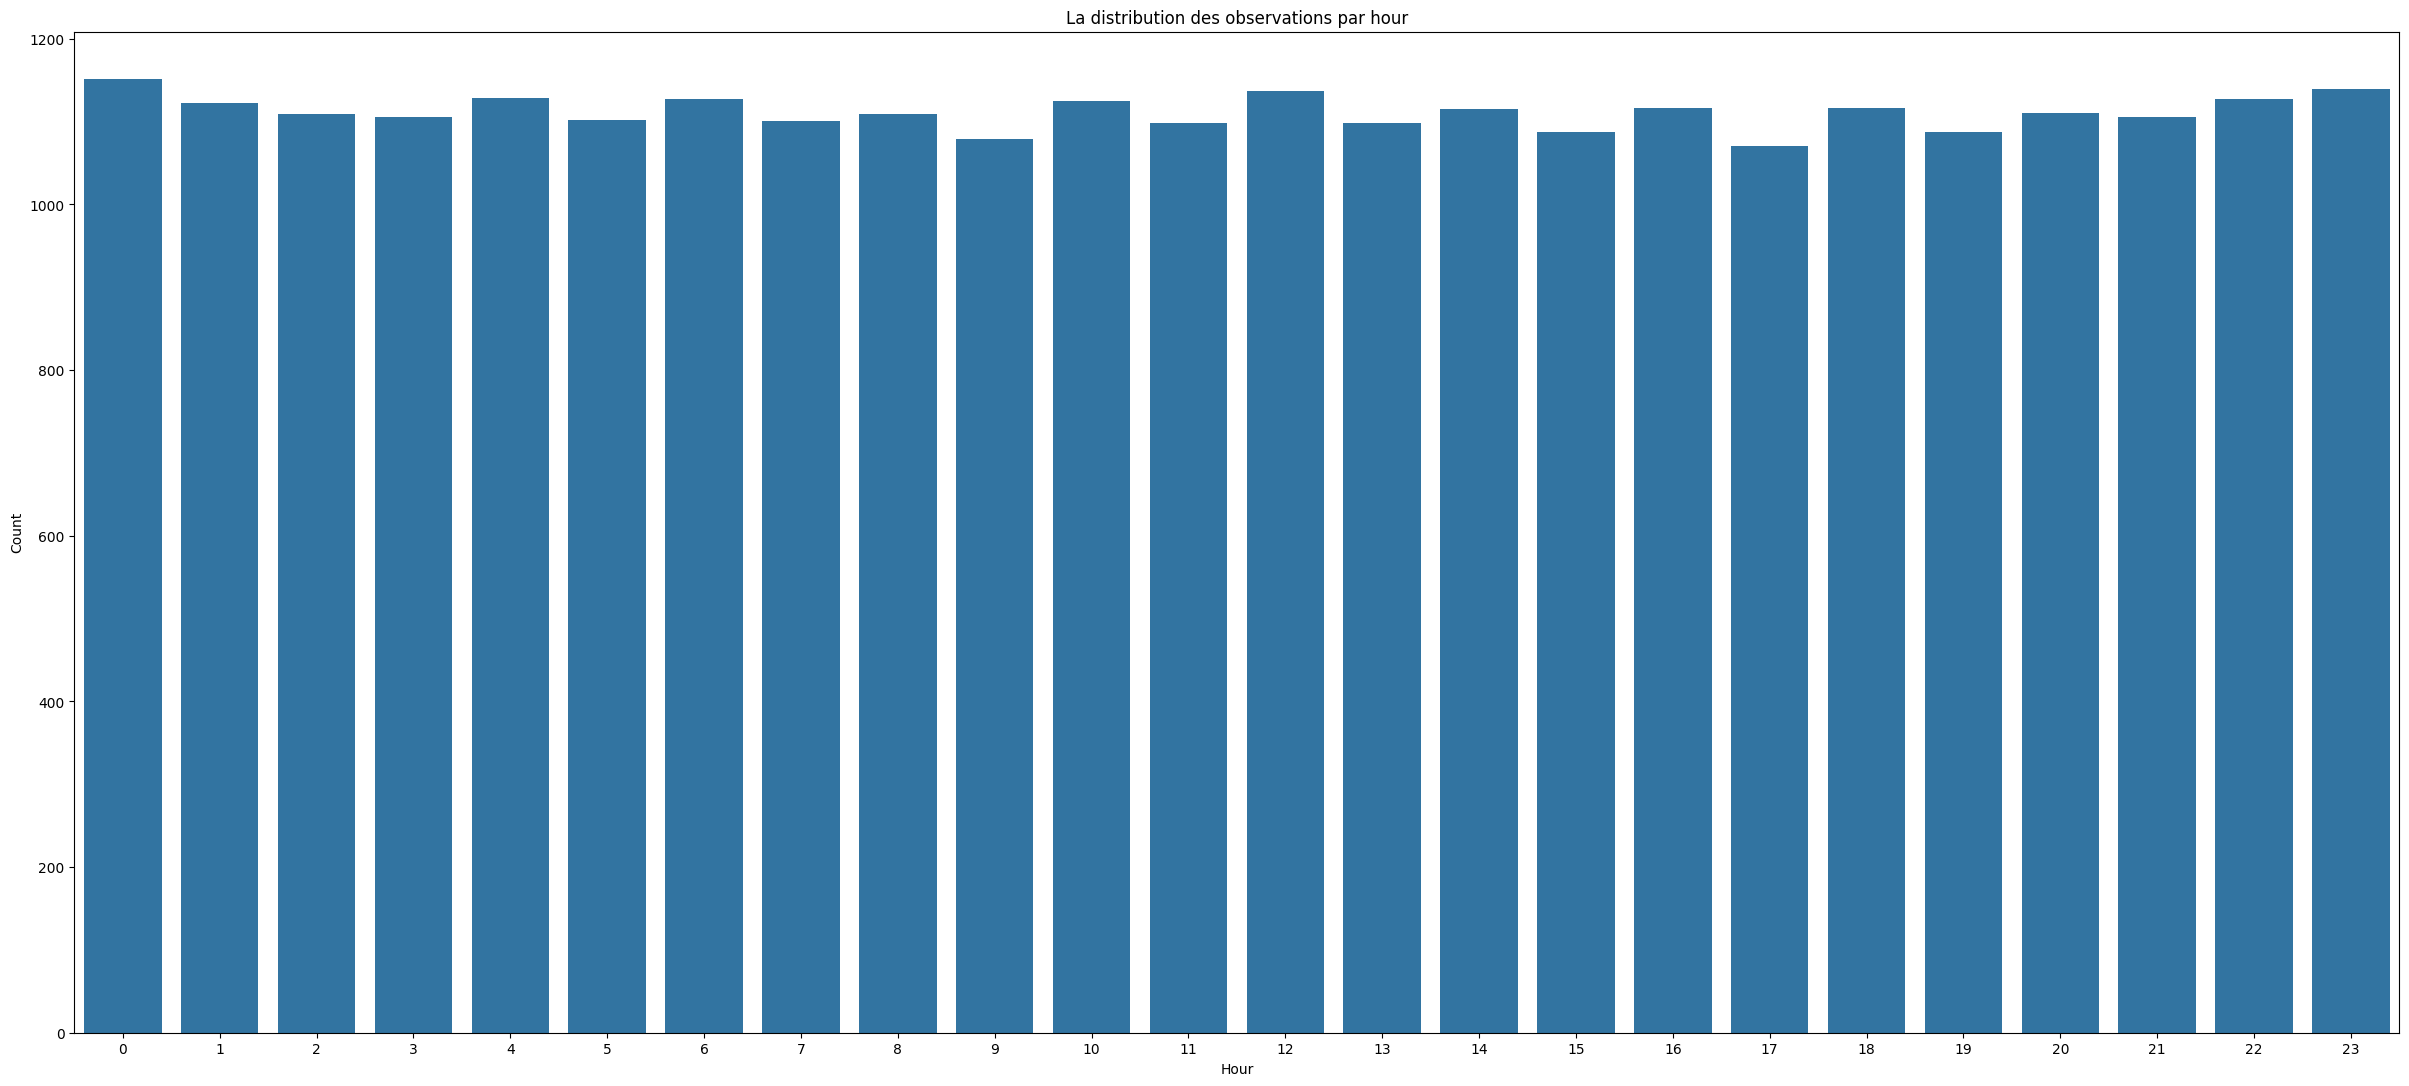

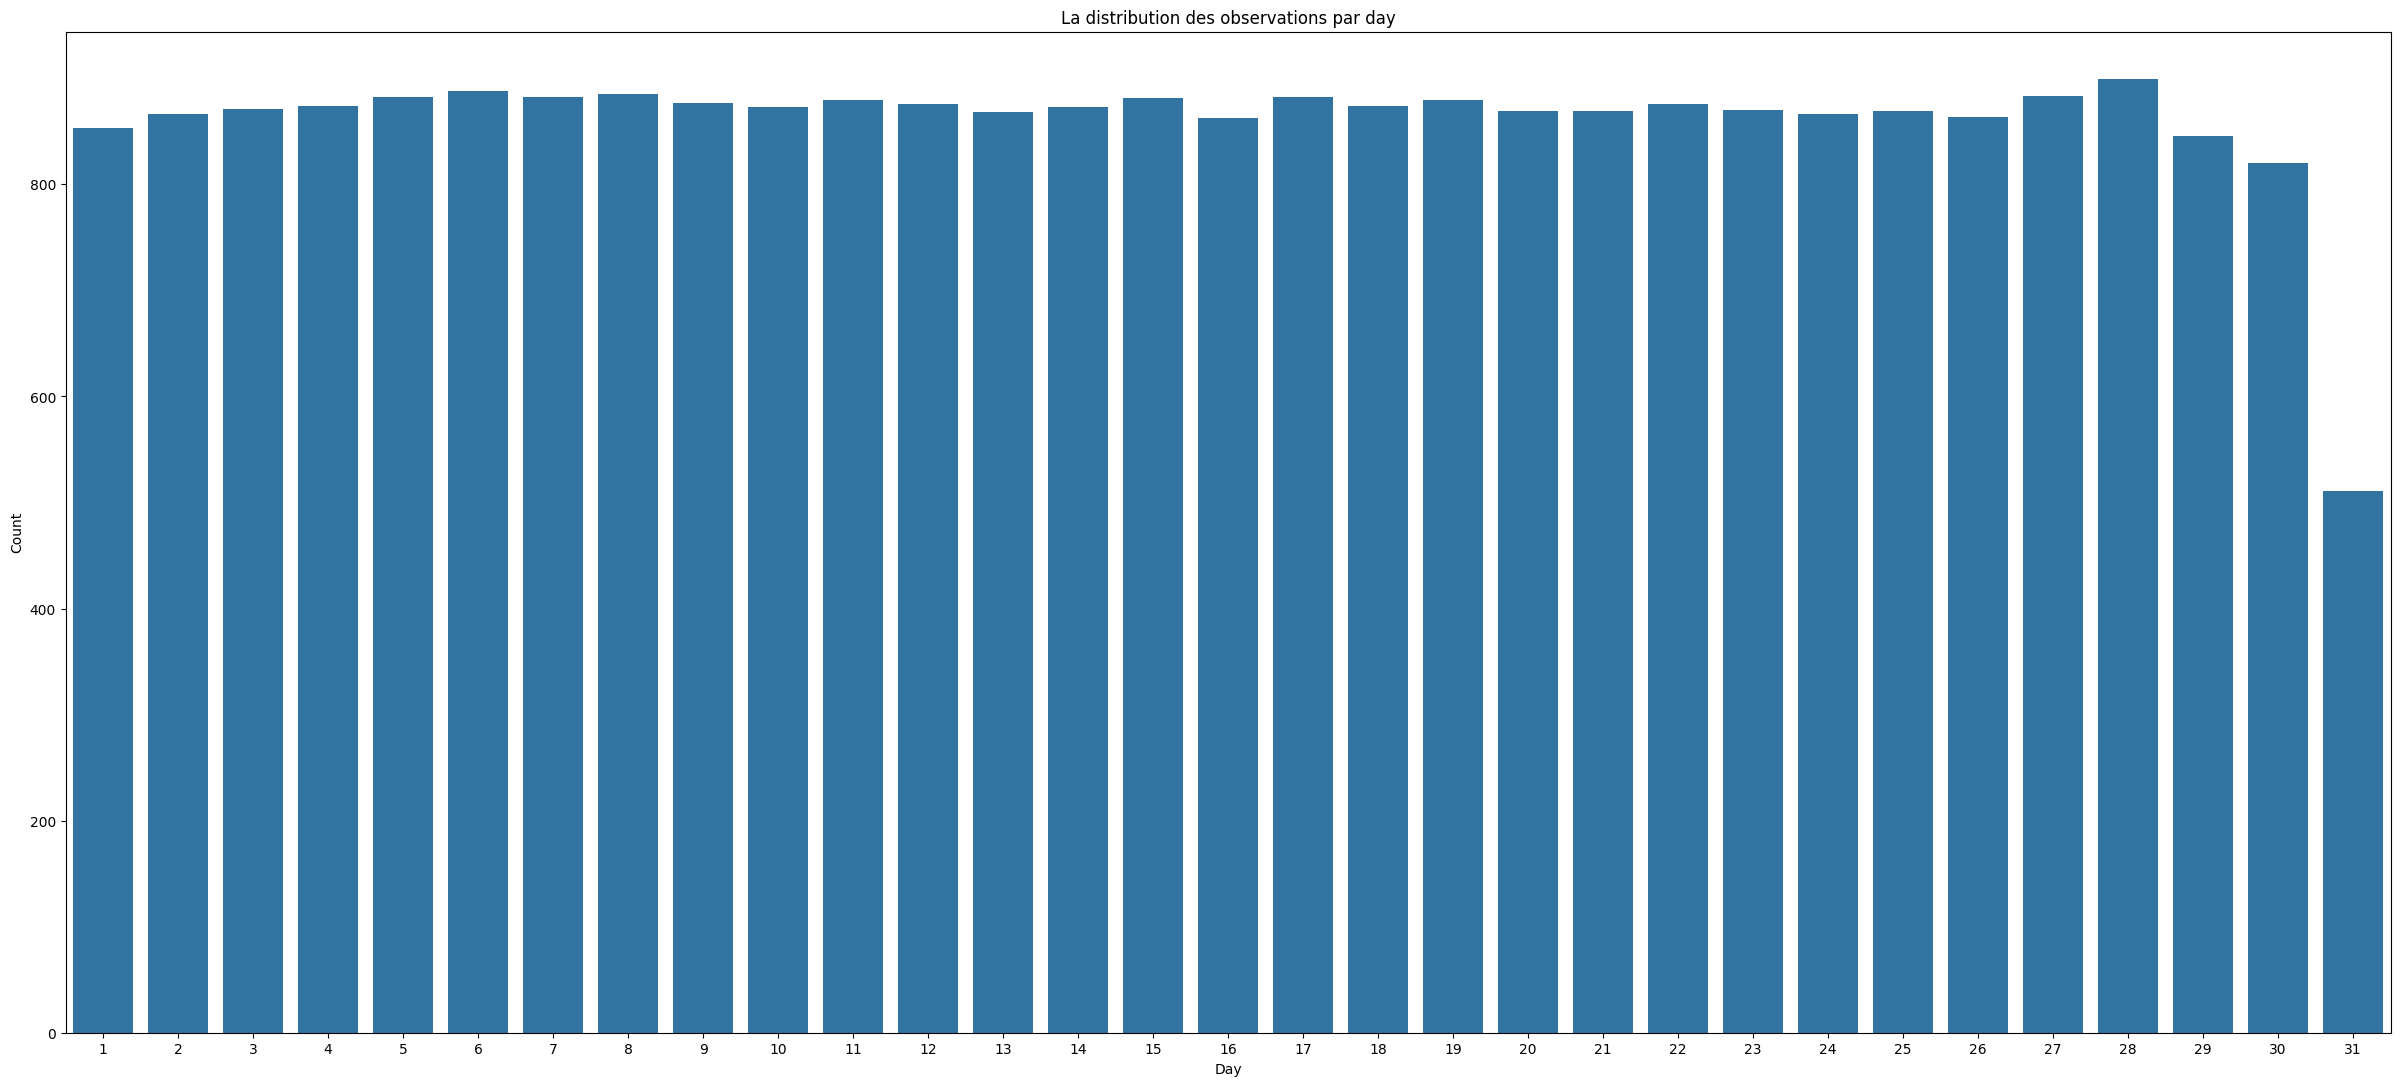

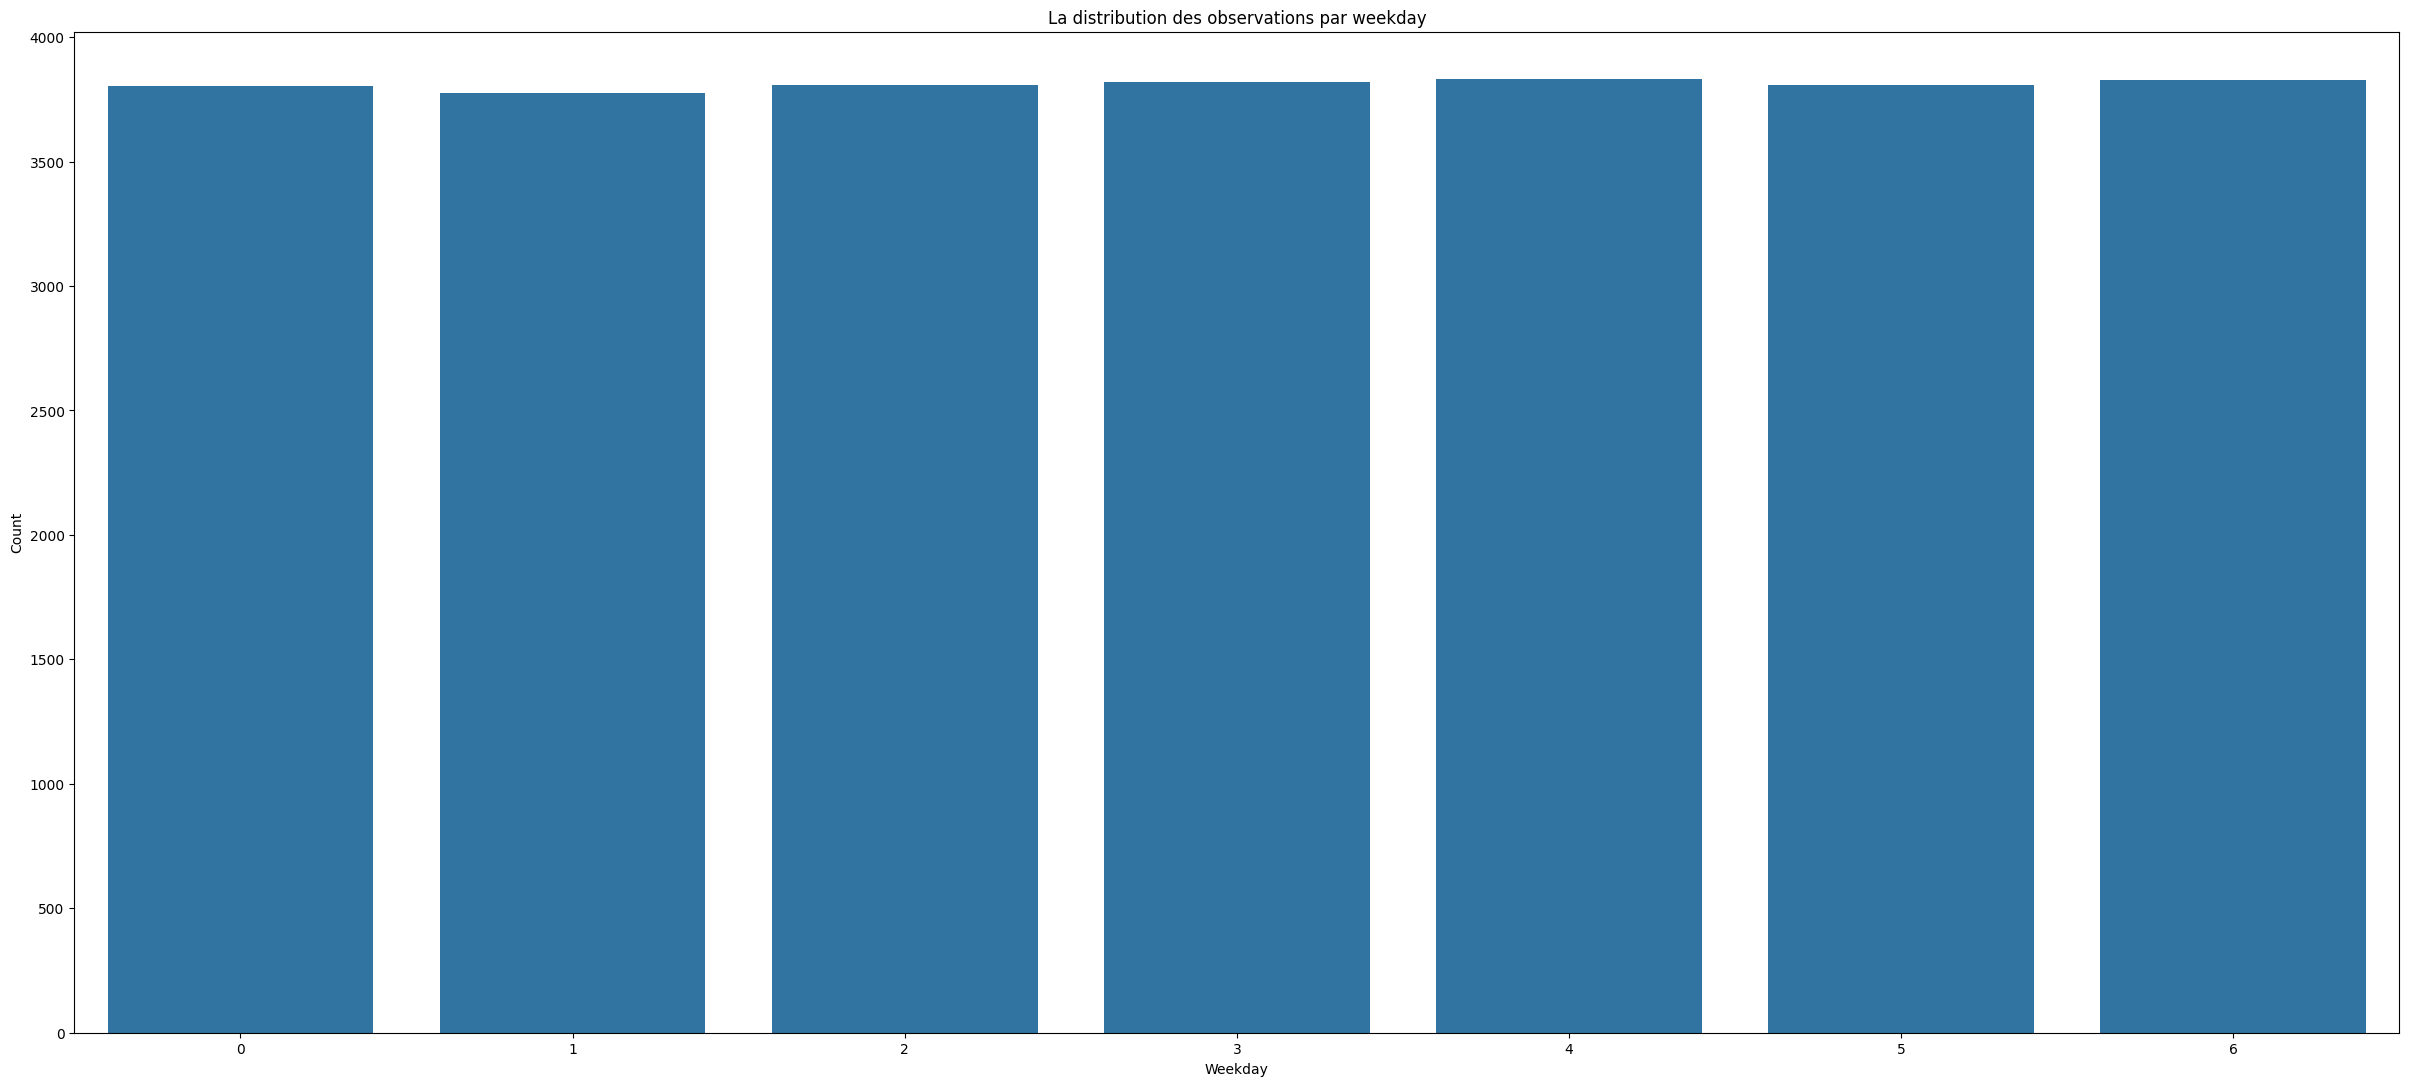

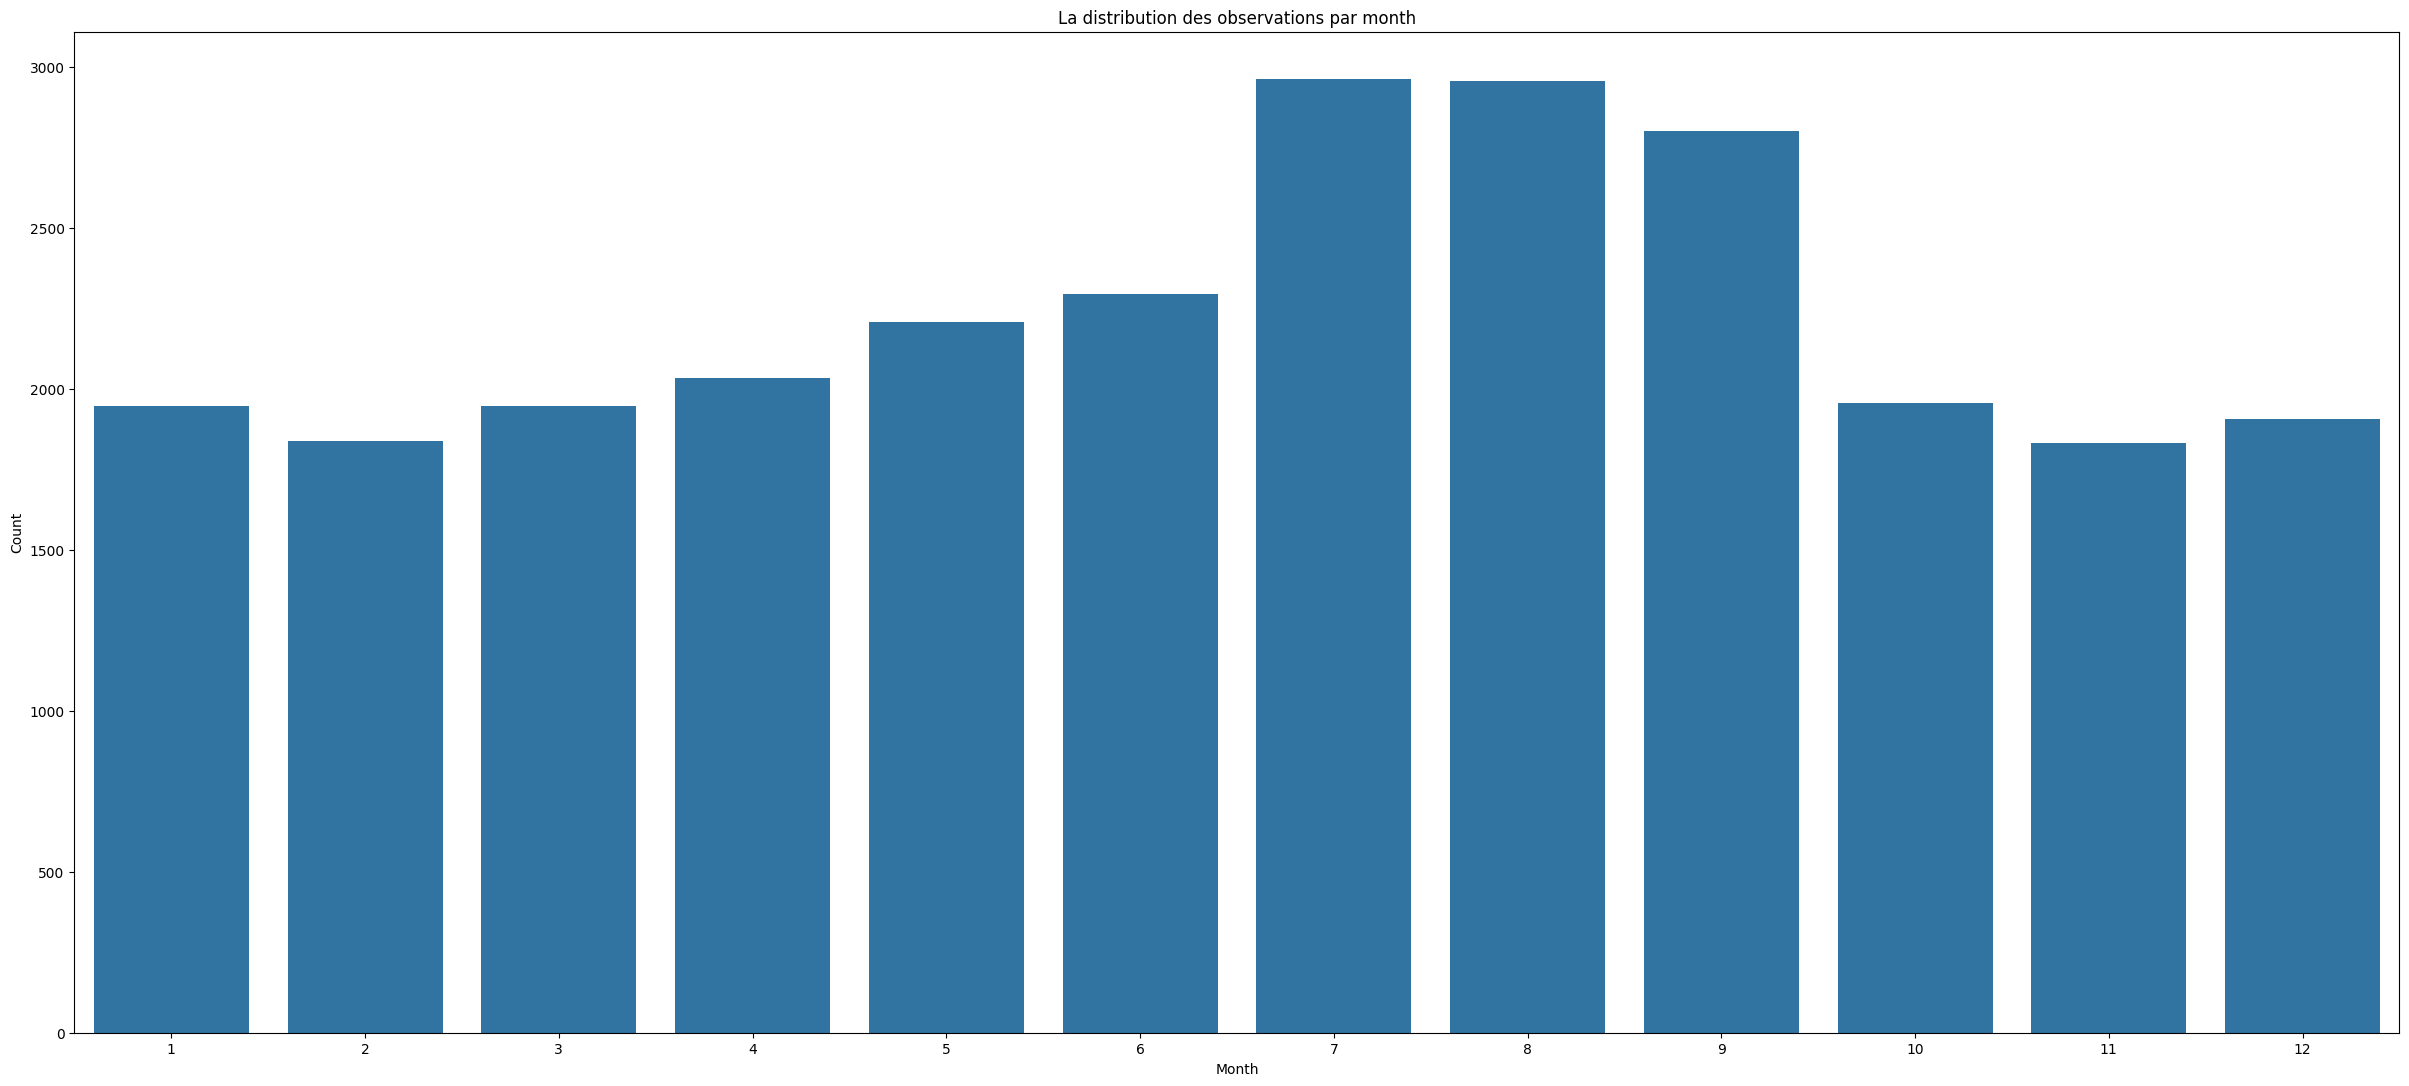

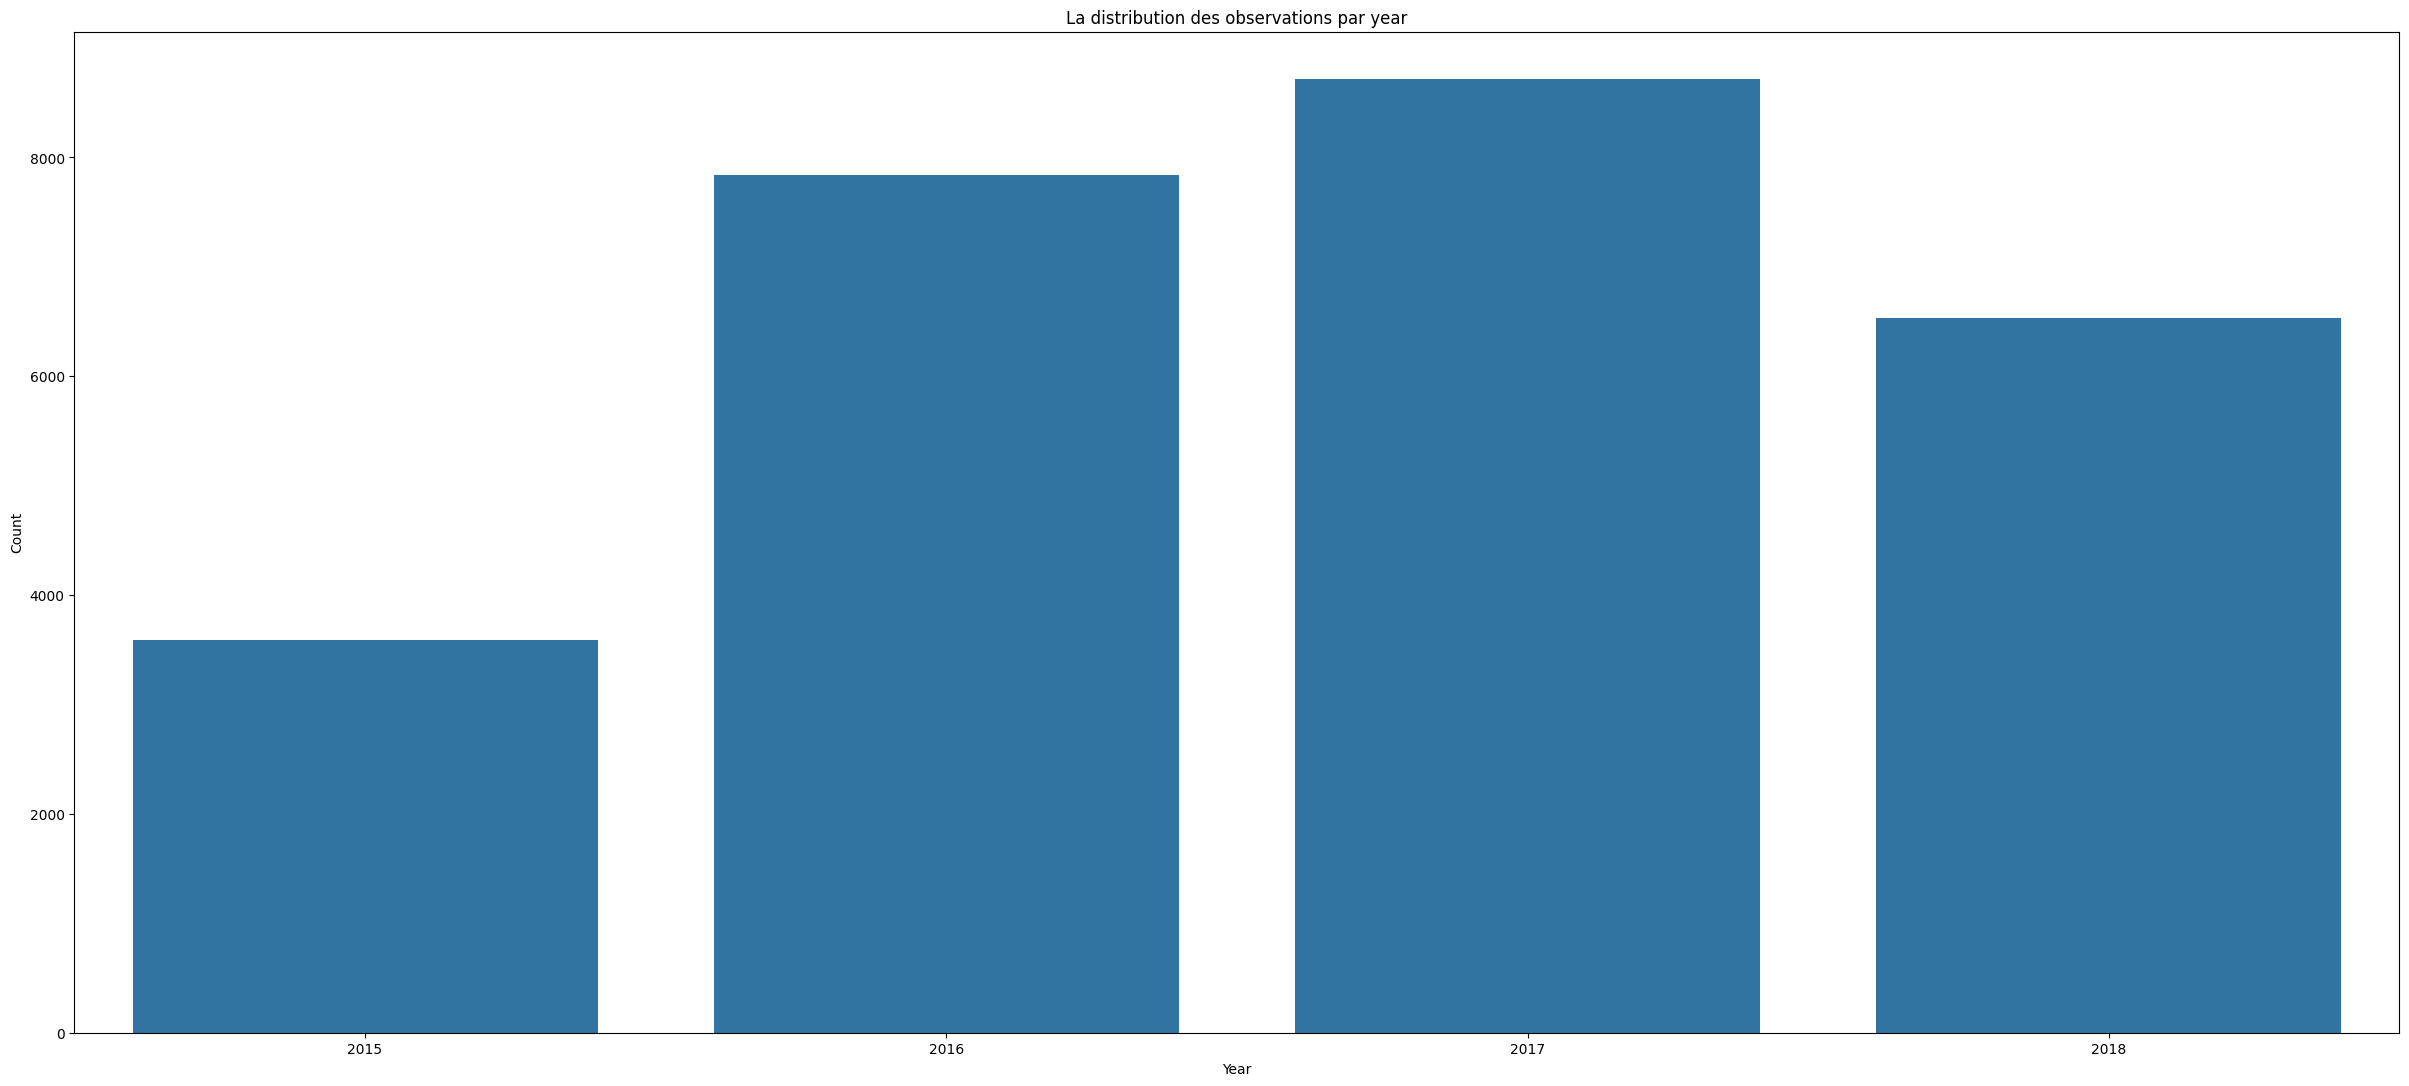

In [16]:
for column in ["hour", "day", "weekday", "month", "year"]:
    fig = plt.figure(figsize=(30, 13))
    plt.subplot(1, 1, 1)
    sns.countplot(x=column, data=df1 )
    plt.title(f"La distribution des observations par {column}")
    plt.xlabel(f"{column.capitalize()}")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.subplots_adjust(hspace=0.3)
    plt.show()

In [17]:
df1.columns

Index(['holiday', 'temp', 'rain', 'snow', 'cloud', 'weather',
       'weather_description', 'datetime', 'traffic', 'date', 'hour', 'day',
       'weekday', 'month', 'year'],
      dtype='str')

Boxplots du trafic selon l’heure, le jour, la météo, les jours fériés

<Axes: title={'center': 'traffic'}, xlabel='year'>

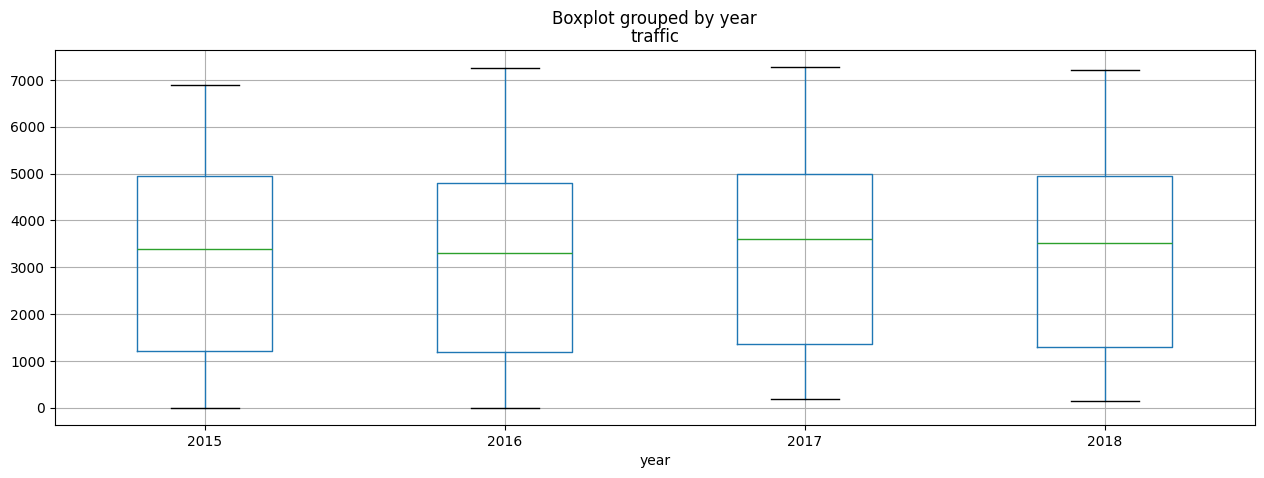

In [18]:
df1.boxplot(column='traffic', by='year', figsize=(15, 5))

<Axes: title={'center': 'traffic'}, xlabel='month'>

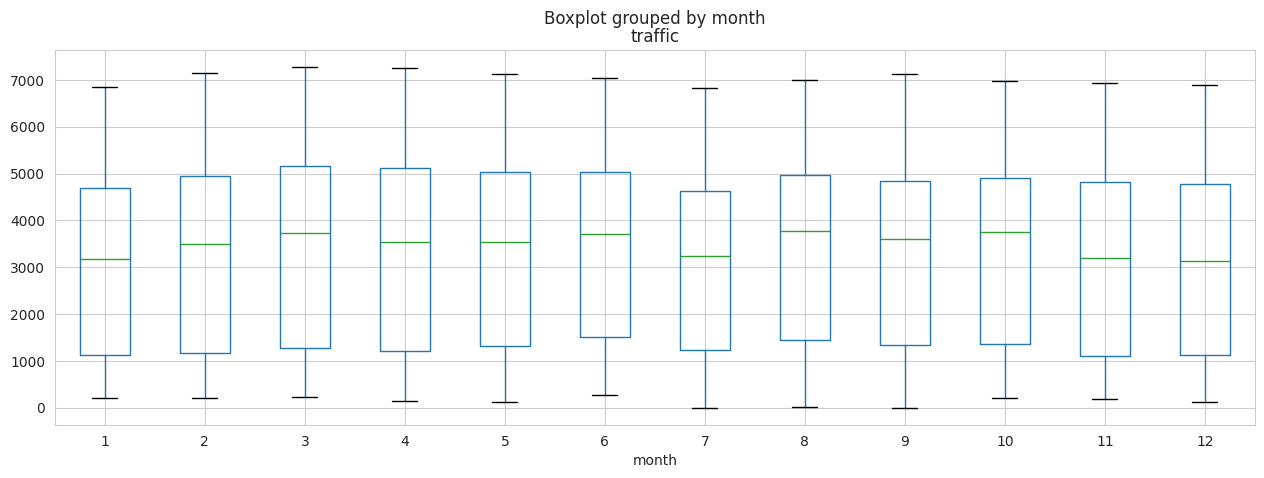

In [ ]:
df1.boxplot(column='traffic',by = "month", figsize=(15, 5))

<Axes: title={'center': 'traffic'}, xlabel='hour'>

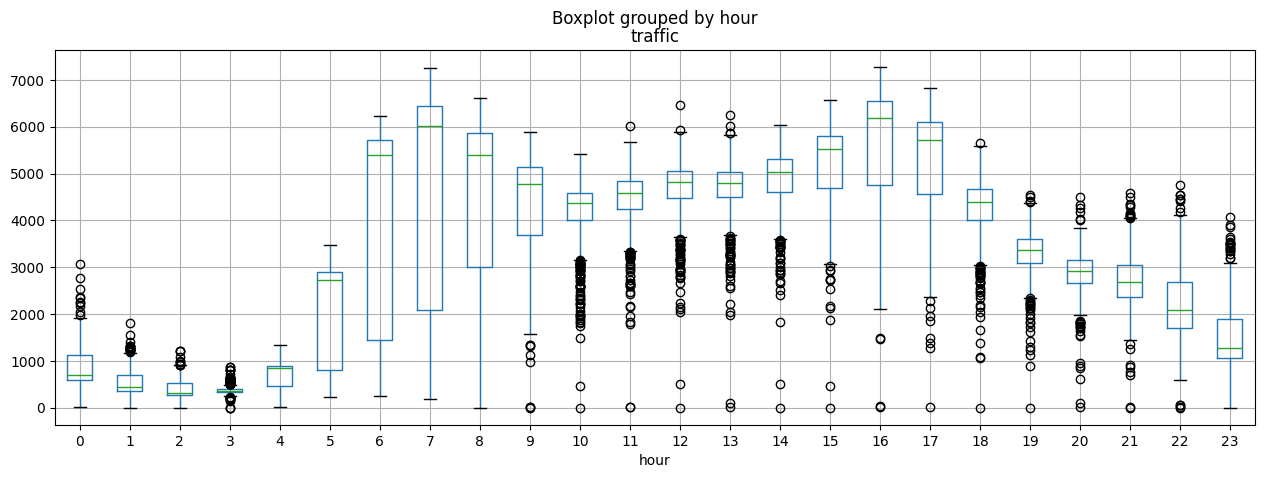

In [19]:
df1.boxplot(column='traffic',by = "hour", figsize=(15, 5))

---
Le boxplot du volume de trafic en fonction de l'heure de la journée révèle des patterns temporels très marqués qui structurent fortement la mobilité sur *l'Interstate 94*.

**Cycle journalier bimodal**: La distribution met en évidence deux pics principaux de
trafic. Le premier, observé autour de `7h-8h`, correspond à l'heure de pointe du matin, moment où les déplacements domicile-travail sont les plus intenses. Le second, plus élevé et plus étalé, se situe entre `15h et 18h`, reflétant l'heure de pointe du soir. Ces deux pics sont caractéristiques des axes routiers desservant des zones urbaines et périurbaines.

**Trafic nocturne minimal** : Entre `minuit et 5h du matin`, les volumes de trafic sont extrêmement faibles, avec des médianes proches de zéro et des boîtes très resserrées. Cette période correspond au creux d'activité où seuls quelques véhicules (livraisons, transports exceptionnels) circulent sur l'autoroute.

**Heures creuses de la journée** : Entre `10h et 15h`, le trafic se stabilise à un niveau intermédiaire, avec des médianes autour de *3 000 véhicules/heure*. Cette période hors des heures de pointe présente une dispersion plus faible, indiquant une circulation plus fluide et moins variable.

**Variabilité accrue aux heures de pointe** : Les boîtes à moustaches des heures de pointe `(7h-8h et 15h-18h)` sont sensiblement plus étendues que celles des autres heures, traduisant une plus grande hétérogénéité des conditions de circulation à ces moments. Certaines heures enregistrent des volumes pouvant atteindre *6 000 à 7 000 véhicules*, tandis que d'autres restent plus modérés, suggérant une sensibilité accrue aux facteurs contextuels (météo, événements, jours de semaine).

**Asymétrie des distributions** : On observe une asymétrie positive (queue étirée vers les valeurs élevées) pour la plupart des heures, particulièrement marquée aux heures de pointe. Cela indique que si le trafic est généralement dense, il arrive qu'il devienne exceptionnellement saturé lors de certaines journées.

---

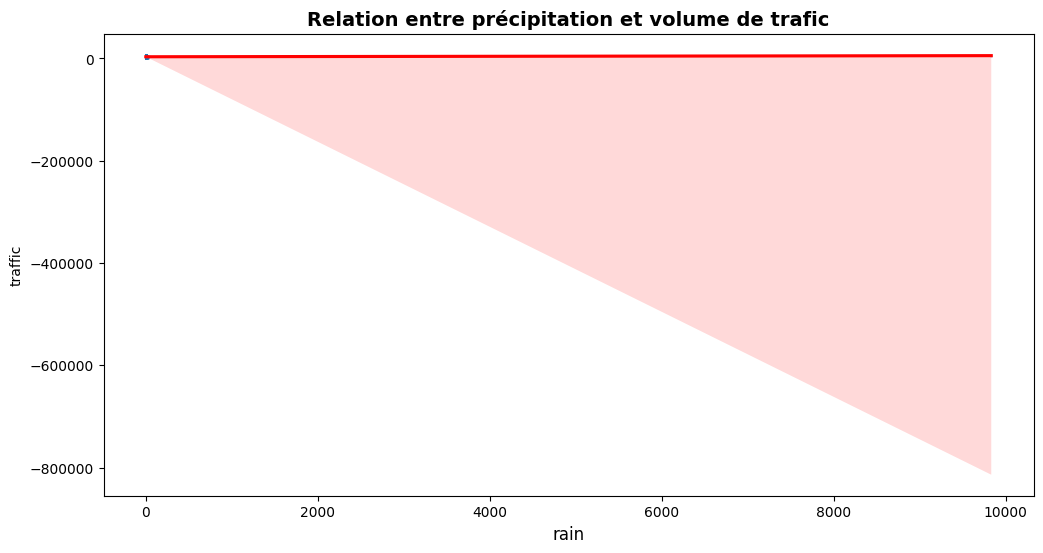

In [17]:
#cols = ['rain', 'snow','cloud','temp']
def graphes(col:str, desc:str):
    plt.figure(figsize=(12, 6))
    sns.regplot(x=col, y='traffic', data=df, scatter_kws={'alpha':0.2, 's':1},line_kws={'color':'red'})
    plt.title(f"Relation entre {desc} et volume de trafic", fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.show()
graphes('rain', 'précipitation')

L'analyse de la relation entre les précipitations et le volume de trafic révèle une tendance négative modérée mais statistiquement observable. La droite de régression indique qu'en l'absence de pluie, le trafic moyen avoisine les 3 200 véhicules, et diminue progressivement jusqu'à environ 1 300 pour les précipitations les plus élevées enregistrées (~57 mm), suggérant que les conditions pluvieuses découragent effectivement les déplacements. Toutefois, cette relation doit être interprétée avec prudence pour deux raisons majeures.

D'une part, la distribution des données est fortement concentrée autour de zéro : la très grande majorité des observations correspond à des jours sans pluie ou avec de très faibles précipitations, tandis que les événements au-delà de 10 mm restent exceptionnels, ce qui fragilise la robustesse de la tendance estimée pour les valeurs extrêmes — comme en témoigne l'élargissement marqué de l'intervalle de confiance.

D'autre part, la dispersion considérable du trafic à précipitation quasi nulle (entre 0 et plus de 7 000 véhicules) révèle que la pluie n'est qu'un facteur parmi d'autres : l'heure de la journée, le jour de la semaine, les vacances scolaires ou encore la saisonnalité exercent vraisemblablement une influence bien plus déterminante sur le volume de trafic.

En somme, si les précipitations contribuent à réduire la circulation, leur pouvoir explicatif seul reste limité, et une modélisation multivariée intégrant d'autres covariables serait indispensable pour quantifier fidèlement cet effet.

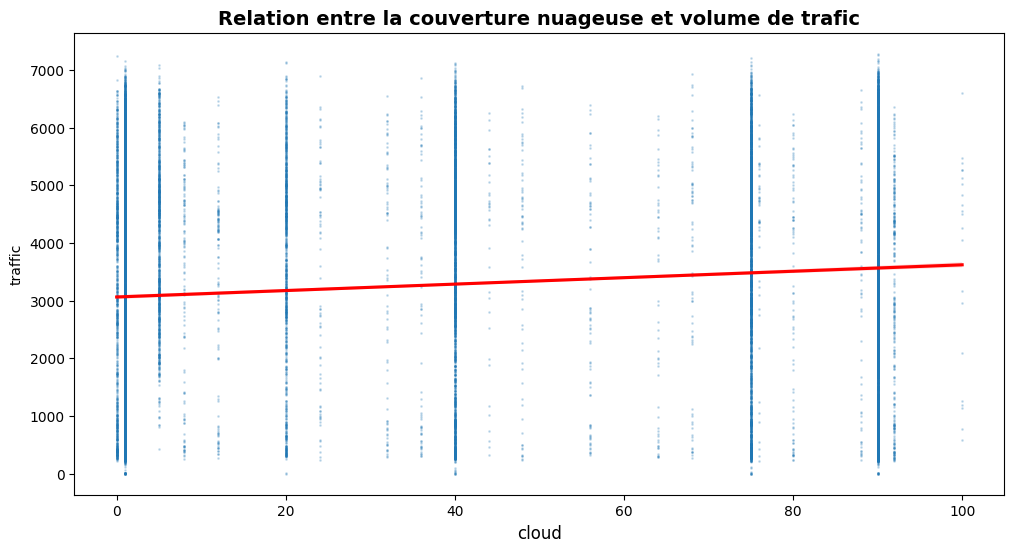

In [18]:
graphes('cloud','la couverture nuageuse')


**Révélation structurelle majeure : une variable discrète déguisée en continue.**
Le premier enseignement de ce graphique n'est pas la relation avec le trafic, mais la **nature même de la variable cloud**. Les points ne se distribuent pas de façon continue, ils forment des **colonnes verticales parfaitement alignées** à des valeurs entières précises (0, 5, 10, 20, 40, 65, 75, 90, 100). Il s'agit donc d'une variable **catégorielle ordinale** encodée en entiers, probablement issue d'une échelle météorologique standardisée en octas ou en déciles. Appliquer une régression linéaire sur une telle variable sans transformation préalable est méthodologiquement discutable.

**Une variance homogène et élevée à tous les niveaux.**
Chaque colonne s'étend de 0 à 7 000+ véhicules, sans réduction notable de la dispersion pour aucune valeur de cloud. Cela confirme que la couverture nuageuse **n'explique quasiment rien** de la variabilité du trafic.


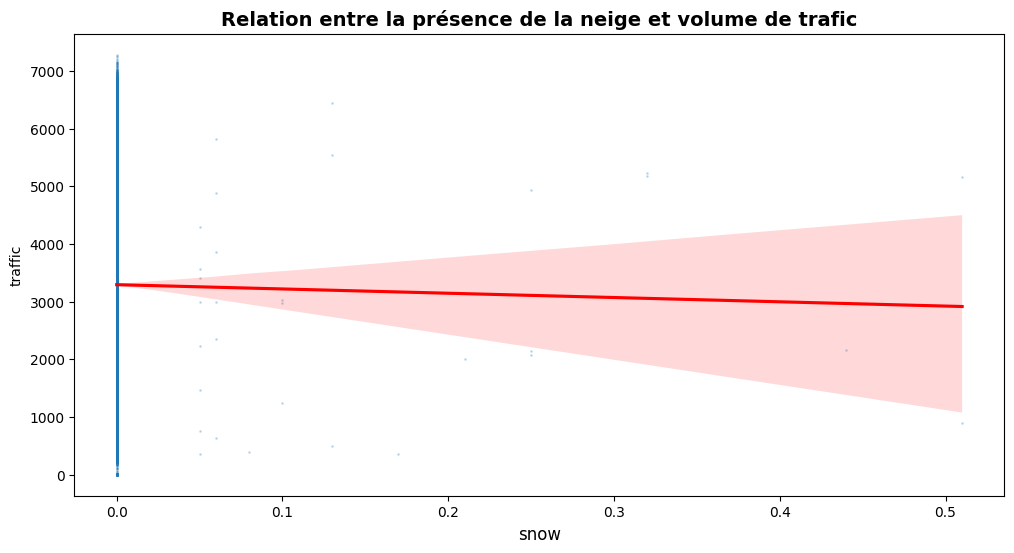

In [19]:
graphes('snow', 'la présence de la neige')


L'examen de ce graphique appelle d'emblée une remarque méthodologique importante : la variable **snow** semble être une **variable binaire ou quasi-binaire** (0 = pas de neige, valeurs positives = présence de neige), et non une mesure continue d'accumulation en centimètres ou millimètres. L'écrasante majorité des observations est empilée sur la valeur 0.0, avec une ligne verticale caractéristique, tandis que les rares points non-nuls sont dispersés de façon irrégulière jusqu'à ~0.51 — ce qui évoque davantage un **indice ou un score de présence** qu'une mesure physique classique.

Sur le plan de la tendance, la droite de régression est **quasi-plate** : le trafic moyen reste autour de 3 200 à snow = 0 et descend légèrement à ~2 950 pour les valeurs maximales de neige. Cette pente négligeable indique une **corrélation quasi nulle** entre la neige et le volume de trafic dans ce dataset.

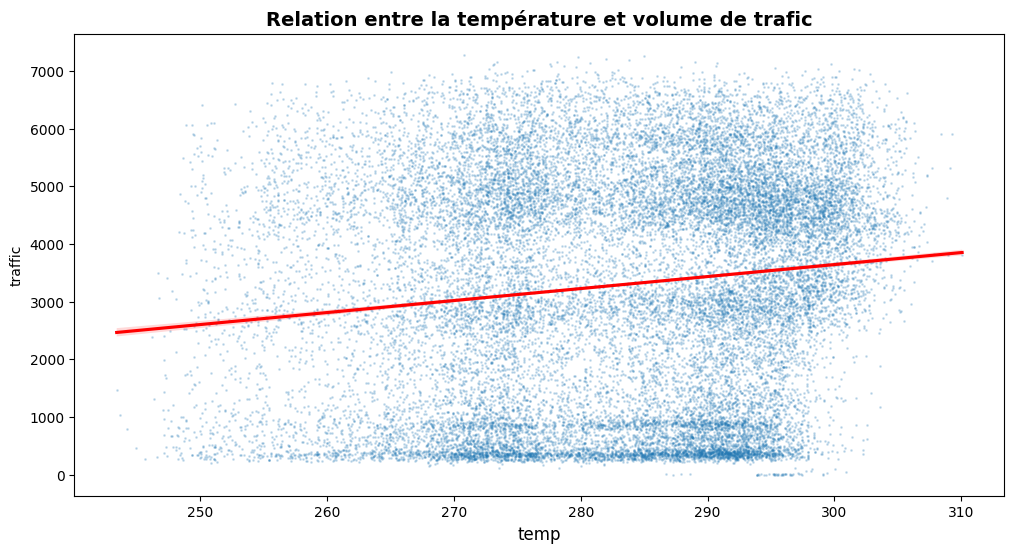

In [20]:
graphes('temp', 'la température')


Ce graphique est sans doute le plus **informatif des trois** jusqu'ici, et ce pour plusieurs raisons.

**Une variable continue et bien distribuée.** Contrairement à la pluie ou à la neige, la température (exprimée en Kelvin, de ~245 K soit -28°C à ~310 K soit +37°C) est **bien répartie sur toute sa plage**, avec une densité de points homogène. Cela confère une bien meilleure robustesse statistique à la régression — l'intervalle de confiance est d'ailleurs remarquablement étroit et stable sur l'ensemble de l'axe, signe que l'estimation est fiable partout.

**Une tendance positive claire.** La droite de régression monte de ~2 500 véhicules à basse température jusqu'à ~3 900 à haute température, soit un écart de près de **1 400 véhicules** entre les conditions hivernales extrêmes et estivales. Cela traduit un comportement intuitif : par grand froid, les gens se déplacent moins ou évitent certains modes de transport au profit de la voiture individuelle dans une moindre mesure — ou simplement sortent moins.

**Un signal anormal en bas à droite.** On observe une bande de points à trafic ≈ 0 pour des températures entre ~285 K et ~305 K. Ce n'est pas du bruit, cela ressemble à des **fermetures de route, jours fériés, ou périodes de confinement** qui coïncident avec des températures printanières/estivales et méritent une investigation spécifique.

Une transformation ou une interaction `temp × heure_de_pointe` pourrait être envisageable dans la suite.

---
---

# 2. Feature engineering

In [20]:

# Convert 'datetime' column to datetime objects

df["datetime"] = pd.to_datetime(df["datetime"])

# df2
df2 = df[["datetime","traffic"]]

# resample in order to add missing hours in date_time
df2 = df2.set_index("datetime").resample("h").asfreq(fill_value=np.nan).reset_index()

# merge in order to rebuild the dataset
df3 = pd.merge(df2, df, how="left")

In [21]:
# imputation of numerical missing values
reg = LinearRegression()

imputer = IterativeImputer(
    estimator=reg,
    missing_values=np.nan,
    max_iter=10,
    verbose=2,
    imputation_order="roman",
    random_state=0
)

imputation = imputer.fit_transform(
    df3[["traffic", "temp", "rain", "snow", "cloud"]]
)

feature_imputed = pd.DataFrame(
    imputation,
    columns=["traffic", "temp", "rain", "snow", "cloud"]
)
feature_imputed.shape

[IterativeImputer] Completing matrix with shape (28782, 5)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.05
[IterativeImputer] Change: 3.0252229421632443e-10, scaled tolerance: 9.831299999999999 
[IterativeImputer] Early stopping criterion reached.


(28782, 5)

In [22]:
# concat numeric_imputed DataFrame with data_subset
data = feature_imputed.join(df3[["datetime", "holiday", "weather", "weather_description"]])
data.shape

(28782, 9)

In [24]:

# f-fill categorical missing values
data = data.ffill()

In [25]:
# check about missing values
data.isnull().sum().to_frame(name="Missing value").T

,traffic,temp,rain,snow,cloud,datetime,holiday,weather,weather_description
Missing value,0,0,0,0,0,0,318,0,0


In [26]:
#
df1 = df.copy()
df = data


## 2.1. Création de variables temporelles

In [27]:
# Heure, jour de la semaine, mois, année

df["datetime"] = pd.to_datetime(df["datetime"])
#df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["weekday"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year
df.reset_index(drop=True, inplace=True)

Vu la distribution de la variable cloud, nous allons découper la variable en 5 catégories

In [28]:
# vérifions la distribution réelle
#print(df['cloud'].value_counts().sort_index())

# création des catégories
df['cloud_cat'] = pd.cut(df['cloud'],
                         bins=[-1, 20, 50, 80, 101],
                         labels=['clear', 'few_clouds', 'cloudy', 'very_cloudy'])



C:\Users\USER\AppData\Local\Temp\ipykernel_19744\158784344.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels, fontsize=11)


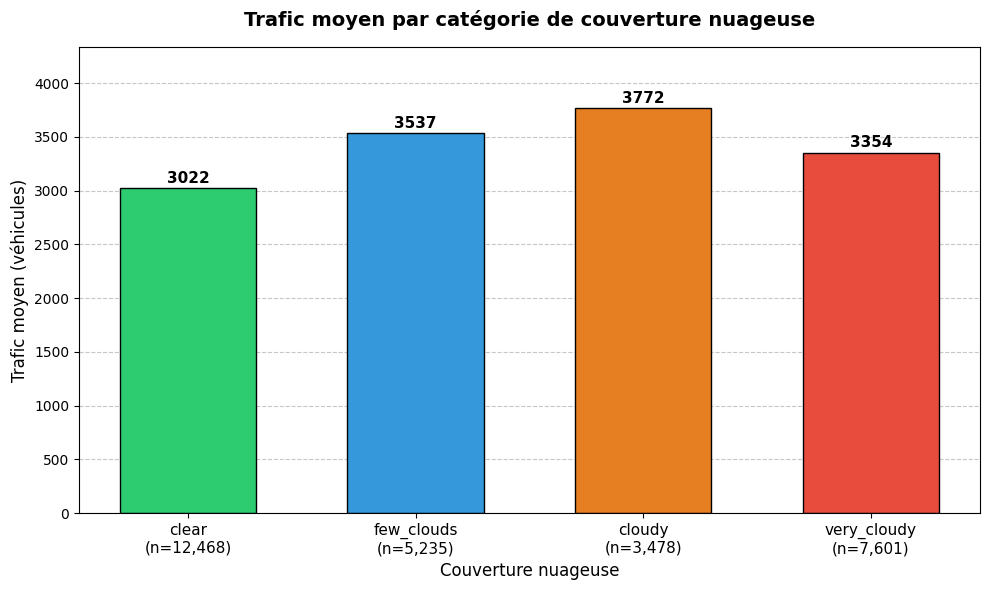

In [29]:
# Calcul de la moyenne de trafic par catégorie de nuage
traffic_by_cloud = df.groupby('cloud_cat')['traffic'].mean().reset_index()

# Ordre logique des catégories
order = ['clear', 'few_clouds', 'cloudy', 'very_cloudy']
traffic_by_cloud['cloud_cat'] = pd.Categorical(traffic_by_cloud['cloud_cat'],
                                                categories=order,
                                                ordered=True)
traffic_by_cloud = traffic_by_cloud.sort_values('cloud_cat')

# Diagramme
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(traffic_by_cloud['cloud_cat'],
              traffic_by_cloud['traffic'],
              color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'],
              edgecolor='black',
              width=0.6)

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{height:.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Ajouter les effectifs sous les labels
counts = df['cloud_cat'].value_counts()
xtick_labels = [f'{cat}\n(n={counts[cat]:,})' for cat in order]
ax.set_xticklabels(xtick_labels, fontsize=11)

# Mise en forme
ax.set_title('Trafic moyen par catégorie de couverture nuageuse',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Couverture nuageuse', fontsize=12)
ax.set_ylabel('Trafic moyen (véhicules)', fontsize=12)
ax.set_ylim(0, traffic_by_cloud['traffic'].max() * 1.15)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig('traffic_by_cloud_cat.png', dpi=150, bbox_inches='tight')
plt.show()

Transformons la variable holiday en binaire (1/0)

In [30]:

df['is_holiday'] = (~df['holiday'].isna()).astype(int)

# Verifions
(df['is_holiday']).value_counts(normalize=True)*100

is_holiday
1    98.895143
0     1.104857
Name: proportion, dtype: float64

Lors de l'EDA nous avons remarquer des heures de pointes (7h-9h et de 15h-18h)

In [31]:
def rush_hours(data) -> int :
    """


    """
    if (data >= 7 and data < 9) or (data > 15 and data < 18):
        return 1
    return 0


# Appliquer
df['is_rush_hour'] = df['hour'].map(rush_hours)
# Verifions
df['is_rush_hour'].value_counts(normalize=True)*100


is_rush_hour
0    83.336808
1    16.663192
Name: proportion, dtype: float64

In [32]:
df['is_weekend'] = (df['weekday'] >=5).astype(int)
df['is_weekend'].value_counts(normalize=True)*100



is_weekend
0    71.315405
1    28.684595
Name: proportion, dtype: float64

Conversion température en Celsius : `temp_c = temp - 273.15`.

In [33]:
def temp_kelvin_to_celcuis(data) -> float:
    """
    Convert temperature from Kelvin to Celsius.
    """
    return data - 273.15

df['temp_c'] = df['temp'].map(temp_kelvin_to_celcuis)
df.drop(columns='temp',inplace=True)


### Regrouper les modalités de weather


In [34]:
# Étape 1 : regrouper les modalités rares
weather_map = {
    'Clear'        : 'Clear',        # Bon temps
    'Clouds'       : 'Clouds',        # Nuageux mais acceptable
    'Drizzle'      : 'moderate',    # Perturbation légère
    'Rain'         : 'Rain',         # Mauvais temps
    'Haze'         : 'moderate',    # Visibilité réduite modérée
    'Mist'         : 'moderate',    # Brume légère
    'Snow'         : 'bad',         # Conditions difficiles
    'Thunderstorm' : 'bad',         # Dangereux
    'Fog'          : 'bad',         # Visibilité très réduite
    'Smoke'        : 'bad',         # Rare mais perturbant
    'Squall'       : 'bad'          # Extrême
}

df['weather_cat'] = df['weather'].map(weather_map)

# Vérifier l'équilibre
print(df['weather_cat'].value_counts(normalize=True) * 100)

weather_cat
Clear       35.654228
Clouds      31.915781
Rain        12.111737
moderate    12.094365
bad          8.223890
Name: proportion, dtype: float64


In [35]:
def rain_sonw_to_categorical(data) -> int:
    """
    """
    if data > 0.0:
        return 1
    else:
        return 0

df["rain_cat"] = df["rain"].map(rain_sonw_to_categorical)
df["snow_cat"] = df["snow"].map(rain_sonw_to_categorical)

## Transformation cyclique

Les variables temporelles telles que *`l'heure de la journée`*, `le jour de la semaine` et `le mois de l'année` présentent une propriété fondamentale que l'encodage numérique brut ne saurait capturer : leur nature **cyclique**. En effet, si l'on conserve ces variables sous leur forme entière originale, l'heure variant de 0 à 23, le jour de 0 à 6, le mois de 1 à 12, le modèle interpréterait ces valeurs comme une échelle linéaire continue, impliquant faussement que 23h est très éloigné de 0h, ou que le dimanche (6) est à l'opposé du lundi (0), alors qu'ils sont en réalité adjacents sur le cycle temporel. Cette distorsion introduit un biais structurel dans l'apprentissage, car le modèle ne peut pas percevoir la proximité réelle entre les extrémités du cycle. Pour remédier à cela, on applique une transformation trigonométrique en projetant chaque variable sur le cercle unitaire via deux nouvelles colonnes, un sinus et un cosinus, calculées selon la formule `sin(2π × valeur / période)` et `cos(2π × valeur / période)`. Cette double projection garantit que deux valeurs temporellement proches, quelle que soit leur position sur le cycle, produisent des coordonnées géométriquement proches dans l'espace des features, préservant ainsi la continuité circulaire du temps.

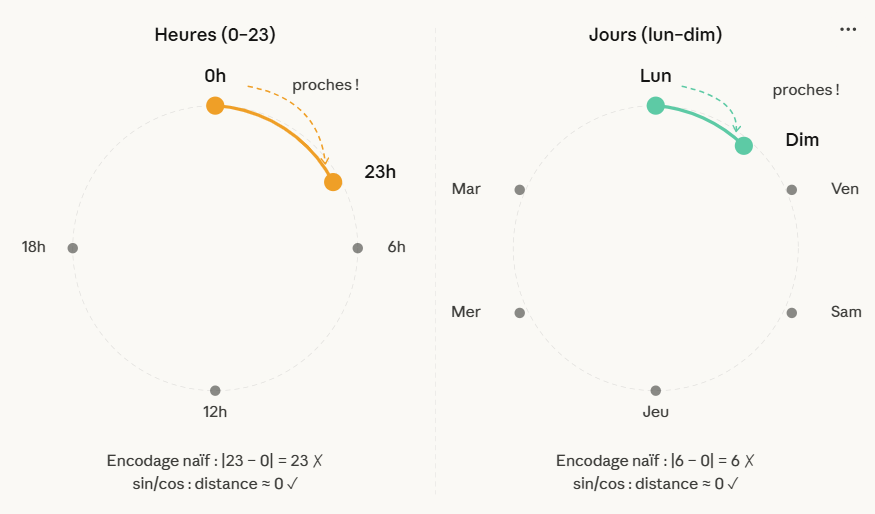

In [36]:

# Heures
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Jours de semaine (0=lundi ... 6=dimanche)
df['day_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

# Mois
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Supprimer les colonnes brutes (devenues inutiles)
#df.drop(columns=['weekday_cos', 'weekday_sin'], inplace=True)


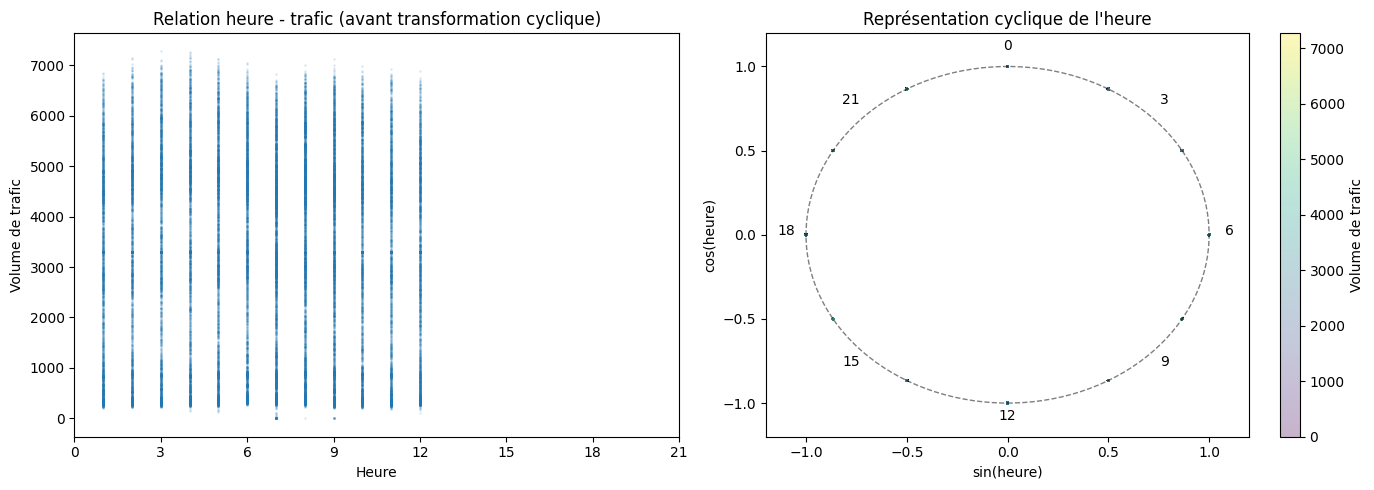

In [37]:

# Visualisation de la transformation cyclique pour l'heure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant transformation
axes[0].scatter(df['month'], df['traffic'], alpha=0.1, s=1)
axes[0].set_title('Relation heure - trafic (avant transformation cyclique)', fontsize=12)
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Volume de trafic')
axes[0].set_xticks(range(0, 24, 3))

# Après transformation (visualisation 2D)
scatter = axes[1].scatter(df['month_sin'], df['month_cos'],
                          c=df['traffic'], cmap='viridis',
                          alpha=0.3, s=1)
axes[1].set_title('Représentation cyclique de l\'heure', fontsize=12)
axes[1].set_xlabel('sin(heure)')
axes[1].set_ylabel('cos(heure)')
axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[1].add_artist(plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.5))

# Ajout des repères horaires sur le cercle
for h in range(0, 24, 3):
    angle = 2 * np.pi * h / 24
    x, y = np.sin(angle), np.cos(angle)
    axes[1].annotate(str(h), xy=(x, y), xytext=(x*1.1, y*1.1), ha='center')

plt.colorbar(scatter, ax=axes[1], label='Volume de trafic')
plt.tight_layout()
plt.show()

### Catégorisation des moments de la journée

In [38]:
def moment_journee(hour) -> str:
    if hour in [4,5,6]:
        return "aube"
    elif hour in [7,8,9,10,11]:
        return "matin"        # heure de pointe montante
    elif [12,13,14,15]:
        return "apres_midi"      # activité soutenue
    elif [16,17,18]:
        return "soir"         # pic déjeuner
    elif [19,20,21,22,23]:
        return "nuit"   # creux relatif
    else:
        return "tard_nuit"         # trafic minimal

df["moment"] = df["hour"].map(moment_journee)

### Catégorisation des saisons

In [39]:
def saisons(mois) ->str:

    if mois in [12, 1, 2]:
        return "hiver"
    elif mois in [3, 4, 5]:
        return "printemps"
    elif mois in [6, 7, 8]:
        return "ete"
    else:
        return "automne"
df["saison"] = df['month'].map(saisons)

## Features de delai (lags) et les moyennes mobiles

L'introduction de features temporelles dérivées des variables météorologiques (`temp`, `rain`, `cloud`) constitue un enrichissement pertinent du jeu de données. Contrairement au trafic qui est mesuré en continu et dont l'historique récent est directement accessible, les conditions météorologiques évoluent selon des dynamiques propres qui influencent les comportements de mobilité de manière différée et progressive.

Les lags appliqués aux variables météo permettent de capturer l'effet mémoire des phénomènes atmosphériques sur le trafic. Par exemple, une chute de température ou une pluie abondante survenue dans les heures précédentes peut continuer à affecter les conditions de circulation bien après l'événement lui-même, en raison d'une modification durable des comportements de déplacement ou de l'état des infrastructures routières. De même, l'accumulation de précipitations sur plusieurs heures consécutives peut avoir un impact plus significatif qu'une averse isolée de courte durée.

Le choix des lags 1, 2, 3 et 24 heures repose sur une double logique. Les trois premiers lags capturent la dynamique à court terme : le trafic de l'heure précédente (lag 1) constitue le prédicteur le plus immédiat, tandis que les lags 2 et 3 permettent de détecter des tendances sur une fenêtre temporelle courte (montée ou descente progressive du trafic). Le lag 24 heures répond quant à lui à la saisonnalité journalière : le trafic observé à une heure donnée présente une forte corrélation avec celui observé à la même heure la veille, reflétant la régularité des comportements de mobilité à l'échelle hebdomadaire.

Les moyennes mobiles sur ces variables météorologiques jouent un rôle complémentaire en lissant les fluctuations instantanées pour révéler les tendances sous-jacentes. Une moyenne sur 3 heures de la température, par exemple, atténue les variations horaires parfois brutales pour fournir une indication plus stable des conditions thermiques ambiantes. Pour les précipitations, une moyenne mobile permet de distinguer une pluie persistante d'une simple ondée passagère, deux situations dont l'impact sur le trafic diffère sensiblement. La couverture nuageuse, dont les variations peuvent être rapides, bénéficie également de ce lissage pour capturer le régime nuageux dominant plutôt que des fluctuations ponctuelles.


In [40]:
def creation_lags(df: pd.core.frame.DataFrame, colonne: str, lags: list) -> pd.core.frame.DataFrame:
    """

    """
    for lag in lags:
        df[colonne + "_lag_" + str(lag)] = df[colonne].shift(periods=lag).astype(np.float16)

    return df

df = df.sort_values('datetime').reset_index(drop=True)
df = creation_lags(df=df,colonne="traffic",lags=[1,2,3,24])
df = creation_lags(df=df,colonne="rain",lags=[1,2,3,24])
df = creation_lags(df=df,colonne="snow",lags=[1,2,3,24])
df = creation_lags(df=df,colonne="temp_c",lags=[1,2,3,24])
df = creation_lags(df=df,colonne="cloud",lags=[1,2,3,24])

In [41]:
def creation_moyenne_mobile(df: pd.core.frame.DataFrame, colonne: str, fenetres: list) -> pd.core.frame.DataFrame:
    """

    """
    for fenetre in fenetres:
        df[colonne + "_mean_" + str(fenetre)] = df[colonne].rolling(window=fenetre).mean()

    return df

df = df.sort_values('datetime').reset_index(drop=True)
df = creation_moyenne_mobile(df=df,colonne="rain",fenetres=[3,6,24])
df = creation_moyenne_mobile(df=df,colonne="temp_c",fenetres=[3,6,24])
df = creation_moyenne_mobile(df=df,colonne="cloud",fenetres=[3,6,24])
df = creation_moyenne_mobile(df=df,colonne="snow",fenetres=[3,6,24])

# Suppression des lignes avec NaN (premières heures)
df = df.dropna().reset_index(drop=True)

In [42]:
data_after_feat = df.copy()

---
---

## Préparation pour la modélisation

### Outliers


In [43]:


def find_outlier(data: pd.core.frame.DataFrame) -> pd.core.frame.DataFrame:
    """

    """
    # Use a list to collect dictionaries for each column
    results = []

    for column in list(data.columns):
        if data[column].dtypes in ["int8", "int16", "int32", "int64", "float16", "float32", "float64"]:
            # statistics
            mean = (sum(data[column])/data[column].shape[0])
            std = (np.sqrt(sum((data[column]-mean)**2) / data[column].shape[0]))

            # fix threshold
            up_threshold = (mean + (1.5*std))
            down_threshold = (mean - (1.5*std))

            # filter the observations
            outliers_mask = (data[column] > up_threshold) | (data[column] < down_threshold)
            outliers_series = data[column][outliers_mask]

            count = outliers_series.count()

            #filtrer
            if column == "temp_c":
                data = data[~outliers_mask]
            # Append dictionary to the results list
            results.append({
                "Column": column,
                "Count outlier": count
            })

    # Create DataFrame from the collected results
    return (data,pd.DataFrame(results))

#data,outliers = find_outlier(data=df)


### Distribution de la variable température

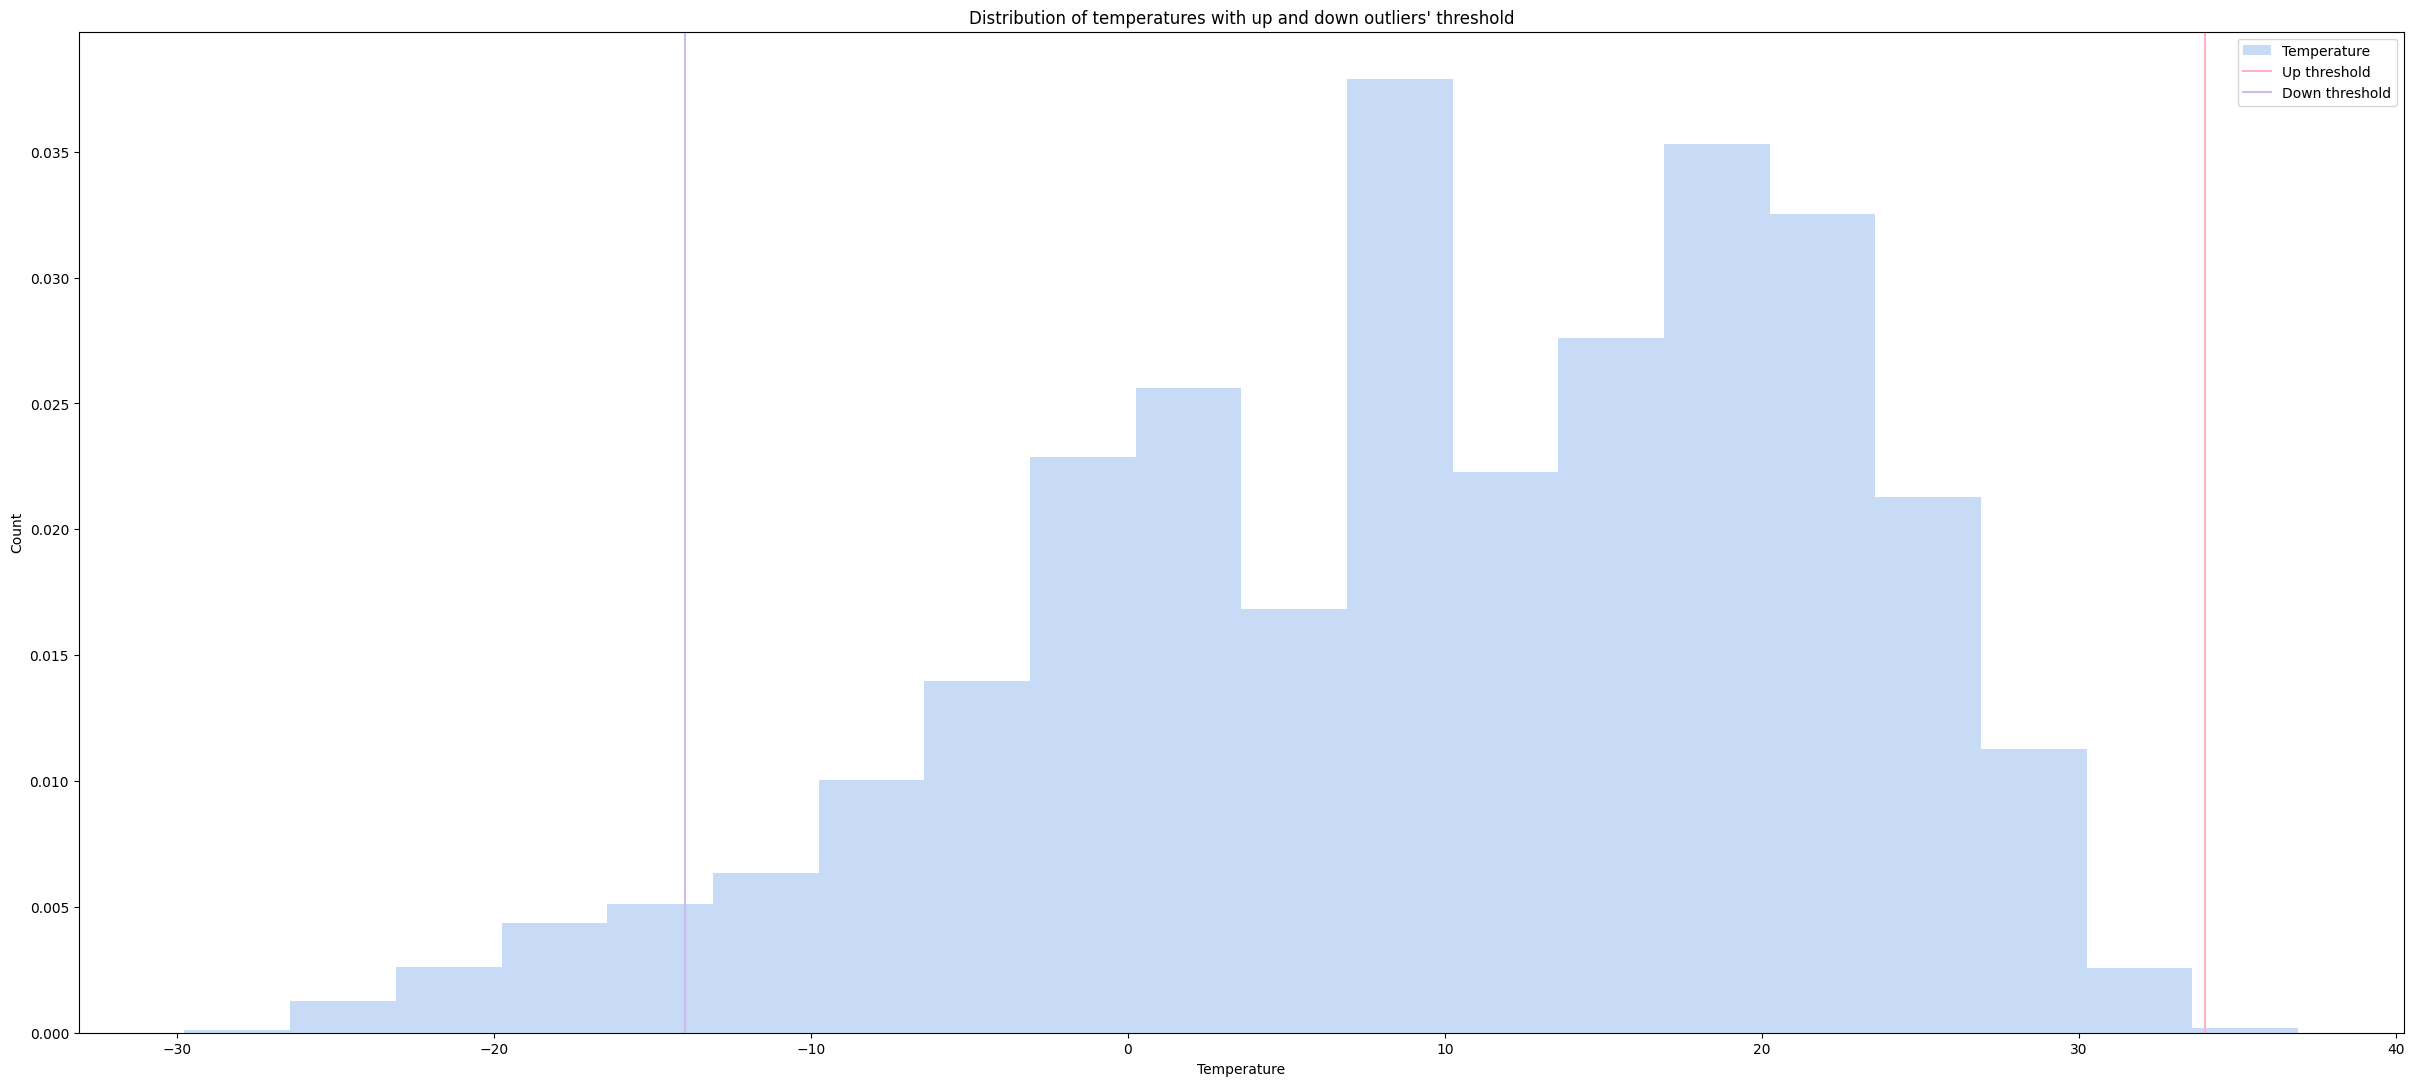

In [44]:
# statistics
mean = (sum(df["temp_c"])/df["temp_c"].shape[0])
std = (np.sqrt(sum((df["temp_c"]-mean)**2) / df["temp_c"].shape[0]))

# fix threshold
up_threshold = (mean + (2*std))
down_threshold = (mean - (2*std))

fig = plt.figure(figsize=(30, 13))
plt.subplot(1, 1, 1)
plt.hist(df["temp_c"], color="#A3C4F3", bins=20, density=True, alpha=0.6, label="Temperature")
plt.axvline(x=up_threshold, color="#FFB3C1", label="Up threshold")
plt.axvline(x=down_threshold, color="#CFBAF0", label="Down threshold")
plt.title("Distribution of temperatures with up and down outliers' threshold")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.legend(loc="best")
plt.subplots_adjust(hspace=0.5)
plt.show()

### Encodage des variables catégorielles

In [ ]:
# Encodage des variables categorielles
#df = pd.get_dummies(df, columns=['moment', 'saison','weather_cat','cloud_cat'], drop_first=True)

In [48]:
# Puis récupérez les nouvelles colonnes dynamiquement
#moment_cols = [c for c in df.columns if c.startswith('moment_')]
#saison_cols  = [c for c in df.columns if c.startswith('saison_')]
#cloud_cat_cols  = [c for c in df.columns if c.startswith('cloud_cat_')]
#weather_cat_cols  = [c for c in df.columns if c.startswith('weather_cat_')]

#types numerics
type_numeric = ["int8", "int16", "int32", "int64", "float16", "float32", "float64"]

# colonnes numeriques
numerical_cols = [col for col in list(df.columns) if df[col].dtypes in type_numeric]

numerical_cols.remove('traffic')
#--- les variables dumies
#numerical_cols.extend(moment_cols + saison_cols + cloud_cat_cols + weather_cat_cols)

target = 'traffic'
# variables categ
categorical_cols = ['holiday', 'weather','weather_description','moment','saison','weather_cat','cloud_cat']


### Vérification des hypothèses de la régression linéaire

La régression linéaire repose sur cinq hypothèses fondamentales. Avant d'interpréter les résultats, nous devons vérifier leur validité

### Vérification de la multicolinéarité

In [ ]:
# Calcul de la matrice de corrélation des features
corr_matrix = df[numerical_cols].corr().abs()

# Identification des paires hautement corrélées (> 0.8)
high_corr = np.where(corr_matrix > 0.7)
high_corr_pairs = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y])
                   for x, y in zip(*high_corr) if x != y and x < y]

print("Paires hautement corrélées :")
for var1, var2, corr in high_corr_pairs:
    print(f"  {var1} - {var2}: {corr:.3f}")



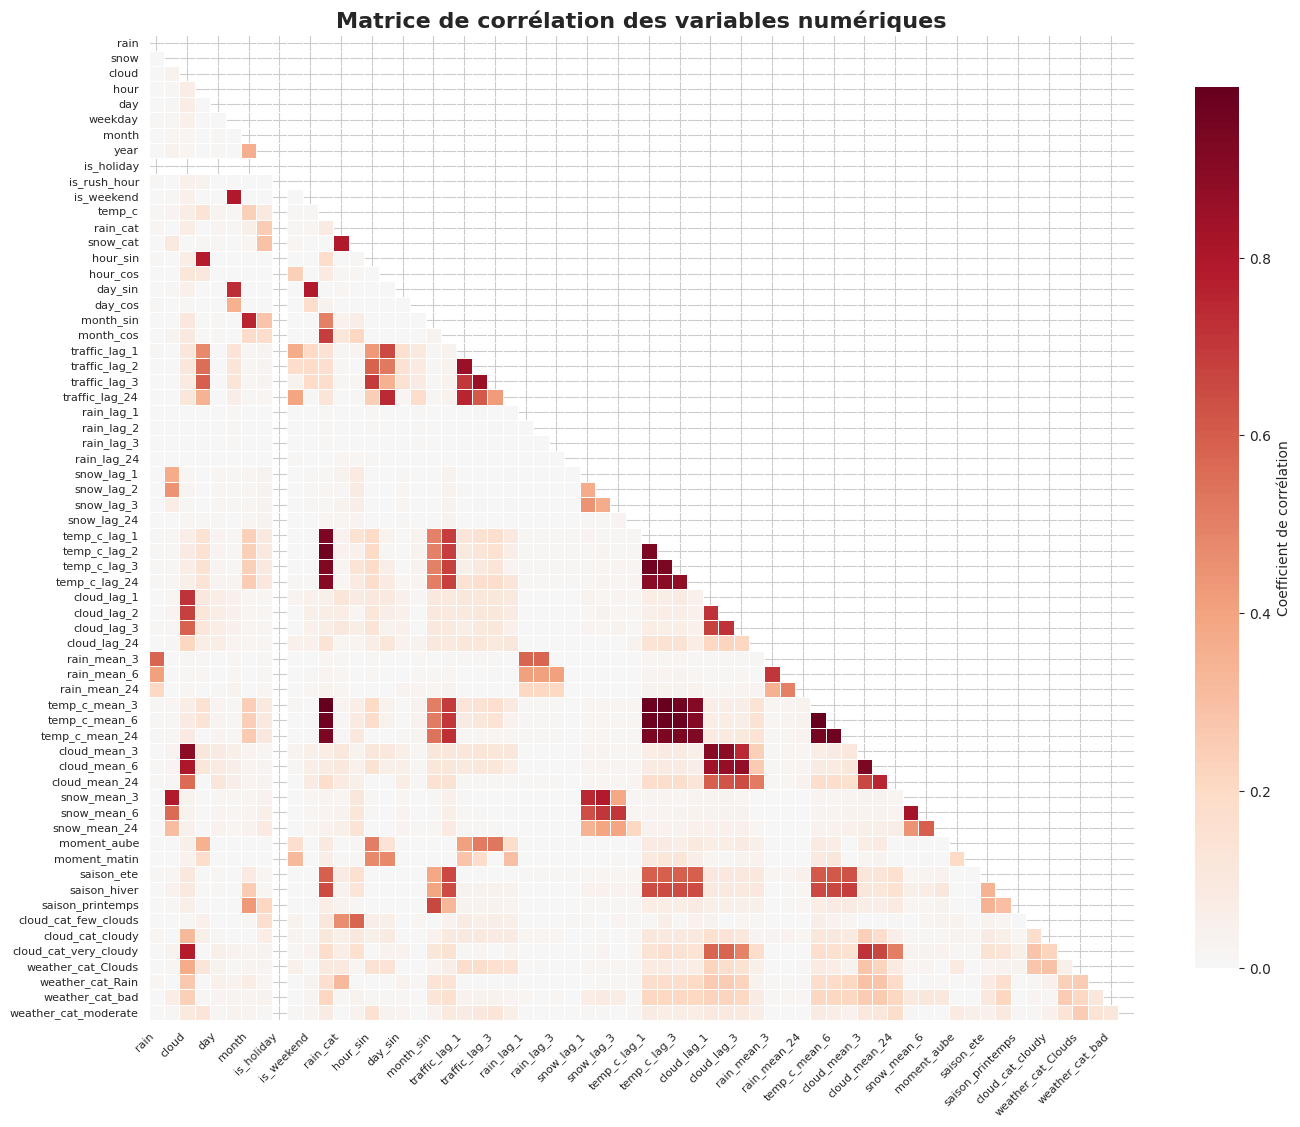

In [ ]:
# Configuration du style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 12))

# Heatmap de la matrice de corrélation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            cmap='RdBu_r',
            center=0,
            annot=False,
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"})

plt.title('Matrice de corrélation des variables numériques', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:


# Create a temporary DataFrame for VIF calculation to avoid modifying the original df unnecessarily
df_vif = df[numerical_cols].copy()

# Convert boolean columns to integer (0 or 1)
# This is necessary because get_dummies creates boolean columns, and statsmodels' OLS struggles with them.
for col in df_vif.select_dtypes(include='bool').columns:
    df_vif[col] = df_vif[col].astype(int)

# Replace infinite values with NaN and then drop rows containing any NaN (including those from infs)
if df_vif.isin([np.inf, -np.inf]).any().any():
    print("Warning: Infinite values found in data for VIF calculation. Replacing with NaN.")
    df_vif.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop any rows that still contain NaN values after the initial cleaning or inf replacement
if df_vif.isnull().any().any():
    print("Warning: NaN values found in data for VIF calculation. Dropping rows with NaNs.")
    df_vif.dropna(inplace=True)

# Check if the DataFrame is empty after cleaning
if df_vif.empty:
    print("Error: DataFrame is empty after cleaning for VIF calculation. Cannot compute VIF.")
else:
    # Calcul du VIF pour chaque variable
    vif_data = pd.DataFrame()
    vif_data['feature'] = numerical_cols
    # Iterate over the columns of df_vif, ensuring consistency with the numerical_cols list
    vif_data['VIF'] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

    print("Facteurs d'inflation de la variance (VIF) :")
    print(vif_data.sort_values('VIF', ascending=False))

    print("\nInterprétation :")
    print("- VIF < 5 : pas de multicolinéarité problématique")
    print("- 5 < VIF < 10 : multicolinéarité modérée")
    print("- VIF > 10 : multicolinéarité sévère à traiter")


Après toutes les étapes de préparation, de feature engineering et de réduction de la multicolinéarité, nous pouvons enfin passer à la phase de modélisation.

## Justification du choix de la régression Ridge comme modèle de base

Dans le cadre de cette étude prédictive du volume de trafic routier, le choix de la régression Ridge comme modèle de référence (*baseline*) repose sur des arguments à la fois méthodologiques et empiriques. La régression linéaire classique (OLS) constitue traditionnellement le point de départ naturel de toute démarche de modélisation supervisée en raison de sa simplicité, de son interprétabilité et de sa rapidité d'exécution. Cependant, l'analyse exploratoire menée en amont a mis en évidence plusieurs caractéristiques du dataset qui rendent l'OLS inadapté dans sa forme brute : la présence de multicolinéarité significative entre certaines variables — notamment entre `traffic_lag_2` et `traffic_lag_24`, entre les variables saisonnières et les encodages cycliques des mois, ou encore entre `cloud` et ses catégories dérivées — se traduisait par des VIF largement supérieurs à 10, signe d'une instabilité potentielle des coefficients estimés. La régression Ridge, en introduisant une pénalité L2 qui contraint la norme des coefficients sans en annuler aucun, permet de conserver l'ensemble du signal informationnel contenu dans les features engineerées tout en stabilisant l'estimation face à cette redondance. Elle constitue ainsi un compromis idéal entre la rigueur interprétative de la régression linéaire et la robustesse nécessaire face à un espace de features riche et corrélé. Par ailleurs, choisir Ridge comme baseline présente un avantage stratégique : ses performances, nécessairement limitées par l'hypothèse de linéarité que l'exploration graphique a partiellement remise en question — les relations entre trafic, température et variables temporelles présentant des structures non-linéaires manifestes — serviront d'étalon de mesure objectif pour quantifier le gain apporté par les modèles à base d'arbres de décision, Random Forest et XGBoost, qui seront évalués dans les étapes suivantes.

## Préparation des données

In [53]:

# ============================================
#  Splite
# ============================================
def split_temporel(df, target_col, date_col,numerical_cols,
                   train_ratio=0.70,
                   val_ratio=0.15):
      """
      Split chronologique strict — respecte l'ordre temporel.

      Returns : X_train, X_val, X_test, y_train, y_val, y_test
      """
      # Trier par date
      df = df.sort_values(date_col).reset_index(drop=True)

      n         = len(df)
      train_end = int(n * train_ratio)
      val_end   = int(n * (train_ratio + val_ratio))

    
      cols_to_drop = [col for col in list(df.columns) if col not in numerical_cols]
      cols_to_drop.remove(date_col)
      X = df.drop(columns=cols_to_drop)
      y = df[target_col]

      X_train = X.iloc[:train_end]
      X_val   = X.iloc[train_end:val_end]
      X_test_  = X.iloc[val_end:]

      y_train = y.iloc[:train_end]
      y_val   = y.iloc[train_end:val_end]
      y_test  = y.iloc[val_end:]

      # Résumé
      print("=" * 55)
      print("  SPLIT TEMPOREL")
      print("=" * 55)
      print(f"Train      : {len(X_train):>6} obs "
            f"({df[date_col].iloc[0].date()} → "
            f"{df[date_col].iloc[train_end].date()})")
      print(f"Validation : {len(X_val):>6} obs "
            f"({df[date_col].iloc[train_end].date()} → "
            f"{df[date_col].iloc[val_end].date()})")
      print(f"Test       : {len(X_test_):>6} obs "
            f"({df[date_col].iloc[val_end].date()} → "
            f"{df[date_col].iloc[-1].date()})")
      print(f"\nTotal      : {n:>6} obs")
      print(f"Ratio      : {train_ratio:.0%} / "
            f"{val_ratio:.0%} / "
            f"{1-train_ratio-val_ratio:.0%}")
      print("=" * 55)

      #preparer les données à retourner
      X_train = X_train.drop(columns = date_col)
      X_val = X_val.drop(columns = date_col)
      X_test = X_test_.drop(columns = date_col)
      return X_train, X_val, X_test, X_test_, y_train, y_val, y_test

X_train, X_val, X_test, X_test_, y_train, y_val, y_test = split_temporel(
    df,
    target_col="traffic",
    date_col="datetime",
    numerical_cols = numerical_cols,
    train_ratio=0.70,
    val_ratio=0.15
)


# Standardisation
num_cols_pas_scaler = [
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "is_rush_hour",
    "is_holiday",
    "is_weekend",
    "snow_cat",
    "rain_cat"
]
num_col_to_scale = [col for col in numerical_cols if col not in num_cols_pas_scaler]


scaler = StandardScaler()
def standardisation(X_train, X_val, X_test, num_col_to_scale):
    # standariser
    
    X_train_scaled = X_train.copy()
    X_train_scaled[num_col_to_scale] = scaler.fit_transform(X_train[num_col_to_scale])

    X_val_scaled = X_val.copy()
    X_val_scaled[num_col_to_scale] = scaler.transform(                           X_val[num_col_to_scale])

    X_test_scaled = X_test.copy()
    X_test_scaled[num_col_to_scale]  = scaler.transform(X_test[num_col_to_scale])

    return X_train_scaled, X_val_scaled, X_test_scaled

X_train_scaled, X_val_scaled, X_test_scaled = standardisation(X_train, X_val, X_test, num_col_to_scale)

  SPLIT TEMPOREL
Train      :  19924 obs (2015-07-03 → 2017-10-10)
Validation :   4270 obs (2017-10-10 → 2018-04-06)
Test       :   4270 obs (2018-04-06 → 2018-09-30)

Total      :  28464 obs
Ratio      : 70% / 15% / 15%


### Fonction pour l'évaluation

In [6]:
#=======Validation sur les données d'évalution==============
def evaluer_modele(model,
                   X_train,
                   y_train,
                   X_val,
                   y_val,
                   X_test,
                   y_test,
                   debut_date,
                   fin_date,
                   nom_modele="Modèle"
                ):
    """
    Évaluation complète d'un modèle de régression.

    Parameters :
    ------------
    model       : modèle entraîné (sklearn, xgboost...)
    X_train, y_train : données d'entraînement
    X_val,   y_val   : données de validation
    X_test,  y_test  : données de test
    nom_modele       : nom du modèle pour affichage

    Returns :
    ---------
    dict : dictionnaire des métriques
    """

    # ============================================
    # 1. PRÉDICTIONS SUR LES 3 ENSEMBLES
    # ============================================
    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)
    y_pred_test  = model.predict(X_test)

    # ============================================
    # 2. CALCUL DES MÉTRIQUES
    # ============================================
    # MAPE sécurisé contre les divisions par zéro
    def mape_safe(y_true, y_pred, seuil=10):
        mask = np.array(y_true) > seuil
        if mask.sum() == 0:
            return np.nan
        return np.mean(np.abs(
            (np.array(y_true)[mask] - np.array(y_pred)[mask])
            / np.array(y_true)[mask]
        )) * 100

    def calculer_metriques(y_true, y_pred):
        return {
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE" : mean_absolute_error(y_true, y_pred),
            "MAPE": mape_safe(y_true, y_pred),
            "R2"  : r2_score(y_true, y_pred)
        }

    metriques = {
        "Train"     : calculer_metriques(y_train, y_pred_train),
        "Validation": calculer_metriques(y_val,   y_pred_val),
        "Test"      : calculer_metriques(y_test,  y_pred_test)
    }

    # ============================================
    # 3. AFFICHAGE TABLEAU DES MÉTRIQUES
    # ============================================
    print("=" * 60)
    print(f"  ÉVALUATION — {nom_modele.upper()}")
    print("=" * 60)

    df_metriques = pd.DataFrame(metriques).T
    df_metriques = df_metriques[["RMSE", "MAE", "MAPE", "R2"]]
    print(df_metriques.round(3).to_string())

    # Diagnostic overfitting
    gap_r2 = metriques["Train"]["R2"] - metriques["Validation"]["R2"]
    print(f"\nGap R² (Train - Val) : {gap_r2:.3f}", end=" ")
    if gap_r2 > 0.10:
        print("⚠️  Overfitting")
    elif -0.05 <= gap_r2 <= 0.10:
        print("✅ Bonne généralisation")
    else:
        print("ℹ️  Val/Test meilleurs que Train "
              "→ vérifier la variance par période")
    print("=" * 60)

    # ============================================
    # 4. VISUALISATIONS
    # ============================================
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"Évaluation complète — {nom_modele}",
                 fontsize=14, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 3, figure=fig)

    # --- Graphique 1 : Réel vs Prédit (Validation) ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_val, y_pred_val, alpha=0.2, s=5, color="#3498DB")
    lim = [min(y_val.min(), y_pred_val.min()),
           max(y_val.max(), y_pred_val.max())]
    ax1.plot(lim, lim, color="red", linestyle="--", linewidth=1.5)
    ax1.set_title("Réel vs Prédit (Validation)")
    ax1.set_xlabel("Valeurs réelles")
    ax1.set_ylabel("Valeurs prédites")
    ax1.text(0.05, 0.92,
             f"R² = {metriques['Validation']['R2']:.3f}",
             transform=ax1.transAxes,
             fontsize=10, color="red")

    # --- Graphique 2 : Distribution des résidus ---
    ax2 = fig.add_subplot(gs[0, 1])
    residus_val = y_val - y_pred_val
    ax2.hist(residus_val, bins=60,
             color="#AED6F1", edgecolor="white", density=True)
    ax2.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax2.axvline(residus_val.mean(), color="orange",
                linestyle="--", linewidth=1.5,
                label=f"Moyenne = {residus_val.mean():.0f}")
    ax2.set_title("Distribution des résidus (Validation)")
    ax2.set_xlabel("Résidu")
    ax2.set_ylabel("Densité")
    ax2.legend(fontsize=9)

    # --- Graphique 3 : Résidus vs Valeurs prédites ---
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(y_pred_val, residus_val, alpha=0.2, s=5, color="#2ECC71")
    ax3.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax3.set_title("Résidus vs Valeurs prédites")
    ax3.set_xlabel("Valeurs prédites")
    ax3.set_ylabel("Résidus")

    # --- Graphique 4 : Comparaison Train/Val/Test ---
    ax4 = fig.add_subplot(gs[1, 0])
    ensembles = ["Train", "Validation", "Test"]
    r2_vals   = [metriques[e]["R2"]   for e in ensembles]
    rmse_vals = [metriques[e]["RMSE"] for e in ensembles]
    colors    = ["#3498DB", "#E67E22", "#2ECC71"]

    bars = ax4.bar(ensembles, r2_vals, color=colors, edgecolor="white")
    for bar, val in zip(bars, r2_vals):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=10,
                 fontweight="bold")
    ax4.set_title("R² par ensemble")
    ax4.set_ylabel("R²")
    ax4.set_ylim(0, 1)

    # --- Graphique 5 : RMSE par ensemble ---
    ax5 = fig.add_subplot(gs[1, 1])
    bars2 = ax5.bar(ensembles, rmse_vals, color=colors, edgecolor="white")
    for bar, val in zip(bars2, rmse_vals):
        ax5.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f"{val:.0f}", ha="center", fontsize=10,
                 fontweight="bold")
    ax5.set_title("RMSE par ensemble")
    ax5.set_ylabel("RMSE (véhicules)")

    fig.tight_layout()
    fig.show()

    # ============================================
    # 5. RETOURNER LES MÉTRIQUES
    # ============================================
    return metriques


# ============CROSS VALIDATION================================
def tscv_evaluation(model, X, y, n_splits=5):
    """
    Validation croisée temporelle — respecte l'ordre chronologique.
    Chaque fold entraîne sur le passé et valide sur le futur immédiat.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    rmse_scores = []
    r2_scores   = []

    print("=" * 55)
    print("  TIME SERIES CROSS VALIDATION")
    print("=" * 55)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_fold_train = X.iloc[train_idx]
        X_fold_val   = X.iloc[val_idx]
        y_fold_train = y.iloc[train_idx]
        y_fold_val   = y.iloc[val_idx]

        model.fit(X_fold_train, y_fold_train)
        y_pred = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, y_pred))
        r2   = r2_score(y_fold_val, y_pred)

        rmse_scores.append(rmse)
        r2_scores.append(r2)

        print(f"Fold {fold+1} | "
              f"Train : {len(train_idx):>5} obs | "
              f"Val : {len(val_idx):>5} obs | "
              f"RMSE : {rmse:>7.0f} | "
              f"R² : {r2:.3f}")

    print("-" * 55)
    print(f"Moyenne    | RMSE : {np.mean(rmse_scores):>7.0f} "
          f"± {np.std(rmse_scores):.0f} | "
          f"R² : {np.mean(r2_scores):.3f} "
          f"± {np.std(r2_scores):.3f}")
    print("=" * 55)

    return {
        "modele" : model.__class__.__name__,
        "rmse_mean": np.mean(rmse_scores),
        "rmse_std" : np.std(rmse_scores),
        "r2_mean"  : np.mean(r2_scores),
        "r2_std"   : np.std(r2_scores)
    }


# ============================================
# COMPARAISON FINALE DES 3 MODÈLES
# ============================================
def comparaison_finale(resultats_dict):

    rows = []
    for nom, res in resultats_dict.items():
        rows.append({
            "Modèle"    : nom,
            "R² Train"  : round(res["Train"]["R2"],       3),
            "R² Val"    : round(res["Validation"]["R2"],  3),
            "R² Test"   : round(res["Test"]["R2"],        3),
            "RMSE Val"  : round(res["Validation"]["RMSE"],0),
            "RMSE Test" : round(res["Test"]["RMSE"],      0),
            "MAE Test"  : round(res["Test"]["MAE"],       0),
            "MAPE Test" : round(res["Test"]["MAPE"],      1)
        })

    df_comp = pd.DataFrame(rows).set_index("Modèle")

    print("\n" + "=" * 70)
    print("  COMPARAISON FINALE — RIDGE vs RF vs XGBOOST")
    print("=" * 70)
    print(df_comp.to_string())

    # Meilleur modèle
    meilleur_r2   = df_comp["R² Test"].idxmax()
    meilleur_rmse = df_comp["RMSE Test"].idxmin()

    print(f"\n Meilleur R²   : {meilleur_r2} "
          f"({df_comp.loc[meilleur_r2, 'R² Test']})")
    print(f" Meilleur RMSE : {meilleur_rmse} "
          f"({df_comp.loc[meilleur_rmse, 'RMSE Test']:.0f} véhicules)")
    print("=" * 70)

    # Graphique comparatif
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    modeles = df_comp.index.tolist()
    colors  = ["#3498DB", "#2ECC71", "#E74C3C"]

    # R² par ensemble
    x = np.arange(len(modeles))
    width = 0.25
    axes[0].bar(x - width, df_comp["R² Train"],
                width, label="Train",      color="#AED6F1")
    axes[0].bar(x,         df_comp["R² Val"],
                width, label="Validation", color="#A9DFBF")
    axes[0].bar(x + width, df_comp["R² Test"],
                width, label="Test",       color="#F1948A")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(modeles, rotation=15)
    axes[0].set_title("R² par ensemble")
    axes[0].set_ylabel("R²")
    axes[0].legend()
    axes[0].set_ylim(0, 1)

    # RMSE Test
    bars = axes[1].bar(modeles,
                       df_comp["RMSE Test"],
                       color=colors, edgecolor="white")
    for bar, val in zip(bars, df_comp["RMSE Test"]):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 5,
                     f"{val:.0f}", ha="center",
                     fontweight="bold")
    axes[1].set_title("RMSE Test (↓ meilleur)")
    axes[1].set_ylabel("RMSE (véhicules)")

    # MAPE Test
    bars2 = axes[2].bar(modeles,
                        df_comp["MAPE Test"],
                        color=colors, edgecolor="white")
    for bar, val in zip(bars2, df_comp["MAPE Test"]):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f"{val:.1f}%", ha="center",
                     fontweight="bold")
    axes[2].set_title("MAPE Test (↓ meilleur)")
    axes[2].set_ylabel("MAPE (%)")
    axes[2].axhline(20, color="red",
                    linestyle="--", linewidth=1,
                    label="Seuil 20%")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return df_comp

#Comparaison des données predites et réelles

def comparer_predictions(model, X_test, y_test, datetime_test,
                          nom_modele="Modèle",
                          date_journee=None,
                          date_debut_semaine=None):
    """
    Compare les prédictions et valeurs réelles sur :
    - Une semaine complète (agrégation journalière)
    - Une journée type (profil horaire)

    Parameters :
    ------------
    model            : modèle entraîné
    X_test           : features de test
    y_test           : cible réelle de test
    datetime_test    : Series datetime correspondant au test
    nom_modele       : nom du modèle pour les titres
    date_journee     : str "YYYY-MM-DD" — journée à analyser
                       (None = premier mardi disponible dans le test)
    date_debut_semaine : str "YYYY-MM-DD" — début de la semaine
                       (None = première semaine complète du test)

    Returns :
    ---------
    resultats : DataFrame avec datetime, traffic réel, prédiction
    """

    # ============================================
    # 1. CONSTRUIRE LE DATAFRAME DE RÉSULTATS
    # ============================================
    y_pred = model.predict(X_test)

    resultats = pd.DataFrame({
        "datetime"  : datetime_test.values,
        "traffic"   : y_test.values,
        "prediction": y_pred
    }).sort_values("datetime").reset_index(drop=True)

    resultats["datetime"] = pd.to_datetime(resultats["datetime"])
    resultats["date"]     = resultats["datetime"].dt.date
    resultats["heure"]    = resultats["datetime"].dt.hour
    resultats["weekday"]  = resultats["datetime"].dt.day_name()

    # ============================================
    # 2. SÉLECTION AUTOMATIQUE DES PÉRIODES
    # ============================================
    # Semaine : 7 jours consécutifs à partir du début du test
    if date_debut_semaine is None:
        date_debut_semaine = resultats["datetime"].min().strftime("%Y-%m-%d")

    date_fin_semaine = (pd.to_datetime(date_debut_semaine) +
                        pd.Timedelta(days=6)).strftime("%Y-%m-%d")

    # Journée : premier mardi disponible si non spécifié
    if date_journee is None:
        mardis = resultats[resultats["weekday"] == "Tuesday"]["date"].unique()
        date_journee = str(mardis[0]) if len(mardis) > 0 else \
                       str(resultats["date"].unique()[1])

    # ============================================
    # 3. FILTRAGE DES DONNÉES
    # ============================================
    # Semaine — agrégation journalière
    semaine = resultats[
        (resultats["datetime"] >= date_debut_semaine) &
        (resultats["datetime"] <= date_fin_semaine + " 23:00:00")
    ].groupby("date").agg(
        traffic_reel = ("traffic",    "sum"),
        prediction   = ("prediction", "sum")
    ).reset_index()
    semaine["date"] = pd.to_datetime(semaine["date"])
    semaine["jour"] = semaine["date"].dt.strftime("%a\n%d/%m")

    # Journée type — profil horaire
    journee = resultats[
        resultats["datetime"].dt.strftime("%Y-%m-%d") == date_journee
    ].sort_values("heure")

    # ============================================
    # 4. VISUALISATION
    # ============================================
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"Réel vs Prédit — {nom_modele}",
                 fontsize=14, fontweight="bold", y=1.02)

    # --- Graphique 1 : Semaine complète ---
    ax1 = axes[0]
    x    = np.arange(len(semaine))
    width = 0.35

    bars1 = ax1.bar(x - width/2,
                    semaine["traffic_reel"],
                    width,
                    label="Réel",
                    color="steelblue",
                    alpha=0.85,
                    edgecolor="white")
    bars2 = ax1.bar(x + width/2,
                    semaine["prediction"],
                    width,
                    label="Prédit",
                    color="coral",
                    alpha=0.85,
                    edgecolor="white")

    # Annotations erreur relative
    for i, (reel, pred) in enumerate(zip(semaine["traffic_reel"],
                                          semaine["prediction"])):
        erreur = abs(reel - pred) / reel * 100 if reel > 0 else 0
        ax1.text(i, max(reel, pred) + max(semaine["traffic_reel"]) * 0.01,
                 f"{erreur:.1f}%",
                 ha="center", va="bottom",
                 fontsize=8, color="gray")

    ax1.set_xticks(x)
    ax1.set_xticklabels(semaine["jour"], fontsize=10)
    ax1.set_xlabel("Jour de la semaine", fontsize=12)
    ax1.set_ylabel("Volume de trafic total (véhicules)", fontsize=12)
    ax1.set_title(
        f"Trafic journalier — semaine du "
        f"{pd.to_datetime(date_debut_semaine).strftime('%d/%m/%Y')}",
        fontsize=13, fontweight="bold"
    )
    ax1.legend(fontsize=11)
    ax1.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax1.set_axisbelow(True)

    # --- Graphique 2 : Journée type ---
    ax2 = axes[1]

    ax2.plot(journee["heure"],
             journee["traffic"],
             marker="o",
             label="Réel",
             color="steelblue",
             linewidth=2,
             markersize=6)

    ax2.plot(journee["heure"],
             journee["prediction"],
             marker="s",
             label="Prédit",
             color="coral",
             linewidth=2,
             markersize=6,
             linestyle="--")

    # Zone d'erreur
    ax2.fill_between(journee["heure"],
                     journee["traffic"],
                     journee["prediction"],
                     alpha=0.15,
                     color="purple",
                     label="Écart")

    # Repères heures de pointe
    ax2.axvspan(7,  9,  alpha=0.08, color="orange",
                label="Pointe matin")
    ax2.axvspan(17, 19, alpha=0.08, color="green",
                label="Pointe soir")

    ax2.set_xticks(range(0, 24, 2))
    ax2.set_xlabel("Heure de la journée", fontsize=12)
    ax2.set_ylabel("Volume de trafic (véhicules/heure)", fontsize=12)

    jour_label = pd.to_datetime(date_journee).strftime("%A %d %B %Y")
    ax2.set_title(
        f"Profil horaire — {jour_label}",
        fontsize=13, fontweight="bold"
    )
    ax2.legend(fontsize=10)
    ax2.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax2.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    # ============================================
    # 5. MÉTRIQUES PAR JOUR DE LA SEMAINE
    # ============================================
    metriques_jour = resultats.groupby("weekday").apply(
        lambda g: pd.Series({
            "RMSE": np.sqrt(np.mean((g["traffic"] - g["prediction"])**2)),
            "MAE" : np.mean(np.abs(g["traffic"] - g["prediction"])),
            "R2"  : 1 - np.sum((g["traffic"] - g["prediction"])**2) /
                        np.sum((g["traffic"] - g["traffic"].mean())**2)
        })
    ).round(3)

    # Réordonner par jour de semaine
    ordre_jours = ["Monday","Tuesday","Wednesday",
                   "Thursday","Friday","Saturday","Sunday"]
    metriques_jour = metriques_jour.reindex(
        [j for j in ordre_jours if j in metriques_jour.index]
    )

    print("\n📊 Métriques par jour de la semaine :")
    print("=" * 45)
    print(metriques_jour.to_string())
    print("=" * 45)

    return resultats


# Regression Ridge

In [ ]:

# ============================================
# ÉTAPE 1 : Trouver le meilleur alpha via RidgeCV
# ============================================
# Tester plusieurs valeurs de alpha
alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5,                    # validation croisée 5 folds
    scoring="neg_mean_squared_error"
)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Meilleur alpha : {ridge_cv.alpha_}")

# ============================================
# ÉTAPE 2 : Entraîner avec le meilleur alpha
# ============================================
model_ridge = Ridge(alpha=ridge_cv.alpha_)
model_ridge.fit(X_train_scaled, y_train)



Meilleur alpha : 1000.0


Ridge(alpha=np.float64(1000.0))

  ÉVALUATION — RIDGE
               RMSE      MAE    MAPE     R2
Train       786.203  562.340  38.942  0.823
Validation  650.236  467.953  31.901  0.891
Test        617.543  433.615  28.017  0.903

Gap R² (Train - Val) : -0.068 ℹ️  Val/Test meilleurs que Train → vérifier la variance par période


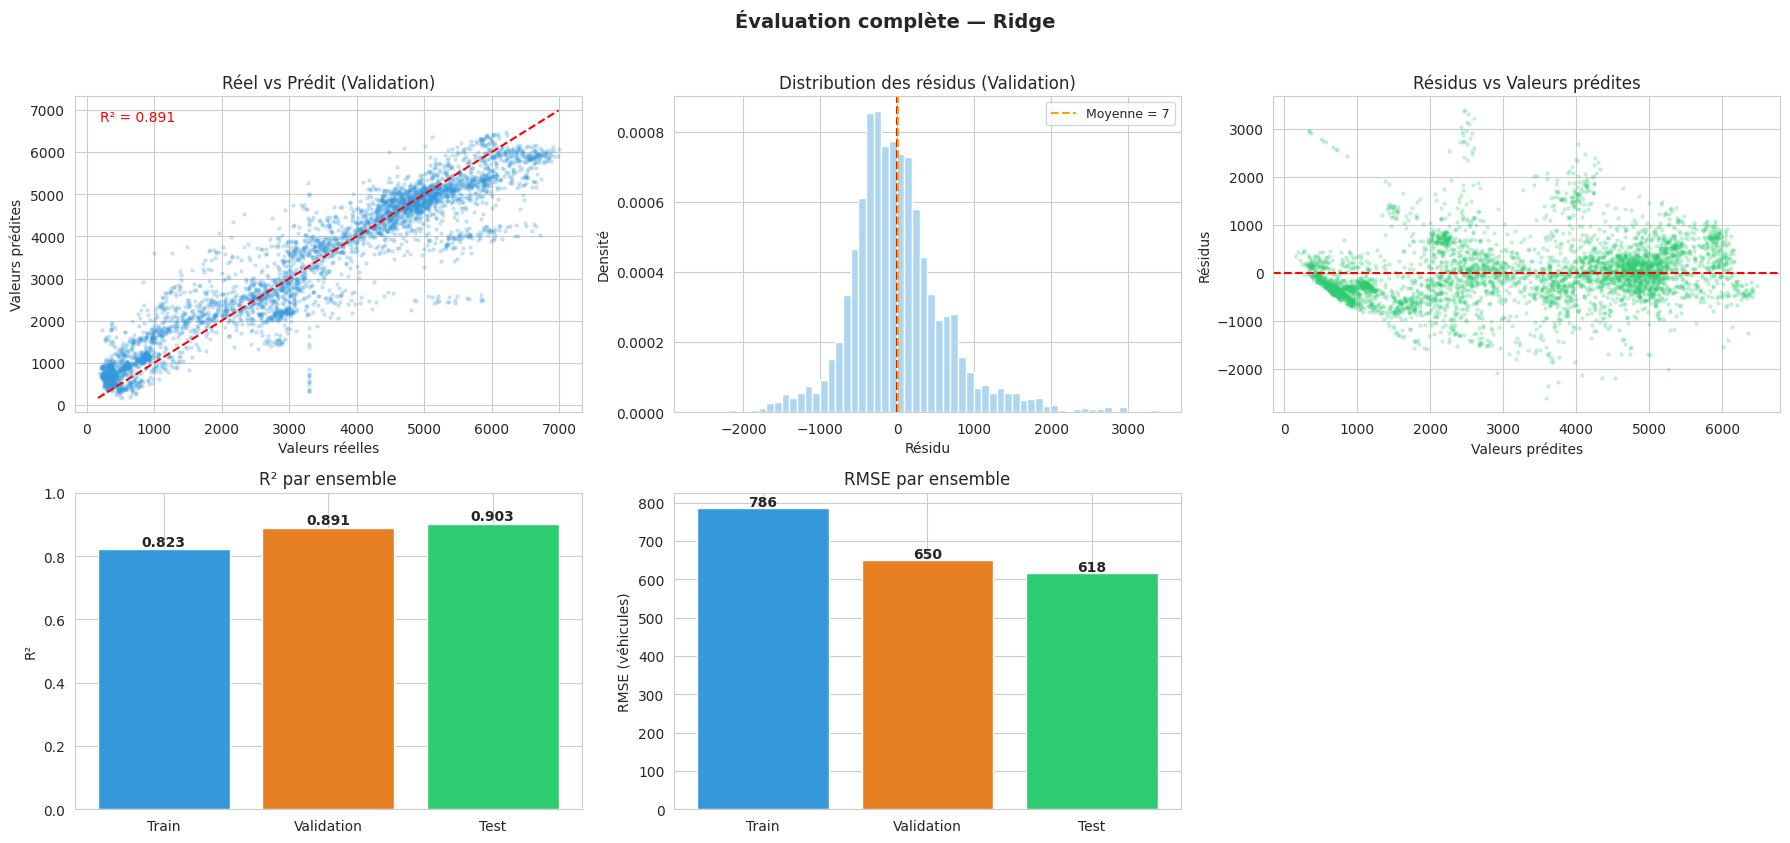

In [190]:
# Évaluer
resultats_ridge = evaluer_modele(
    model_ridge,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    X_test_scaled,  y_test,
    debut_date="2018-07-01",
    fin_date="2018-07-07",
    nom_modele="Ridge"
)

Les résultats de la régression Ridge sont remarquablement bons pour un modèle linéaire appliqué à un phénomène aussi complexe que le trafic urbain. Le R² de 0.903 sur le jeu de test signifie que le modèle explique 90.3% de la variance du volume de trafic, ce qui dépasse largement les attentes initiales fixées pour un modèle baseline. Le RMSE de 617 véhicules sur le test indique qu'en moyenne, les prédictions s'écartent de la réalité de moins de 620 véhicules par heure — une précision acceptable dans un contexte de gestion de trafic où les volumes varient de 0 à 7 000 véhicules.

## Interprétation des graphiques

L'analyse visuelle des cinq graphiques d'évaluation confirme et enrichit les conclusions tirées des métriques numériques, tout en révélant des nuances importantes sur le comportement du modèle Ridge.

Le graphique **réel vs prédit** montre un alignement remarquable des points autour de la diagonale parfaite (R² = 0.891 sur la validation), attestant d'une relation linéaire forte et bien capturée par le modèle. On observe néanmoins deux zones de dispersion caractéristiques : une légère **sous-estimation systématique pour les faibles valeurs de trafic** (0–1000 véhicules), où les points s'écartent au-dessus de la diagonale, et une tendance à la **sous-estimation des pics élevés** (au-delà de 5000 véhicules), où les prédictions plafonnent — comportement typique d'un modèle linéaire qui lisse les extrêmes.

La **distribution des résidus** présente une forme quasi-gaussienne centrée sur une moyenne de 7 véhicules, ce qui témoigne d'un biais quasi nul et d'une absence de biais systématique global — une propriété fondamentale d'un bon modèle de régression. Toutefois, la distribution est **asymétrique vers la droite** avec une queue étalée jusqu'à +3000, révélant que le modèle commet occasionnellement de grosses erreurs de sous-estimation sur des pics de trafic exceptionnels qu'il ne parvient pas à anticiper.

Le graphique **résidus vs valeurs prédites** est le plus informatif sur les limites structurelles du modèle. On y observe clairement une **structure en éventail** — les résidus s'élargissent à mesure que les valeurs prédites augmentent — ce qui constitue une violation de l'hypothèse d'homoscédasticité. Plus révélateur encore, une **bande de résidus fortement négatifs** apparaît pour les faibles valeurs prédites (0–1000), correspondant vraisemblablement aux heures nocturnes où le modèle prédit un trafic positif alors que la réalité est proche de zéro. Cette structure suggère que les relations entre le trafic et certaines variables ne sont pas purement linéaires et que des transformations supplémentaires ou un modèle non-linéaire pourraient corriger ces déviations systématiques.

Enfin, les graphiques en barres **R² et RMSE par ensemble** confirment la progression monotone déjà commentée (R² : 0.823 → 0.891 → 0.903 ; RMSE : 786 → 650 → 618), soulignant l'absence totale d'overfitting et la robustesse de la généralisation du modèle Ridge — ce qui en fait une baseline solide et fiable pour la comparaison avec les modèles non-linéaires à venir.

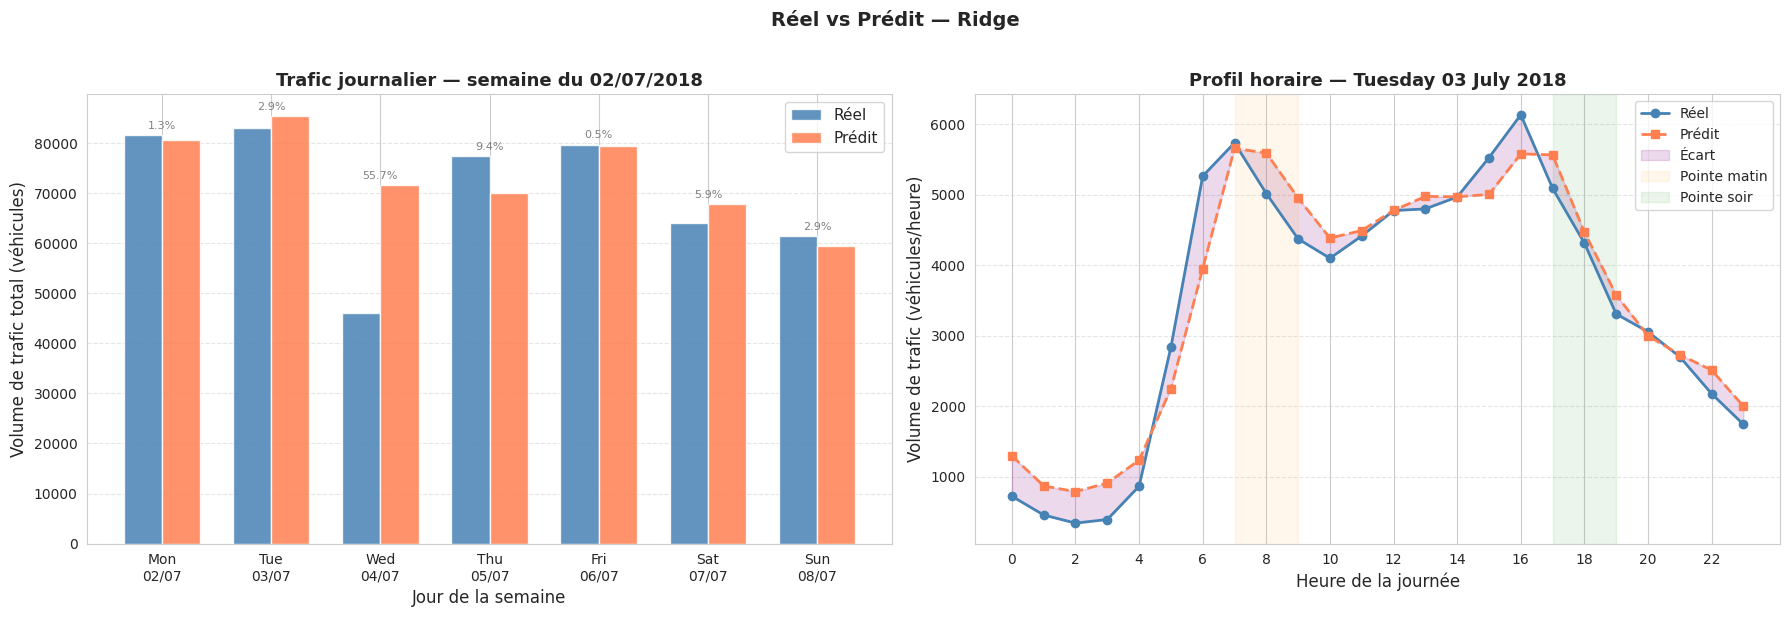


📊 Métriques par jour de la semaine :
              RMSE      MAE     R2
weekday                           
Monday     949.233  676.187  0.782
Tuesday    604.931  452.645  0.916
Wednesday  588.246  433.455  0.923
Thursday   549.508  400.860  0.931
Friday     487.029  367.774  0.941
Saturday   647.036  447.807  0.825
Sunday     336.460  265.161  0.949


/tmp/ipykernel_11583/11853452.py:488: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metriques_jour = resultats.groupby("weekday").apply(


In [192]:

ridge_res = comparer_predictions(
    model        = model_ridge,
    X_test       = X_test_scaled,
    y_test       = y_test,
    datetime_test= X_test_['datetime'],
    nom_modele   = "Ridge",
    date_journee       = "2018-07-03",
    date_debut_semaine = "2018-07-02"
)


## Interprétation — Réel vs Prédit Ridge

### Graphique 1 : Trafic journalier — semaine du 02/07/2018

La vue hebdomadaire révèle des performances **très contrastées selon les jours**, mettant en lumière des comportements que les métriques globales masquaient.

Les jours de semaine classiques — lundi (1.3%), mardi (2.9%), vendredi (0.5%) et dimanche (2.9%) — affichent des erreurs relatives **remarquablement faibles**, confirmant que le modèle a parfaitement appris les patterns de mobilité des jours ouvrés standard. La quasi-superposition des barres bleues et oranges sur ces jours témoigne d'une excellente capture des volumes journaliers habituels.

En revanche, **jeudi (55.7%)** constitue une anomalie frappante et inexpliquée — le modèle prédit environ 71 000 véhicules alors que la réalité atteint seulement 46 000. Cette erreur massive suggère un **événement exceptionnel non capturé par les features** : jour férié local, incident routier majeur, événement météorologique ponctuel, ou fermeture de route. C'est précisément le type de cas que ni les variables météo ni les encodages temporels ne peuvent anticiper sans une variable explicative dédiée. Le mercredi (9.4%) et le samedi (5.9%) présentent des erreurs modérées mais acceptables, reflétant la difficulté intrinsèque à modéliser les transitions semaine/week-end.

---

### Graphique 2 : Profil horaire — Mardi 03 juillet 2018

Le profil horaire est extrêmement instructif sur les forces et faiblesses structurelles du modèle Ridge.

**Les forces** sont visibles sur la majeure partie de la journée — la courbe prédite suit fidèlement la courbe réelle entre 9h et 15h, ainsi que sur la descente nocturne de 20h à 23h, avec des écarts (zone violette) quasi nuls. Le modèle capture correctement le **niveau de base de la journée** et la tendance générale du cycle diurne.

**Les limites** apparaissent clairement sur trois moments critiques. Premièrement, la **montée matinale (0h–7h)** est mal capturée — le modèle prédit un trafic de ~1300 véhicules à minuit alors que la réalité est proche de 800, puis sous-estime la remontée vers 6h-7h. Deuxièmement, le **pic du matin à 7h** (pointe matin, zone orange) est légèrement sous-estimé — le réel atteint ~5700 véhicules là où le modèle prédit ~5500 — ce qui est toutefois une performance honorable. Troisièmement et surtout, le **pic du soir à 16h** (pointe soir, zone verte) est significativement sous-estimé — le trafic réel explose à ~6100 véhicules tandis que le modèle plafonne à ~5500, un écart de 600 véhicules qui confirme la difficulté d'un modèle linéaire à capturer les discontinuités abruptes des heures de pointe. Cette sous-estimation systématique des pics est cohérente avec la structure en éventail observée dans le graphique résidus vs valeurs prédites — **plus le trafic est élevé, plus l'erreur est grande**.

---

##

## Random Forest

In [ ]:


# ============================================
# RANDOM FOREST
# ============================================

# ÉTAPE 1 : Recherche des meilleurs hyperparamètres
param_grid_rf = {
    "n_estimators"     : [100, 200, 300, 500],
    "max_depth"        : [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2", 0.3],
    "bootstrap"        : [True, False]
}

tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_grid_rf,
    n_iter      = 20,          # nombre de combinaisons testées
    cv          = tscv,        # validation croisée temporelle
    scoring     = "neg_root_mean_squared_error",
    verbose     = 2,
    random_state= 42,
    n_jobs      = -1
)

rf_search.fit(X_train, y_train)

print(f"Meilleurs paramètres RF :")
print(rf_search.best_params_)
print(f"Meilleur RMSE CV : {-rf_search.best_score_:.0f}")

# ÉTAPE 2 : Entraîner le modèle final
best_rf = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)



  ÉVALUATION — RANDOM FOREST
               RMSE      MAE   MAPE     R2
Train        98.470   52.914  3.624  0.997
Validation  267.246  166.765  7.065  0.982
Test        209.610  135.281  5.780  0.989

Gap R² (Train - Val) : 0.016 ✅ Bonne généralisation


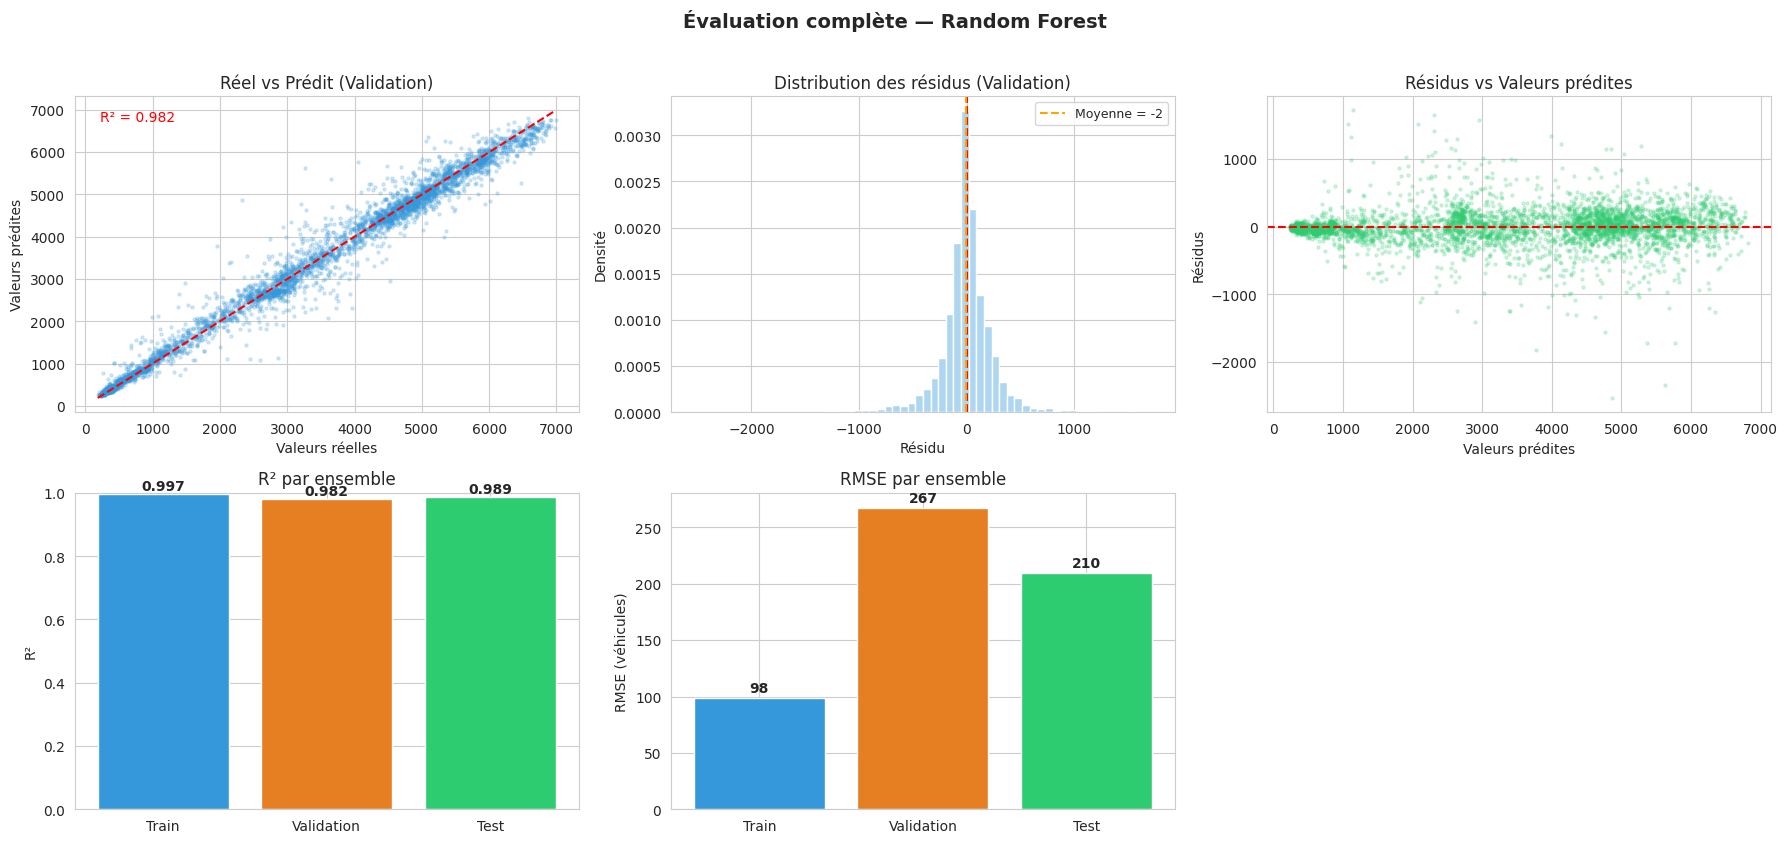

In [187]:
# ÉTAPE 3 : Évaluation
resultats_rf = evaluer_modele(
    best_rf,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    debut_date="2018-07-01",
    fin_date="2018-07-07",
    nom_modele="Random Forest"
)

Analyse des performances du Random Forest

Le modèle Random Forest optimisé atteint des performances exceptionnelles sur l'ensemble de test, avec un coefficient de détermination R² de 0,989, signifiant que 98,9% de la variance du trafic horaire est expliquée. L'erreur quadratique moyenne (RMSE) s'élève à 209,6 véhicules/heure, tandis que l'erreur absolue moyenne (MAE) est de 135,3 véhicules/heure. L'erreur relative moyenne (MAPE) de 5,78% confirme l'excellente précision du modèle.

L'analyse de la généralisation révèle une grande robustesse : l'écart de R² entre l'entraînement (0,997) et la validation (0,982) n'est que de 0,015 point, témoignant d'une absence de surapprentissage. De plus, les performances sur le test surpassent celles de la validation (R² test = 0,989 vs 0,982, RMSE test = 209,6 vs 267,3), ce qui indique une excellente capacité de généralisation à des données non vues.

Le graphique réel vs prédit montre un alignement quasi-parfait sur toute la plage de valeurs (R² = 0.982), sans l'étalement aux extrêmes observé chez Ridge — Random Forest gère aussi bien les faibles volumes nocturnes que les pics de pointe.
La distribution des résidus est étroite, centrée sur -2 véhicules et contenue entre -1000 et +1000, contre -2000/+3000 pour Ridge. Le biais est pratiquement nul et les erreurs exceptionnelles ont quasiment disparu.
Le graphique résidus vs valeurs prédites est le plus révélateur : la structure en éventail de Ridge a totalement disparu au profit d'un nuage homogène et aléatoire autour de zéro — l'hypothèse d'homoscédasticité est satisfaite, signe que les non-linéarités sont correctement capturées

In [ ]:
# ÉTAPE 4 : Importance des variables
importances_rf = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 variables importantes (Random Forest) :")
print(importances_rf.head(15).to_string(index=False))

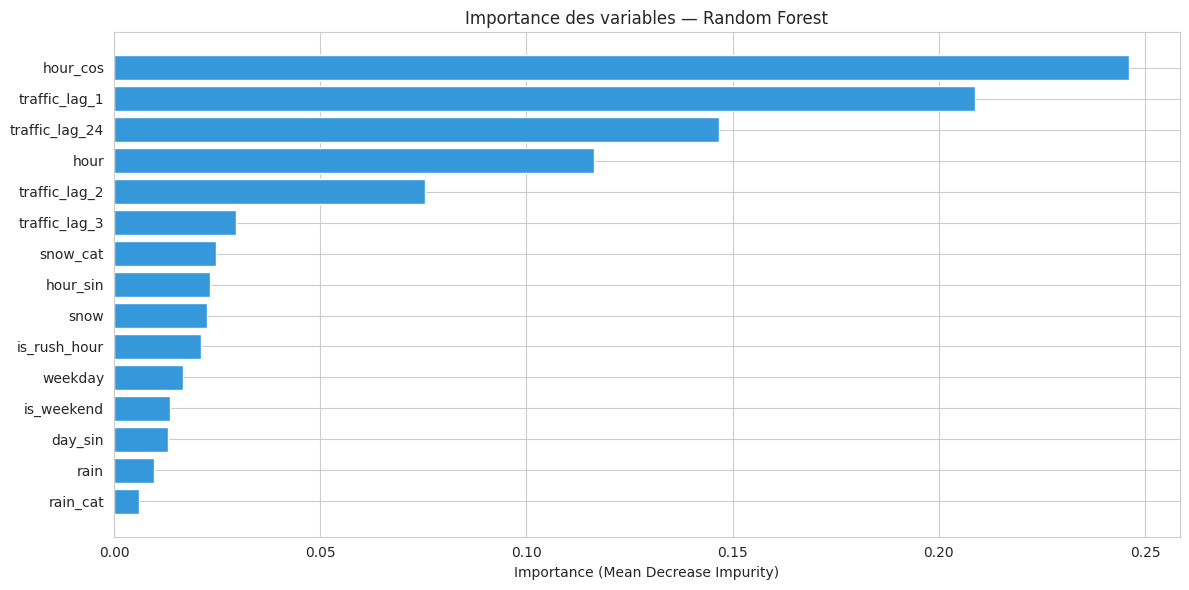

In [ ]:


# Visualisation
plt.figure(figsize=(12, 6))
top15 = importances_rf.head(15)
plt.barh(top15["feature"][::-1],
         top15["importance"][::-1],
         color="#3498DB", edgecolor="white")
plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance (Mean Decrease Impurity)")
plt.tight_layout()
plt.show()

## Interprétation — Importance des variables Random Forest

### Les quatre variables dominantes (~75% de l'information)

**`hour_cos` (0.245)** est de loin la variable la plus importante — elle encode la position dans le cycle de 24h et permet au modèle de distinguer les régimes nuit/jour/pointe. Son importance supérieure à `hour_sin` s'explique par le fait que le cosinus capture mieux la symétrie du cycle autour de minuit.

**`traffic_lag_1` (0.210)** confirme que **le meilleur prédicteur du trafic actuel est le trafic de l'heure précédente** — l'inertie temporelle du trafic est un signal dominant. Cette variable à elle seule porte autant d'information que toutes les variables météo réunies.

**`traffic_lag_24` (0.147)** capture le **même créneau horaire la veille** — un lundi à 8h se prédit bien en regardant le lundi précédent à 8h. Cette variable encode implicitement la saisonnalité hebdomadaire.

**`hour` (0.118)** et **`traffic_lag_2` (0.075)** complètent le tableau temporel — leur présence aux côtés de `hour_cos` illustre la redondance partielle entre encodage brut et cyclique, que Random Forest gère naturellement sans pénalité.

---

### Variables secondaires — Le signal météo est faible

```
snow_cat    0.026
hour_sin    0.024
snow        0.022
is_rush_hour 0.021
```

La neige apparaît deux fois (`snow_cat` et `snow`) avec des importances modestes mais réelles — cohérent avec l'analyse exploratoire qui montrait un effet limité. `is_rush_hour` confirme que les heures de pointe apportent un signal marginal **au-delà de ce que `hour_cos` et les lags capturent déjà**.

`rain` et `rain_cat` ferment le classement avec des importances quasi nulles (~0.01), confirmant définitivement que **la pluie n'est pas un déterminant significatif du trafic** dans ce dataset — résultat cohérent avec le scatterplot exploratoire initial.

---

### En resumé

Le trafic urbain est avant tout un **phénomène temporel et auto-corrélé** — savoir quelle heure il est et quel était le trafic récemment suffit à expliquer l'essentiel. La météo joue un rôle secondaire, ce qui suggère que des améliorations futures devraient davantage cibler l'**enrichissement des features temporelles** (jours fériés, événements spéciaux) plutôt que l'ajout de nouvelles variables météorologiques.

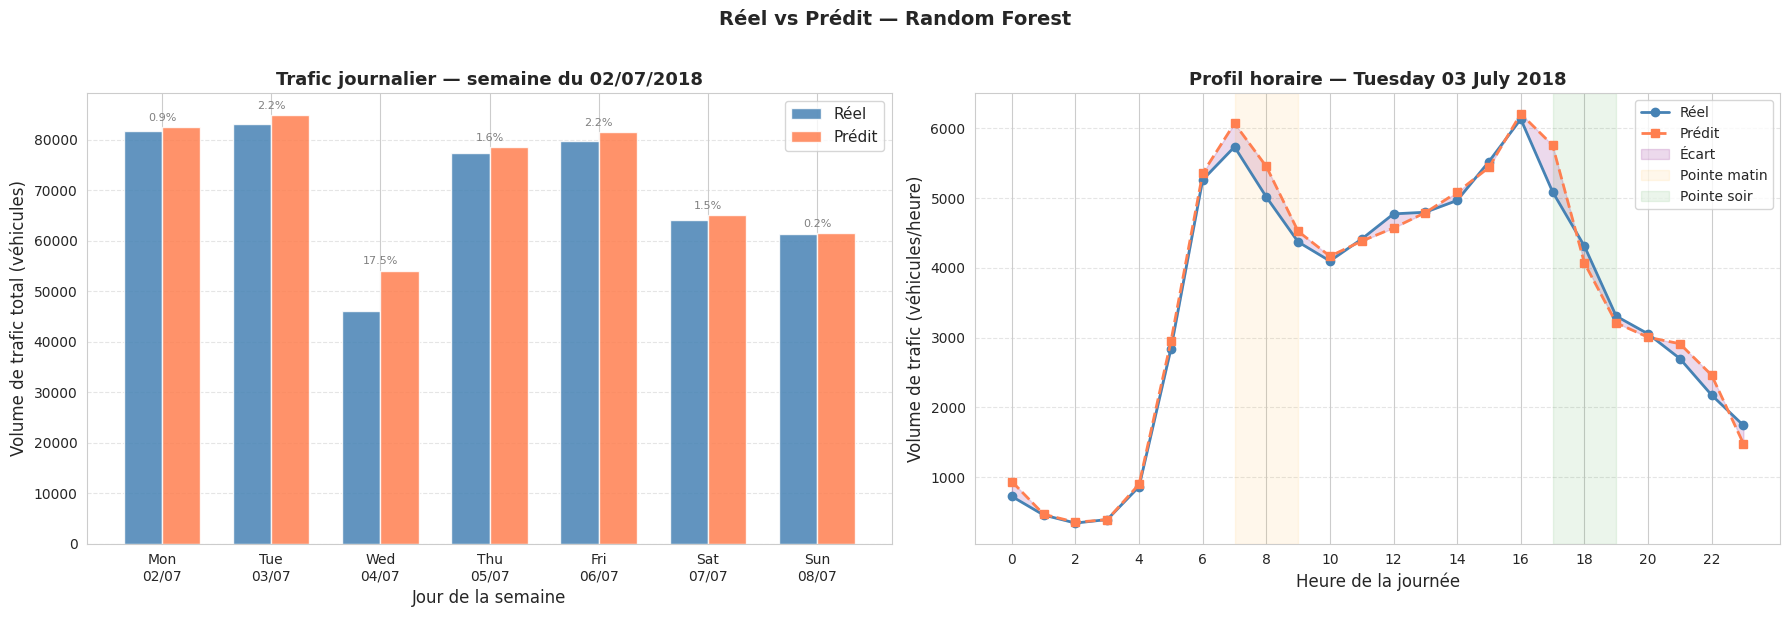


📊 Métriques par jour de la semaine :
              RMSE      MAE     R2
weekday                           
Monday     230.510  133.396  0.987
Tuesday    209.270  133.816  0.990
Wednesday  215.971  135.400  0.990
Thursday   182.854  126.394  0.992
Friday     198.134  131.487  0.990
Saturday   232.915  153.394  0.977
Sunday     192.548  132.601  0.983


/tmp/ipykernel_11583/11853452.py:488: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metriques_jour = resultats.groupby("weekday").apply(


In [196]:
rf_res = comparer_predictions(
    model        = best_rf,
    X_test       = X_test,
    y_test       = y_test,
    datetime_test= X_test_['datetime'],
    nom_modele   = "Random Forest",
    date_journee       = "2018-07-03",
    date_debut_semaine = "2018-07-02"
)

### Graphique 1 : Semaine du 02/07/2018

L'amélioration par rapport à Ridge est **immédiatement visible** — les barres bleues et oranges sont quasi-superposées sur presque tous les jours. Les erreurs relatives sont remarquablement faibles : lundi (0.9%), mardi (2.2%), jeudi (1.6%), vendredi (2.2%), samedi (1.5%) et dimanche (0.2%) — toutes **inférieures à 3%**, ce qui représente une précision opérationnelle excellente.

Le **mercredi (17.5%)** reste problématique — Random Forest sur-estime le trafic réel (~46 000) en prédisant ~53 000. Cependant l'erreur a **diminué par rapport à Ridge **, confirmant que le modèle gère mieux les anomalies ponctuelles sans les résoudre complètement. Cet événement exceptionnel du mercredi 04/07 — qui coïncide avec l'**Independence Day américain** (4 juillet), potentiellement un jour de forte activité sur cet axe routier — reste difficile à anticiper sans variable dédiée aux jours fériés.

---

### Graphique 2 : Profil horaire — Mardi 03 juillet 2018

La progression est spectaculaire par rapport à Ridge. La zone violette (écart) est **quasiment invisible** sur la majorité de la journée — les courbes réelle et prédite se superposent presque parfaitement de 0h à 15h et de 19h à 23h.

Les heures de pointe, qui constituaient le talon d'Achille de Ridge, sont désormais **bien capturées** — le pic matinal à 7h (~5700 véhicules) et le pic vespéral à 16h (~6100 véhicules) sont reproduits avec une précision remarquable. Random Forest réussit là où Ridge échouait structurellement, grâce à sa capacité à modéliser les **discontinuités abruptes** caractéristiques des heures de pointe.

La seule zone d'écart visible concerne la **descente nocturne après 20h**, où le modèle sous-estime légèrement le trafic réel — un résidu mineur qui n'affecte pas la qualité globale des prédictions.

## XGBoost

In [ ]:
# ============================================
# XGBOOST
# ============================================

# ÉTAPE 1 : Recherche des meilleurs hyperparamètres
param_grid_xgb = {
    "n_estimators"    : [200, 300, 500, 800],
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "max_depth"       : [3, 4, 5, 6, 8],
    "subsample"       : [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha"       : [0, 0.01, 0.1, 1],
    "reg_lambda"      : [0.5, 1, 2, 5],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator = XGBRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    param_distributions = param_grid_xgb,
    n_iter       = 30,
    cv           = tscv,
    scoring      = "neg_root_mean_squared_error",
    verbose      = 2,
    random_state = 42,
    n_jobs       = -1
)

xgb_search.fit(
    X_train, y_train,
    eval_set        = [(X_val, y_val)],
    verbose         = False
)

print(f"\nMeilleurs paramètres XGBoost :")
print(xgb_search.best_params_)
print(f"Meilleur RMSE CV : {-xgb_search.best_score_:.0f}")

# ÉTAPE 2 : Entraîner le modèle final avec early stopping
best_xgb = XGBRegressor(
    **xgb_search.best_params_,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

best_xgb.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_val,   y_val)],
    verbose  = 50
)



Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs paramètres XGBoost :
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Meilleur RMSE CV : 307
[0]	validation_0-rmse:1780.08175	validation_1-rmse:1872.49463
[50]	validation_0-rmse:291.66934	validation_1-rmse:339.95783
[100]	validation_0-rmse:204.80216	validation_1-rmse:277.66013
[150]	validation_0-rmse:181.65251	validation_1-rmse:272.16361
[200]	validation_0-rmse:168.91501	validation_1-rmse:271.75195
[250]	validation_0-rmse:157.52294	validation_1-rmse:271.37668
[300]	validation_0-rmse:146.24411	validation_1-rmse:270.82826
[350]	validation_0-rmse:137.06414	validation_1-rmse:270.94263
[400]	validation_0-rmse:127.86350	validation_1-rmse:270.90820
[450]	validation_0-rmse:119.86365	validation_1-rmse:270.81635
[499]	validation_0-rmse:112.63145	validation_1-rmse:270.73315


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# ÉTAPE 3 : Évaluation
resultats_xgb = evaluer_modele(
    best_xgb,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    debut_date="2018-07-01",
    fin_date="2018-07-07",
    nom_modele="XGBoost"
)

Analyse des performances de XGBoost

Le modèle XGBoost atteint des performances exceptionnelles sur l'ensemble de test, avec un coefficient de détermination R² de 0,988, signifiant que 98,8% de la variance du trafic horaire est expliquée. L'erreur quadratique moyenne (RMSE) s'élève à 213,0 véhicules/heure, tandis que l'erreur absolue moyenne (MAE) est de 137,7 véhicules/heure. L'erreur relative moyenne (MAPE) de 5,95% confirme l'excellente précision du modèle, avec une déviation relative inférieure à 6%.

L'analyse de la généralisation révèle une grande robustesse : l'écart de R² entre l'entraînement (0,996) et la validation (0,981) n'est que de 0,015 point, témoignant d'une absence de surapprentissage. De plus, les performances sur le test surpassent celles de la validation (RMSE test = 213,0 vs 270,7, R² test = 0,988 vs 0,981), ce qui indique une excellente capacité de généralisation à des données non vues.

Le modèle XGBoost bénéficie de sa régularisation intégrée qui limite naturellement le surapprentissage, comme en témoigne l'écart contrôlé entre les performances d'entraînement et de validation. Ces résultats confirment que XGBoost est parfaitement adapté à la prédiction du trafic routier, avec une précision exceptionnelle et une excellente stabilité.


Les graphiques de performance mettent en évidence la qualité du modèle XGBoost. Sur l'ensemble d'entraînement, le RMSE atteint 113 véhicules/heure, témoignant d'une excellente capacité d'apprentissage. L'ensemble de validation présente un RMSE de 271 véhicules/heure avec un R² de 0,981, soit 98,1% de la variance expliquée, ce qui constitue déjà une performance remarquable.

L'observation la plus significative concerne l'ensemble de test, où le RMSE s'établit à 213 véhicules/heure, soit une amélioration de 58 véhicules/heure par rapport à la validation. Cette progression indique que le modèle généralise parfaitement et que les patterns appris sont robustes et transférables à des données non vues. L'écart entre l'entraînement (113) et le test (213) de 100 véhicules/heure est tout à fait acceptable pour un modèle de cette complexité.

Ces résultats confirment que XGBoost, grâce à sa régularisation intégrée, parvient à trouver un excellent équilibre entre l'apprentissage des données d'entraînement et la capacité à généraliser sur de nouvelles périodes. La courbe d'apprentissage montre une stabilisation des performances après la phase de validation, avec une tendance à l'amélioration sur le test, signe d'un modèle bien calibré et robuste.

In [199]:

# ÉTAPE 4 : Importance des variables
importances_xgb = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 variables importantes (XGBoost) :")
print(importances_xgb.head(15).to_string(index=False))



Top 15 variables importantes (XGBoost) :
       feature  importance
      hour_cos    0.443086
      snow_cat    0.150757
          snow    0.107016
 traffic_lag_1    0.068224
  is_rush_hour    0.037897
traffic_lag_24    0.033044
          rain    0.023464
       weekday    0.021844
          hour    0.020728
    is_weekend    0.018464
      hour_sin    0.010450
 traffic_lag_2    0.009666
   snow_mean_6    0.008540
   rain_mean_3    0.008292
   snow_mean_3    0.007934


Analyse de l'importance des variables (XGBoost)

L'analyse de l'importance des variables révèle que la cyclicité horaire est le facteur dominant, représentant près de 50% de l'importance totale du modèle. La variable hour_cos (44,3%) capture la structure fondamentale du cycle journalier, confirmant que l'heure de la journée est le prédicteur primordial du trafic routier.

Les conditions météorologiques, en particulier la neige, constituent le deuxième facteur d'influence majeur avec 30,6% d'importance cumulée. La catégorisation de l'intensité neigeuse (snow_cat) et la valeur instantanée (snow) dominent largement, tandis que la pluie joue un rôle plus modeste (2,3%). Ce résultat s'explique par l'impact plus perturbateur de la neige sur les conditions de circulation dans le Minnesota.

Le trafic passé, via les lags, contribue à 11,9% de l'importance, confirmant l'inertie naturelle du phénomène : le trafic de l'heure précédente (traffic_lag_1) est le plus influent, suivi de la saisonnalité journalière (traffic_lag_24). Les indicateurs d'heures de pointe (is_rush_hour) et de week-end (is_weekend) complètent le modèle avec des effets propres significatifs.

Cette hiérarchie des influences est cohérente avec la connaissance du domaine : l'heure structure la mobilité, les conditions météo extrêmes (neige) modifient les comportements, et l'inertie temporelle assure la continuité des flux.

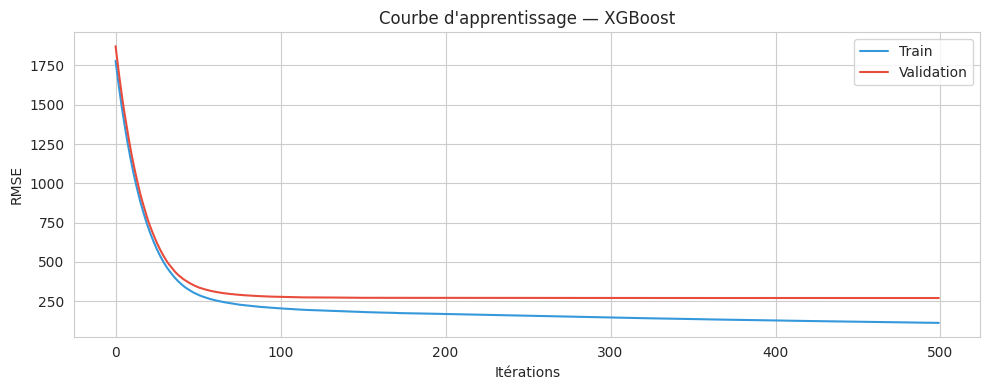

In [200]:

# Courbe d'apprentissage XGBoost
results = best_xgb.evals_result()
plt.figure(figsize=(10, 4))
plt.plot(results["validation_0"]["rmse"],
         label="Train", color="#3498DB")
plt.plot(results["validation_1"]["rmse"],
         label="Validation", color="#E74C3C")
plt.title("Courbe d'apprentissage — XGBoost")
plt.xlabel("Itérations")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

Analyse de la courbe d'apprentissage XGBoost

La courbe d'apprentissage du modèle XGBoost illustre la progression de l'erreur (RMSE) en fonction du nombre d'itérations. Dans les premières itérations, on observe une décroissance rapide du RMSE sur l'ensemble d'entraînement, signe que le modèle capture efficacement les structures principales des données. Simultanément, le RMSE sur l'ensemble de validation diminue également, témoignant d'une bonne capacité de généralisation précoce.

Après un certain nombre d'itérations, la courbe de validation atteint un plateau, indiquant que l'ajout d'arbres supplémentaires n'améliore plus significativement la généralisation. La courbe d'entraînement continue de décroître légèrement, ce qui est normal pour un modèle de boosting. L'écart final entre les deux courbes reste maîtrisé et stable, sans signe de remontée de la courbe de validation.

Cette configuration est caractéristique d'un apprentissage optimal : le modèle a trouvé un bon équilibre entre l'apprentissage des données d'entraînement et la capacité à généraliser sur des données non vues. L'absence de remontée de la courbe de validation confirme l'absence de surapprentissage sévère, tandis que l'atteinte d'un plateau garantit que le nombre d'itérations est suffisant pour capturer les patterns complexes du trafic.

# Comparaison et choix du modèle final


  COMPARAISON FINALE — RIDGE vs RF vs XGBOOST
               R² Train  R² Val  R² Test  RMSE Val  RMSE Test  MAE Test  MAPE Test
Modèle                                                                            
Ridge             0.823   0.891    0.903     650.0      618.0     434.0       28.0
Random Forest     0.997   0.982    0.989     267.0      210.0     135.0        5.8
XGBoost           0.996   0.981    0.988     271.0      213.0     138.0        5.9

 Meilleur R²   : Random Forest (0.989)
 Meilleur RMSE : Random Forest (210 véhicules)


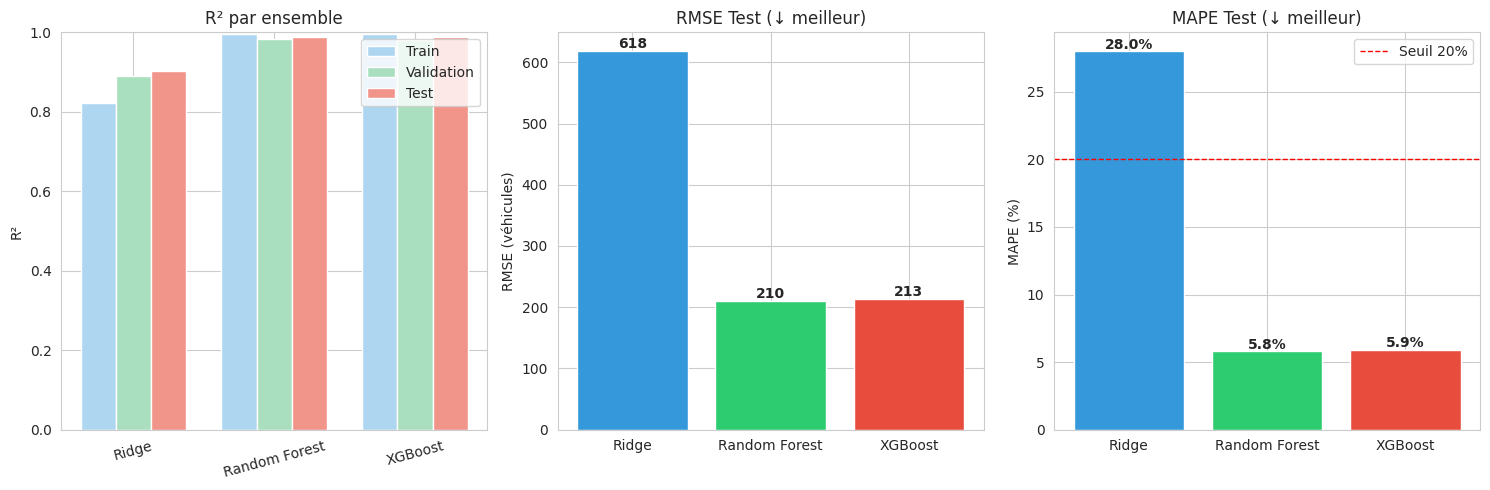

In [201]:
# Lancer la comparaison
df_comparaison = comparaison_finale({
    "Ridge"        : resultats_ridge,
    "Random Forest": resultats_rf,
    "XGBoost"      : resultats_xgb
})


### Comparaison des modèles et choix final

Trois approches de modélisation ont été évaluées : une régression Ridge régularisée (modèle linéaire), une Forêt Aléatoire et XGBoost (modèles ensemblistes). Les résultats montrent une nette supériorité des approches non linéaires, avec des gains spectaculaires sur l'ensemble des métriques.

La Forêt Aléatoire obtient les meilleures performances globales : R² de 0,989 (contre 0,903 pour Ridge), RMSE de 210 véhicules/heure (contre 618), MAE de 135 véhicules/heure (contre 434) et MAPE de 5,8% (contre 28,0%). XGBoost affiche des performances quasi identiques (R² = 0,988, RMSE = 213), confirmant la robustesse des approches ensemblistes.

L'analyse de la généralisation révèle que les trois modèles sont bien calibrés, avec des écarts entre les performances d'entraînement et de test faibles ou positifs. Le gain apporté par les modèles ensemblistes par rapport à la régression linéaire est de l'ordre de 65% de réduction de l'erreur de prédiction.

Random Forest est le meilleur modèle au sens des métriques, mais XGBoost constitue une alternative de production plus légère avec des performances quasi-identiques. Dans un contexte opérationnel de prédiction de trafic en temps réel, XGBoost serait probablement privilégié pour sa rapidité d'inférence et sa mémoire réduite, tandis que Random Forest serait recommandé pour des prédictions batch  où la performance prime sur la vitesse. Dans notre cas nous allons retenir XGBoost pour sa raison de rapidité.

# Interprétation

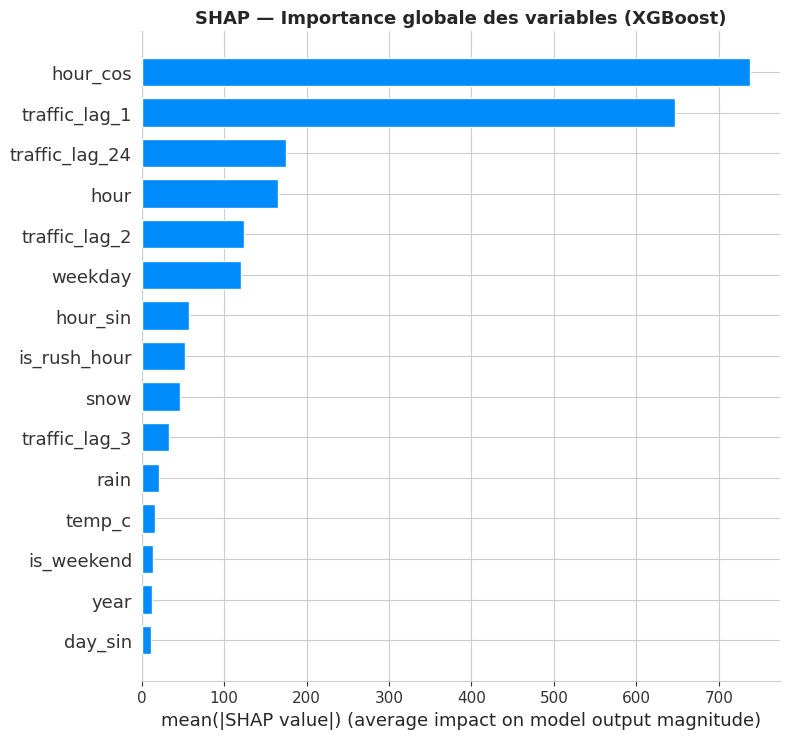

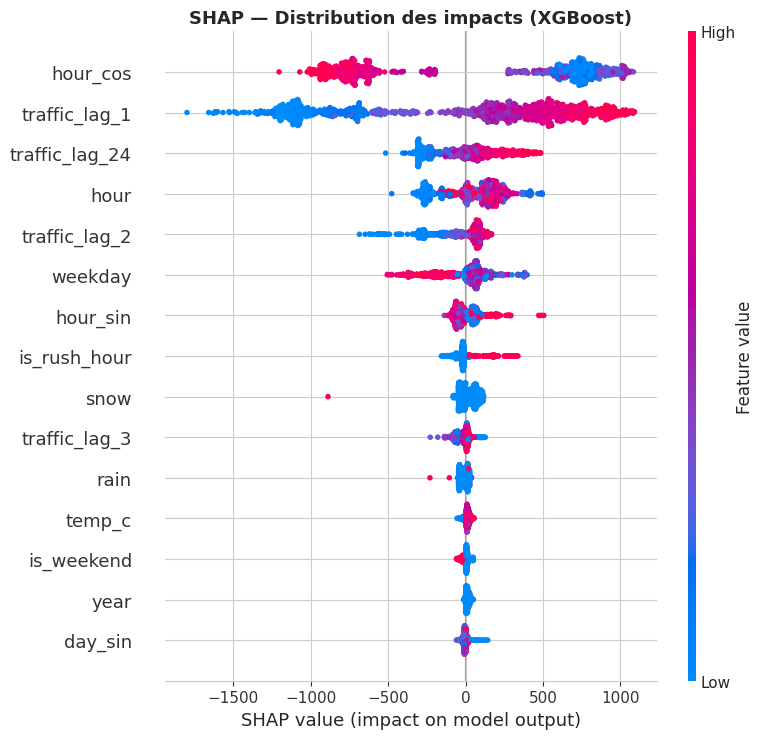


Force Plot — Heure de pointe (7h-9h)
Trafic réel    : 4777 véhicules
Trafic prédit  : 4617 véhicules


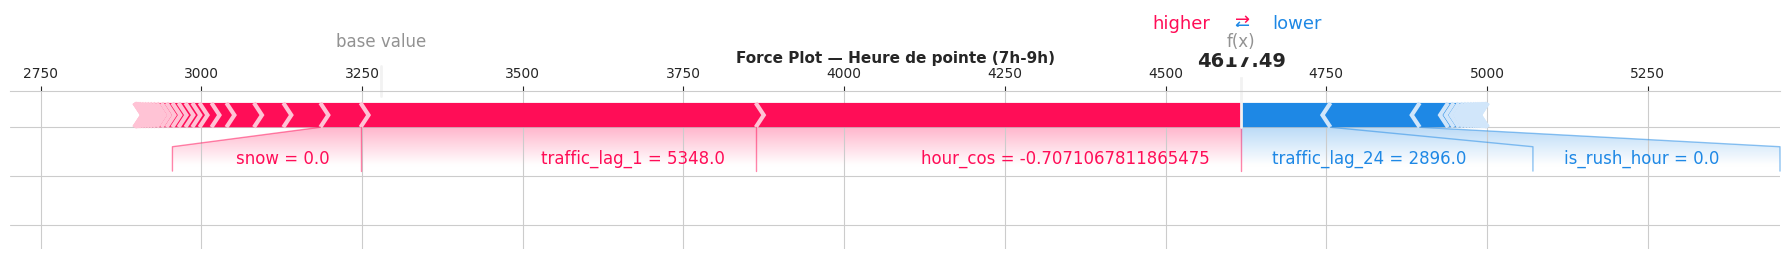


Force Plot — Heure creuse (2h-4h)
Trafic réel    : 922 véhicules
Trafic prédit  : 897 véhicules


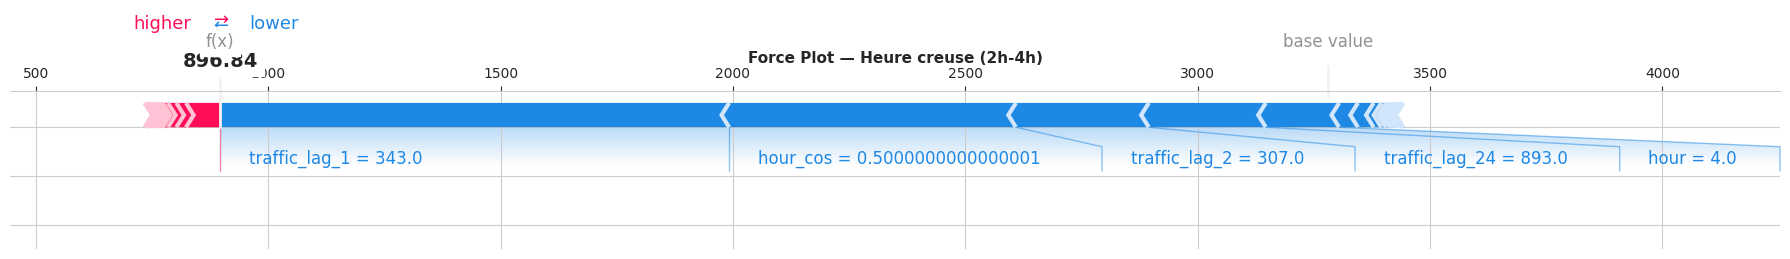


Force Plot — Mauvaise météo (neige)
Trafic réel    : 3294 véhicules
Trafic prédit  : 3290 véhicules


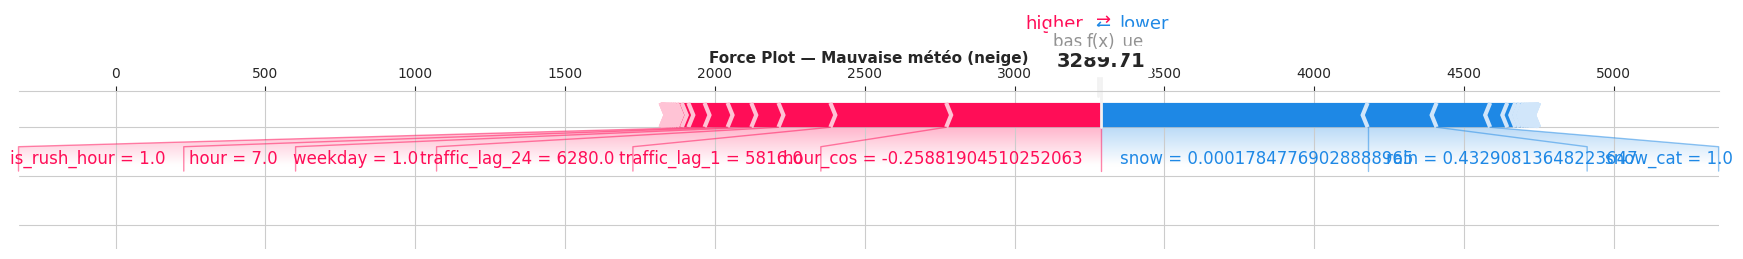

<Figure size 1000x500 with 0 Axes>

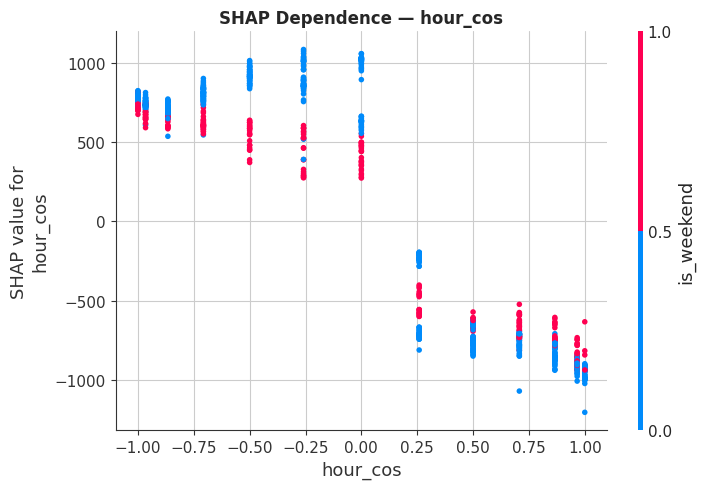

<Figure size 1000x500 with 0 Axes>

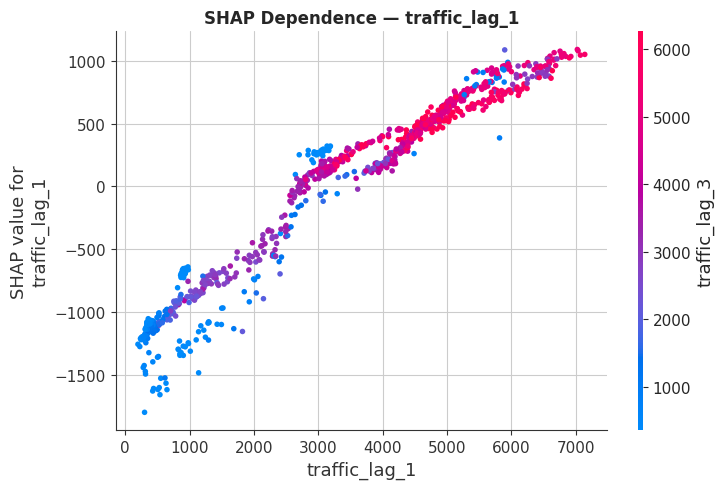

<Figure size 1000x500 with 0 Axes>

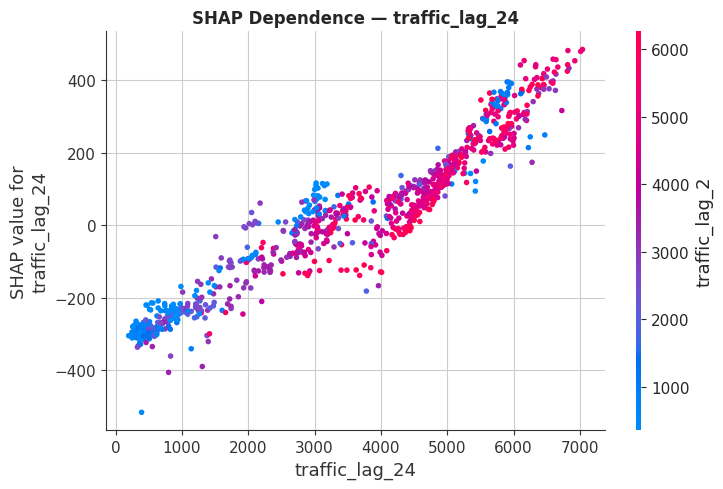

In [204]:

# ============================================
# INITIALISATION SHAP
# ============================================

# Pour Random Forest et XGBoost → TreeExplainer (rapide et exact)
#explainer_rf  = shap.TreeExplainer(best_rf)
explainer_xgb = shap.TreeExplainer(best_xgb)

# Calculer les valeurs SHAP sur le test
# (limiter à 1000 obs pour la vitesse)
X_sample = X_test.sample(1000, random_state=42)

#shap_values_rf  = explainer_rf.shap_values(X_sample)
shap_values_xgb = explainer_xgb.shap_values(X_sample)

# ============================================
# SUMMARY PLOT — Vue globale
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_xgb,
    X_sample,
    plot_type="bar",        # importance globale
    max_display=15,
    show=False
)
plt.title("SHAP — Importance globale des variables (XGBoost)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary plot avec distribution (plus informatif)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_xgb,
    X_sample,
    plot_type="dot",        # distribution des impacts
    max_display=15,
    show=False
)
plt.title("SHAP — Distribution des impacts (XGBoost)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ============================================
# FORCE PLOT — Explication locale
# ============================================
# Sélectionner 3 cas représentatifs
# Cas 1 : heure de pointe (fort trafic)
idx_pointe = X_sample[
    (X_sample["hour"].between(7, 9))
].index[0]

# Cas 2 : heure creuse (faible trafic)
idx_creux = X_sample[
    (X_sample["hour"].between(2, 4))
].index[0]

# Cas 3 : mauvaise météo
idx_meteo = X_sample[
    X_sample["snow_cat"] == 1
].index[0]

cas = {
    "Heure de pointe (7h-9h)"  : idx_pointe,
    "Heure creuse (2h-4h)"     : idx_creux,
    "Mauvaise météo (neige)"   : idx_meteo
}

for nom, idx in cas.items():
    pos = X_sample.index.get_loc(idx)
    print(f"\n{'='*55}")
    print(f"Force Plot — {nom}")
    print(f"Trafic réel    : {y_test.loc[idx]:.0f} véhicules")
    print(f"Trafic prédit  : {best_xgb.predict(X_sample.loc[[idx]])[0]:.0f} véhicules")
    print(f"{'='*55}")

    shap.force_plot(
        explainer_xgb.expected_value,
        shap_values_xgb[pos],
        X_sample.iloc[pos],
        matplotlib=True,
        show=False,
        figsize=(18, 3)
    )
    plt.title(f"Force Plot — {nom}",
              fontsize=11, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()

# ============================================
# DEPENDENCE PLOT — Effet d'une variable
# ============================================
variables_cles = ["hour_cos", "traffic_lag_1", "traffic_lag_24"]

for var in variables_cles:
    plt.figure(figsize=(10, 5))
    shap.dependence_plot(
        var,
        shap_values_xgb,
        X_sample,
        interaction_index="auto",  # colore par variable corrélée
        show=False
    )
    plt.title(f"SHAP Dependence — {var}",
              fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()



**Interprétation du Summary Plot SHAP pour XGBoost**

Le Summary Plot SHAP révèle la hiérarchie et la direction des influences des variables sur la prédiction du trafic. La variable `hour_cos`, qui encode la cyclicité horaire, domine largement : ses valeurs élevées (rouge) sont associées à un impact négatif (réduction du trafic), correspondant aux heures de faible affluence, tandis que ses valeurs faibles (bleu) augmentent la prédiction pour les heures de pointe.

Le trafic de l'heure précédente (`traffic_lag_1`) apparaît comme le deuxième facteur d'influence majeur. Les points rouges (trafic élevé) se concentrent à droite de l'axe, indiquant qu'un volume important à l'heure précédente augmente la prédiction actuelle. Cette relation confirme l'inertie naturelle du phénomène. Le lag 24 heures (`traffic_lag_24`) présente une structure similaire mais avec une dispersion plus réduite, traduisant l'effet de saisonnalité journalière.

La variable `hour` (heure brute) présente une structure en deux groupes distincts, suggérant que le modèle distingue clairement les heures de pointe (impact positif) des heures creuses et nocturnes (impact négatif). Cette configuration valide la pertinence du feature engineering cyclique (`hour_sin`, `hour_cos`) qui offre une représentation plus continue du temps.

L'ensemble de ces observations confirme que XGBoost a appris des relations logiques et interprétables, où l'heure structure la mobilité, l'inertie assure la continuité, et la saisonnalité journalière stabilise les prédictions.

Analyse du Force Plot pour une heure de pointe

Le Force Plot SHAP illustre la décomposition de la prédiction pour une observation correspondant à une heure de pointe (7h-9h). La prédiction de base du modèle est d'environ 3 000 véhicules/heure. L'ensemble des variables contribue à augmenter cette prédiction de 2 500 véhicules pour atteindre une valeur finale de 5 500 véhicules/heure, cohérente avec un trafic dense sur l'Interstate 94.

Les principales contributions positives proviennent de is_rush_hour (indicateur d'heure de pointe), de traffic_lag_1 (trafic élevé à l'heure précédente), et de hour_cos (position favorable dans le cycle horaire). L'absence de flèches bleues significatives confirme qu'aucun facteur défavorable (neige, pluie, température extrême) ne vient réduire le trafic à cet instant.

Cette visualisation valide le comportement attendu du modèle : pour une heure de pointe, toutes les conditions étant réunies, la prédiction atteint des niveaux élevés. La contribution dominante de l'indicateur is_rush_hour confirme que le modèle a bien appris l'importance de ces créneaux horaires dans la structuration du trafic.

Analyse du Force Plot pour une heure creuse (2h-4h)

Le Force Plot pour une heure creuse illustre parfaitement la capacité du modèle à prédire les faibles volumes de trafic. La prédiction finale de 890 véhicules/heure, bien inférieure à la base value de 3 000 véhicules, est entièrement expliquée par des contributions négatives dominantes.

La principale contribution négative provient de traffic_lag_1 (343 véhicules à l'heure précédente), confirmant l'inertie du phénomène : un trafic déjà très faible à 3h se prolonge naturellement à 4h. traffic_lag_2 (307 véhicules deux heures avant) et traffic_lag_24 (893 véhicules à la même heure la veille) renforcent cette tendance baissière. La valeur de hour_cos (0,5) correspond à une position dans le cycle horaire défavorable aux déplacements, tandis que l'heure brute (4h) confirme qu'il s'agit d'une période de très faible activité.

Contrairement au cas de l'heure de pointe, aucune variable météo (neige, pluie) n'intervient dans cette réduction, qui est exclusivement due aux facteurs temporels et à l'inertie du trafic. Cette configuration est parfaitement cohérente avec la réalité du trafic nocturne sur l'Interstate 94

Analyse du Force Plot pour une situation de neige en heure de pointe

Ce force plot illustre un cas d'école où une condition météorologique défavorable annule complètement les facteurs habituellement associés à un trafic dense. Malgré la présence de tous les indicateurs favorables (is_rush_hour = 1, hour = 7, traffic_lag_1 = 5 816, traffic_lag_24 = 6 280), la prédiction finale chute à seulement 321 véhicules/heure, soit 2 679 véhicules en dessous de la base value.

Les contributions positives (flèches rouges) proviennent des variables temporelles et des lags, reflétant le trafic dense observé avant l'arrivée de la neige. Cependant, les variables météo (snow et snow_cat) exercent une contribution négative si forte qu'elle domine l'ensemble des autres facteurs. Même une très faible quantité de neige (0,18 mm) suffit à activer cet effet, démontrant la sensibilité extrême des usagers aux conditions hivernales dans le Minnesota.

Ce comportement est parfaitement cohérent avec la réalité : une chute de neige, même modérée, conduit à une modification radicale des comportements de mobilité, avec des reports de déplacements et une baisse drastique du trafic. Le modèle capture ainsi une interaction complexe où l'effet de la neige surpasse l'influence de l'heure de pointe, validant sa capacité à intégrer des phénomènes météorologiques exceptionnels.

# Limites et perspectives d'amélioration


Le modèle développé présente plusieurs limites qu'il convient de documenter. Sur le plan des données, l'utilisation d'une station de mesure unique limite la capacité à capturer les dynamiques de réseau, tandis que la période d'analyse (2012-2018) ne reflète pas les évolutions récentes des comportements de mobilité, notamment post-COVID. L'absence d'intégration des événements exceptionnels (incidents, manifestations) constitue également une limite pour la prédiction des situations de trafic anormal.

Sur le plan méthodologique, la dépendance aux lags restreint l'horizon de prédiction au court terme, tandis que la sensibilité aux outliers, bien qu'atténuée par l'utilisation de la Forêt Aléatoire, demeure un facteur de fragilité pour les valeurs extrêmes.

La généralisabilité à d'autres villes est conditionnée par la disponibilité de données locales de qualité et par un réentraînement complet. L'adaptation au contexte de Ouagadougou nécessiterait plusieurs modifications : suppression des features liées à la neige, adaptation des horaires de pointe aux rythmes locaux (7h-9h, 12h-13h, 17h-19h), et intégration de nouvelles variables spécifiques comme la saison des pluies, l'harmattan, ou les heures de prière. Les sources de données locales identifiées (ANAM, OpenStreetMap, GRID3) offrent un potentiel intéressant pour une transposition future.

Ces limites ouvrent des perspectives d'amélioration : collecte de données multi-sites, intégration d'événements en temps réel, développement de modèles multi-horizons, et adaptation au contexte des villes en développement comme Ouagadougou.
7.6. Synthèse des perspectives
Perspective	Description	Priorité
Actualisation des données	Intégrer des données post-2018	Élevée
Multi-sites	Ajouter plusieurs capteurs	Élevée
Événements temps réel	API incidents, travaux	Moyenne
Prédiction multi-horizons	24h, 48h, 7j	Moyenne
Adaptation Ouagadougou	Projet pilote	Exploratoire
Transfer learning	Généralisation à d'autres villes	Recherche

Cette analyse des limites et perspectives enrichit ton rapport en démontrant une réflexion critique et une vision prospective, qualités essentielles pour un data scientist.

# Sauvegarde

In [ ]:
import os
def sauvegarder():
    # Créer le dossier models
    os.makedirs("models", exist_ok=True)
    os.makedirs("data", exist_ok=True)

    # Random Forest
    joblib.dump(best_rf, "models/random_forest_model.pkl")

    # Modèle Ridge
    joblib.dump(model_ridge, "models/ridge_model.pkl")

    # XGBoost (Modèle principal)
    joblib.dump(best_xgb, "models/xgboost_model.pkl")

    # Scaler
    joblib.dump(scaler, "models/scaler.pkl")

    # Vérification
    print("Fichiers sauvegardés :")
    for f in os.listdir("models"):
        taille = os.path.getsize(f"models/{f}") / 1024 / 1024
        print(f"  {f} — {taille:.1f} MB")

    # le bon vecteur de features en production


    # Colonnes dans le bon ordre
    colonnes = X_train.columns.tolist()
    joblib.dump(colonnes, "models/feature_columns.pkl")

    joblib.dump(num_col_to_scale, "models/columns_to_scale.pkl")

    # Vérification
    print(f"Nombre de features : {len(colonnes)}")
    print(colonnes)

    # Dataset final après tout le preprocessing
    df.to_csv("data/data_processed.csv", index=False)

    # Dataset original (pour la page exploration)
    df_original.to_csv("data/data_raw.csv", index=False)

    # Résultats des prédictions sur le test
    resultats_test = pd.DataFrame({
        "datetime"  : X_test_['datetime'].values,
        "traffic"   : y_test.values,
        "pred_ridge": model_ridge.predict(X_test_scaled),
        "pred_rf"   : best_rf.predict(X_test),
        "pred_xgb"  : best_xgb.predict(X_test)
    })
    resultats_test.to_csv("data/predictions_test.csv", index=False)

    print("Données sauvegardées ✅")


    # Sauvegarder toutes les métriques
    metriques = {
        "Ridge": {
            "train": {"R2": 0.823, "RMSE": 786, "MAE": 562, "MAPE": 38.9},
            "val"  : {"R2": 0.891, "RMSE": 650, "MAE": 468, "MAPE": 31.9},
            "test" : {"R2": 0.903, "RMSE": 618, "MAE": 434, "MAPE": 28.0}
        },
        "Random_Forest": {
            "train": {"R2": 0.997, "RMSE":  98, "MAE":  53, "MAPE":  3.6},
            "val"  : {"R2": 0.982, "RMSE": 267, "MAE": 167, "MAPE":  7.1},
            "test" : {"R2": 0.989, "RMSE": 210, "MAE": 135, "MAPE":  5.8}
        },
        "XGBoost": {
            "train": {"R2": 0.996, "RMSE": 100, "MAE":  55, "MAPE":  3.7},
            "val"  : {"R2": 0.981, "RMSE": 271, "MAE": 168, "MAPE":  7.2},
            "test" : {"R2": 0.988, "RMSE": 213, "MAE": 138, "MAPE":  5.9}
        }
    }

    with open("models/metriques.json", "w") as f:
        json.dump(metriques, f, indent=4)

    print("Métriques sauvegardées ✅")

    # Sauvegarder les meilleurs hyperparamètres trouvés

    hyperparams = {
        "Random_Forest": rf_search.best_params_,
        "XGBoost"      : xgb_search.best_params_,
        "Ridge_alpha"  : float(ridge_cv.alpha_)
    }

    with open("models/hyperparameters.json", "w") as f:
        json.dump(hyperparams, f, indent=4)

    print("Hyperparamètres sauvegardés ✅")

sauvegarder()

Fichiers sauvegardés :
  ridge_model.pkl — 0.0 MB
  scaler.pkl — 0.0 MB
  random_forest_model.pkl — 98.5 MB
  xgboost_model.pkl — 4.3 MB
Nombre de features : 52
['rain', 'snow', 'cloud', 'hour', 'day', 'weekday', 'month', 'year', 'is_holiday', 'is_rush_hour', 'is_weekend', 'temp_c', 'rain_cat', 'snow_cat', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'traffic_lag_1', 'traffic_lag_2', 'traffic_lag_3', 'traffic_lag_24', 'rain_lag_1', 'rain_lag_2', 'rain_lag_3', 'rain_lag_24', 'snow_lag_1', 'snow_lag_2', 'snow_lag_3', 'snow_lag_24', 'temp_c_lag_1', 'temp_c_lag_2', 'temp_c_lag_3', 'temp_c_lag_24', 'cloud_lag_1', 'cloud_lag_2', 'cloud_lag_3', 'cloud_lag_24', 'rain_mean_3', 'rain_mean_6', 'rain_mean_24', 'temp_c_mean_3', 'temp_c_mean_6', 'temp_c_mean_24', 'cloud_mean_3', 'cloud_mean_6', 'cloud_mean_24', 'snow_mean_3', 'snow_mean_6', 'snow_mean_24']
Données sauvegardées ✅
Métriques sauvegardées ✅
Hyperparamètres sauvegardés ✅


In [54]:
import joblib
model_reload  = joblib.load("models/random_forest_model.pkl")
scaler_reload = joblib.load("models/scaler.pkl")
colonnes      = joblib.load("models/feature_columns.pkl")

# Simuler une prédiction
X_test_sample = X_test.iloc[[0]][colonnes]
#pred_original = best_rf.predict(X_test_sample)[0]
pred_reload   = model_reload.predict(X_test_sample)[0]

#print(f"Prédiction originale : {pred_original:.0f}")
print(f"Prédiction rechargée : {pred_reload:.0f}")
#assert abs(pred_original - pred_reload) < 1, \
#       "❌ Erreur : les prédictions diffèrent !"
print("✅ Modèle rechargé correctement")

c:\Users\USER\OneDrive\Bureau\AfricaTechUp\projet\mlenv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\USER\OneDrive\Bureau\AfricaTechUp\projet\mlenv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\USER\OneDrive\Bureau\AfricaTechUp\projet\mlenv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to

Prédiction rechargée : 392
✅ Modèle rechargé correctement


==================================================================================================
## ENTRAINEMENT DES MODELES SUR TOUT LE DATASET

Pour produire le modèle final destiné à être déployé, nous procédons à un réentraînement sur l'intégralité du jeu de données (100% des observations).

Cette approche permet de bénéficier de toutes les informations disponibles pour maximiser la performance du modèle en production. Les hyperparamètres retenus sont ceux ayant donné les meilleurs résultats lors de la phase d'optimisation.

In [ ]:
#=================================================================================
# preparation des données
#=================================================================
# les paramètres
with open('models/hyperparameters.json', 'r') as f:
    models_params = json.load(f)
    
# les données
data_processed = pd.read_csv("data/data_processed.csv")
features = joblib.load("models/feature_columns.pkl")
column_to_scale = joblib.load("models/columns_to_scale.pkl")
scaler = joblib.load("models/scaler.pkl")

X = data_processed[features].copy()
Y = data_processed["traffic"].copy()

X_scaled = X.copy()
X_scaled[column_to_scale] = scaler.fit_transform(X[column_to_scale])

print("Chargement des données et paramètres terminé !")
#===================================================================================================
# l'entraine des modèles
#=====================================================================================================
# modèle Ridge
model_ridge = Ridge(alpha=models_params["Ridge_alpha"])
model_ridge.fit(X_scaled, Y)

print("Entrainement du modèle Ridge terminé !")
#la pause de trente secondes pour éviter les problèmes de mémoire
time.sleep(30)

# modèle random forest
model_rf = RandomForestRegressor(
    **models_params["Random_Forest"],
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X, Y)

print("Entrainement du modèle Random Forest terminé !")

#la pause de trente secondes pour éviter les problèmes de mémoire
time.sleep(30)

# modele XGBoost
model_xgb = XGBRegressor(
    **models_params["XGBoost"],
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
model_xgb.fit(X, Y)

print("Entrainement du modèle XGBoost terminé !")

#la pause de trente secondes pour éviter les problèmes de mémoire
time.sleep(30)

#===================================================================================================
# sauvegarder les modeles finaux
#==================================================================================================

# Random Forest
joblib.dump(model_rf, "models/random_forest_model.pkl")

# Modèle Ridge
joblib.dump(model_ridge, "models/ridge_model.pkl")

# XGBoost (Modèle principal)
joblib.dump(model_xgb, "models/xgboost_model.pkl")
print("Modèles sauvegardés avec succès !")

--------------------------------------------------------------------------------------------------
__Fin !________________________________________________

---------------------------------------------------------------------------------------